Libraries loaded successfully.

Using:
Symptom dataset   : /content/Symptom.csv
Specialist dataset: /content/Disease Specialist.csv

DATASET SHAPES
Symptom.csv shape: (4920, 18)
Disease Specialist.csv shape: (41, 2)

SYMPTOM DATASET COLUMNS
['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']

SPECIALIST DATASET COLUMNS
['Disease', 'Specialist']

IDENTIFIED COLUMNS
Symptom disease column    : disease
Specialist disease column : disease
Specialist target column  : specialist

Unique diseases in Symptom.csv: 41
Unique diseases in Specialist.csv: 41

ALL SPECIALIST LABELS IN YOUR FILE
_specialist_clean
Allergist                    2
Cardiologist                 2
Dermatologist                4
Endocrinologist              4
Gastroenterologist           4
Hepatologist                 7
Infectious Disease 

/tmp/ipykernel_687/2308407749.py:480: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_df[safe_feature_name] = 0



CANDIDATE BINARY FEATURES
Total candidate features: 100

Target classes:
0 → Cardiology
1 → Dermatology
2 → Gastroenterology
3 → General Medicine
4 → Neurology
5 → Orthopedics
6 → Pulmonology
7 → Urology

CLASS DISTRIBUTION
_specialty_key
Cardiology           240
Dermatology          480
Gastroenterology    1440
General Medicine     360
Neurology            240
Orthopedics          360
Pulmonology          240
Urology              120

TOP 30 FEATURES — CONSENSUS RANKING
 consensus_rank                  feature  chi2_score  mutual_information  logreg_coef_strength  coverage_count   best_specialty  specificity_score  average_rank
              1                skin_rash 2261.803191            0.346252              0.608590               2      Dermatology           0.892262          4.00
              2           breathlessness 2410.714286            0.256291              0.789264               2      Pulmonology           0.885714          4.75
              3                 headache

_specialty_key,General Medicine,Cardiology,Pulmonology,Gastroenterology,Orthopedics,Neurology,Dermatology,Urology
skin_rash,0.317,0.000,0.000,0.000,0.000,0.000,0.938,0.00
breathlessness,0.000,0.450,0.950,0.000,0.000,0.000,0.000,0.00
headache,0.633,0.450,0.000,0.000,0.000,0.950,0.000,0.00
continuous_feel_of_urine,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.95
bladder_discomfort,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.95
high_fever,0.950,0.000,0.950,0.158,0.000,0.000,0.212,0.00
burning_micturition,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.90
neck_pain,0.000,0.000,0.000,0.000,0.633,0.000,0.000,0.00
cough,0.317,0.000,0.925,0.079,0.000,0.000,0.000,0.00
chest_pain,0.333,0.925,0.500,0.079,0.000,0.000,0.000,0.00



TOP FEATURES FOR EACH SPECIALTY

General Medicine
   high_fever                          0.950
   malaise                             0.650
   fatigue                             0.633
   headache                            0.633
   swelled_lymph_nodes                 0.633
   chest_pain                          0.333
   congestion                          0.333
   loss_of_smell                       0.333
   muscle_pain                         0.333
   phlegm                              0.333

Cardiology
   chest_pain                          0.925
   lack_of_concentration               0.475
   loss_of_balance                     0.475
   breathlessness                      0.450
   dizziness                           0.450
   headache                            0.450
   sweating                            0.450
   vomiting                            0.450
   abdominal_pain                      0.000
   acidity                             0.000

Pulmonology
   breathlessness       

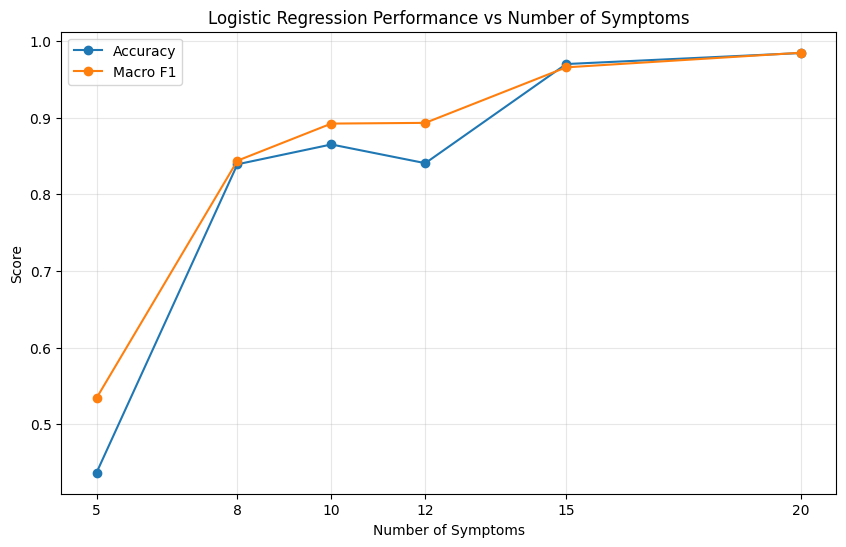

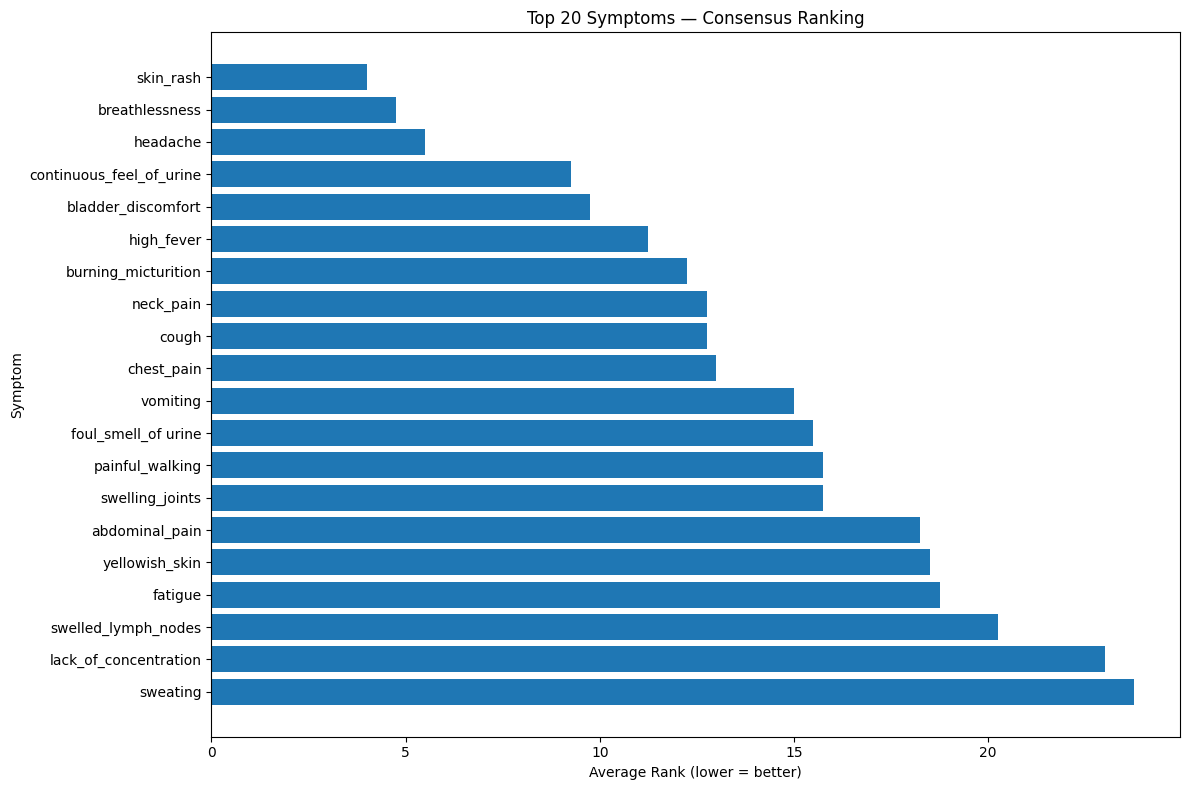


FINAL SUMMARY FOR YOU TO PASTE BACK

1. Number of source rows after specialty filtering:
3480

2. Number of candidate symptoms:
100

3. Target specialties:
['General Medicine', 'Cardiology', 'Pulmonology', 'Gastroenterology', 'Orthopedics', 'Neurology', 'Dermatology', 'Urology']

4. TOP 10:
1. skin_rash
2. breathlessness
3. headache
4. continuous_feel_of_urine
5. bladder_discomfort
6. high_fever
7. burning_micturition
8. neck_pain
9. cough
10. chest_pain

5. TOP 15:
1. skin_rash
2. breathlessness
3. headache
4. continuous_feel_of_urine
5. bladder_discomfort
6. high_fever
7. burning_micturition
8. neck_pain
9. cough
10. chest_pain
11. vomiting
12. foul_smell_of urine
13. painful_walking
14. swelling_joints
15. abdominal_pain

6. Feature-count performance:
 number_of_features  accuracy  macro_f1
                  5  0.436782  0.534109
                  8  0.839080  0.843786
                 10  0.864943  0.892177
                 12  0.840517  0.893098
                 15  0.969828  0.9

In [ ]:
# ============================================================
# SMART HEALTHCARE POC
# Symptom + Disease Specialist Dataset Analysis
#
# PURPOSE:
# 1. Load the two CSV files
# 2. Clean and merge them
# 3. Keep only useful specialties
# 4. Convert raw symptom columns into binary features
# 5. Rank symptoms using:
#       - Chi-square
#       - Mutual Information
#       - Logistic Regression coefficient strength
#       - Class coverage
#       - Redundancy / correlation
# 6. Create a CONSENSUS ranking
# 7. Show top 10 / 15 / 20 candidate symptoms
#
# IMPORTANT:
# We are NOT finalizing the dataset yet.
# We first inspect the results and then decide the final 10.
# ============================================================


# ============================================================
# 0. INSTALL / IMPORT LIBRARIES
# ============================================================

!pip -q install pandas numpy scikit-learn openpyxl matplotlib seaborn

import os
import re
import numpy as np
import pandas as pd

from collections import Counter

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

print("Libraries loaded successfully.")


# ============================================================
# 1. LOAD YOUR TWO DATASETS
# ============================================================
#
# OPTION A:
# If the files already exist in Colab, this will find them.
#
# OPTION B:
# If not, uncomment the upload section below.
# ============================================================


# ---- Try common local paths first ----

possible_symptom_paths = [
    "/content/Symptom.csv"
]

possible_specialist_paths = [
    "/content/Disease Specialist.csv"
]

symptom_path = next((p for p in possible_symptom_paths if os.path.exists(p)), None)
specialist_path = next((p for p in possible_specialist_paths if os.path.exists(p)), None)


# ---- If not found, allow Colab upload ----

if symptom_path is None or specialist_path is None:

    print("\nFiles not automatically found.")
    print("Please upload BOTH CSV files now.")

    from google.colab import files

    uploaded = files.upload()

    uploaded_names = list(uploaded.keys())

    print("\nUploaded files:")
    for name in uploaded_names:
        print(" -", name)

    # Try to identify files automatically
    for name in uploaded_names:
        clean_name = name.lower().replace("_", " ").strip()

        if "symptom" in clean_name and "specialist" not in clean_name:
            symptom_path = f"/content/{name}"

        if "specialist" in clean_name:
            specialist_path = f"/content/{name}"

if symptom_path is None:
    raise FileNotFoundError("Could not find Symptom.csv")

if specialist_path is None:
    raise FileNotFoundError("Could not find Disease Specialist.csv")


print("\nUsing:")
print("Symptom dataset   :", symptom_path)
print("Specialist dataset:", specialist_path)


# ============================================================
# 2. READ CSV FILES
# ============================================================

symptom_df = pd.read_csv(symptom_path)
specialist_df = pd.read_csv(specialist_path)

print("\n" + "="*80)
print("DATASET SHAPES")
print("="*80)

print("Symptom.csv shape:", symptom_df.shape)
print("Disease Specialist.csv shape:", specialist_df.shape)


print("\n" + "="*80)
print("SYMPTOM DATASET COLUMNS")
print("="*80)
print(list(symptom_df.columns))

print("\n" + "="*80)
print("SPECIALIST DATASET COLUMNS")
print("="*80)
print(list(specialist_df.columns))


# ============================================================
# 3. AUTOMATICALLY FIND IMPORTANT COLUMNS
# ============================================================

def normalize_column_name(col):
    return (
        str(col)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )


symptom_df.columns = [normalize_column_name(c) for c in symptom_df.columns]
specialist_df.columns = [normalize_column_name(c) for c in specialist_df.columns]


# Find disease column
disease_candidates = [
    c for c in symptom_df.columns
    if c in ["disease", "diagnosis", "condition"]
]

if not disease_candidates:
    raise ValueError(
        f"Could not identify disease column in Symptom.csv. "
        f"Columns found: {list(symptom_df.columns)}"
    )

disease_col_symptom = disease_candidates[0]


# Find specialist dataset columns
disease_candidates_spec = [
    c for c in specialist_df.columns
    if c in ["disease", "diagnosis", "condition"]
]

specialist_candidates = [
    c for c in specialist_df.columns
    if "special" in c or "doctor" in c
]

if not disease_candidates_spec:
    raise ValueError(
        f"Could not identify disease column in specialist dataset. "
        f"Columns found: {list(specialist_df.columns)}"
    )

if not specialist_candidates:
    raise ValueError(
        f"Could not identify specialist column in specialist dataset. "
        f"Columns found: {list(specialist_df.columns)}"
    )


disease_col_spec = disease_candidates_spec[0]
specialist_col = specialist_candidates[0]


print("\n" + "="*80)
print("IDENTIFIED COLUMNS")
print("="*80)

print("Symptom disease column    :", disease_col_symptom)
print("Specialist disease column :", disease_col_spec)
print("Specialist target column  :", specialist_col)


# ============================================================
# 4. CLEAN DISEASE NAMES
# ============================================================

def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x).strip().lower()
    x = re.sub(r"\s+", " ", x)
    return x


symptom_df["_disease_key"] = symptom_df[disease_col_symptom].apply(clean_text)
specialist_df["_disease_key"] = specialist_df[disease_col_spec].apply(clean_text)

specialist_df["_specialist_clean"] = (
    specialist_df[specialist_col]
    .astype(str)
    .str.strip()
)

print("\nUnique diseases in Symptom.csv:",
      symptom_df["_disease_key"].nunique())

print("Unique diseases in Specialist.csv:",
      specialist_df["_disease_key"].nunique())


# ============================================================
# 5. SHOW SPECIALIST LABELS AVAILABLE IN YOUR FILE
# ============================================================

print("\n" + "="*80)
print("ALL SPECIALIST LABELS IN YOUR FILE")
print("="*80)

specialist_counts = (
    specialist_df["_specialist_clean"]
    .value_counts()
    .sort_index()
)

print(specialist_counts.to_string())


# ============================================================
# 6. DEFINE OUR TARGET SPECIALTIES
# ============================================================
#
# We intentionally use the 8 specialties we previously agreed
# are most defensible from the current two datasets.
#
# "Primary Care Provider" is mapped to General Medicine.
# ============================================================

SPECIALIST_NORMALIZATION = {
    # General Medicine
    "primary care provider": "General Medicine",
    "general practitioner": "General Medicine",
    "general physician": "General Medicine",
    "general medicine": "General Medicine",

    # Cardiology
    "cardiologist": "Cardiology",
    "cardiology": "Cardiology",

    # Pulmonology
    "pulmonologist": "Pulmonology",
    "pulmonology": "Pulmonology",

    # Gastroenterology
    "gastroenterologist": "Gastroenterology",
    "gastroenterology": "Gastroenterology",
    "hepatologist": "Gastroenterology",
    "hepatology": "Gastroenterology",
    "proctologist": "Gastroenterology",

    # Orthopedics
    "orthopedic": "Orthopedics",
    "orthopaedic": "Orthopedics",
    "orthopedics": "Orthopedics",
    "orthopaedics": "Orthopedics",

    # Neurology
    "neurologist": "Neurology",
    "neurology": "Neurology",
    "neurosurgeon": "Neurology",

    # Dermatology
    "dermatologist": "Dermatology",
    "dermatology": "Dermatology",

    # Urology
    "urologist": "Urology",
    "urology": "Urology",
}

specialist_df["_specialty_key"] = (
    specialist_df["_specialist_clean"]
    .apply(clean_text)
    .map(SPECIALIST_NORMALIZATION)
)

TARGET_SPECIALTIES = [
    "General Medicine",
    "Cardiology",
    "Pulmonology",
    "Gastroenterology",
    "Orthopedics",
    "Neurology",
    "Dermatology",
    "Urology"
]

print("\n" + "="*80)
print("NORMALIZED SPECIALTIES")
print("="*80)

print(
    specialist_df["_specialty_key"]
    .value_counts(dropna=False)
    .to_string()
)


# ============================================================
# 7. MERGE THE TWO DATASETS
# ============================================================

merged_df = symptom_df.merge(
    specialist_df[["_disease_key", "_specialty_key"]],
    on="_disease_key",
    how="left"
)

print("\n" + "="*80)
print("MERGE RESULT")
print("="*80)

print("Merged shape:", merged_df.shape)

missing_specialty = merged_df["_specialty_key"].isna().sum()

print("Rows without specialty mapping:", missing_specialty)


# ============================================================
# 8. SHOW DISEASE → SPECIALTY MAPPING
# ============================================================

mapping_view = (
    merged_df[
        ["_disease_key", "_specialty_key"]
    ]
    .drop_duplicates()
    .sort_values(["_specialty_key", "_disease_key"])
)

print("\n" + "="*80)
print("DISEASE → SPECIALTY MAPPING")
print("="*80)

print(mapping_view.to_string(index=False))


# ============================================================
# 9. KEEP ONLY OUR TARGET SPECIALTIES
# ============================================================

model_df = merged_df[
    merged_df["_specialty_key"].isin(TARGET_SPECIALTIES)
].copy()

print("\n" + "="*80)
print("FILTERED MODEL DATA")
print("="*80)

print("Rows retained:", len(model_df))
print("Rows removed :", len(merged_df) - len(model_df))

print("\nRows per specialty:")
print(
    model_df["_specialty_key"]
    .value_counts()
    .reindex(TARGET_SPECIALTIES)
    .fillna(0)
    .astype(int)
)


# ============================================================
# 10. IDENTIFY RAW SYMPTOM COLUMNS
# ============================================================
#
# We detect Symptom_1, Symptom_2, ... automatically.
# ============================================================

symptom_columns = [
    c for c in model_df.columns
    if re.match(r"symptom[_ ]?\d+$", c.lower())
]

print("\n" + "="*80)
print("RAW SYMPTOM COLUMNS")
print("="*80)

print(symptom_columns)

if len(symptom_columns) == 0:
    raise ValueError(
        "No Symptom_1, Symptom_2 ... columns were detected."
    )


# ============================================================
# 11. BUILD A LIST OF ALL RAW SYMPTOMS
# ============================================================

all_raw_symptoms = []

for col in symptom_columns:
    values = (
        model_df[col]
        .dropna()
        .astype(str)
        .map(clean_text)
    )

    for value in values:
        if value not in ["", "nan", "none", "null", "0"]:
            all_raw_symptoms.append(value)

raw_symptom_counts = Counter(all_raw_symptoms)

raw_symptom_list = sorted(raw_symptom_counts.keys())

print("\n" + "="*80)
print("RAW SYMPTOM SUMMARY")
print("="*80)

print("Unique raw symptoms found:", len(raw_symptom_list))

print("\nMost frequent raw symptoms:")
for symptom, count in raw_symptom_counts.most_common(30):
    print(f"{symptom:35s} {count}")


# ============================================================
# 12. CREATE BINARY FEATURES FOR EVERY RAW SYMPTOM
# ============================================================
#
# Each row becomes:
#
# symptom_x = 1 -> symptom present
# symptom_x = 0 -> symptom absent/not listed
#
# This creates the candidate feature matrix.
# ============================================================

for symptom in raw_symptom_list:

    safe_feature_name = symptom

    # Start at zero
    model_df[safe_feature_name] = 0

    # Mark 1 if symptom occurs in ANY Symptom_* column
    for col in symptom_columns:
        mask = (
            model_df[col]
            .fillna("")
            .astype(str)
            .map(clean_text)
            == symptom
        )

        model_df.loc[mask, safe_feature_name] = 1


# ============================================================
# 13. REMOVE FEATURES THAT HAVE NO VARIATION
# ============================================================

candidate_features = []

for symptom in raw_symptom_list:
    unique_values = model_df[symptom].nunique()

    if unique_values >= 2:
        candidate_features.append(symptom)

print("\n" + "="*80)
print("CANDIDATE BINARY FEATURES")
print("="*80)

print("Total candidate features:", len(candidate_features))


# ============================================================
# 14. BUILD X / y
# ============================================================

X = model_df[candidate_features].astype(int)

y_text = model_df["_specialty_key"].astype(str)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

print("\nTarget classes:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "→", cls)


# ============================================================
# 15. CLASS DISTRIBUTION
# ============================================================

class_distribution = pd.Series(
    y_text
).value_counts().sort_index()

print("\n" + "="*80)
print("CLASS DISTRIBUTION")
print("="*80)

print(class_distribution.to_string())


# ============================================================
# 16. METRIC #1 — CHI-SQUARE
# ============================================================
#
# Measures dependence between each binary symptom and
# the multiclass target.
#
# Larger chi-square = more discriminative.
# ============================================================

chi_scores, chi_pvalues = chi2(X, y)

chi_df = pd.DataFrame({
    "feature": candidate_features,
    "chi2_score": chi_scores,
    "chi2_pvalue": chi_pvalues
})

chi_df = chi_df.sort_values(
    "chi2_score",
    ascending=False
).reset_index(drop=True)

chi_df["chi2_rank"] = np.arange(1, len(chi_df) + 1)


# ============================================================
# 17. METRIC #2 — MUTUAL INFORMATION
# ============================================================
#
# Measures nonlinear statistical dependence between symptom
# and specialty.
# ============================================================

mi_scores = mutual_info_classif(
    X,
    y,
    discrete_features=True,
    random_state=42
)

mi_df = pd.DataFrame({
    "feature": candidate_features,
    "mutual_information": mi_scores
})

mi_df = mi_df.sort_values(
    "mutual_information",
    ascending=False
).reset_index(drop=True)

mi_df["mi_rank"] = np.arange(1, len(mi_df) + 1)


# ============================================================
# 18. METRIC #3 — LOGISTIC REGRESSION COEFFICIENT STRENGTH
# ============================================================
#
# Train a multiclass Logistic Regression model.
#
# Since this is a feature-ranking experiment, we use
# class_weight='balanced' so large classes do not dominate.
#
# Mean absolute coefficient across classes:
#
#     importance = mean(abs(coef))
#
# Larger value = stronger influence on model decisions.
# ============================================================

lr_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=42
)

lr_model.fit(X, y)

coef_importance = np.mean(
    np.abs(lr_model.coef_),
    axis=0
)

coef_df = pd.DataFrame({
    "feature": candidate_features,
    "logreg_coef_strength": coef_importance
})

coef_df = coef_df.sort_values(
    "logreg_coef_strength",
    ascending=False
).reset_index(drop=True)

coef_df["logreg_rank"] = np.arange(
    1,
    len(coef_df) + 1
)


# ============================================================
# 19. METRIC #4 — CLASS COVERAGE
# ============================================================
#
# For every symptom:
#
# coverage = number of target specialties where the symptom
# occurs in at least one training record.
#
# We don't want only "common" symptoms.
# We want symptoms that help distinguish classes.
#
# We print BOTH:
#   - coverage_count
#   - specialty presence rates
# ============================================================

coverage_records = []

for feature in candidate_features:

    present = model_df.loc[
        model_df[feature] == 1,
        "_specialty_key"
    ].unique()

    coverage_count = len(present)

    coverage_records.append({
        "feature": feature,
        "coverage_count": coverage_count,
        "coverage_ratio": coverage_count / len(TARGET_SPECIALTIES)
    })

coverage_df = pd.DataFrame(coverage_records)

# IMPORTANT:
# Coverage alone is not "importance".
# We use it as a supporting metric.


# ============================================================
# 20. METRIC #5 — HOW SPECIFIC IS EACH SYMPTOM?
# ============================================================
#
# For each symptom we calculate:
#
# max specialty occurrence rate
# minus
# average occurrence rate in other classes
#
# Higher = symptom is more concentrated in a particular class.
# ============================================================

specificity_records = []

for feature in candidate_features:

    rates = (
        model_df
        .groupby("_specialty_key")[feature]
        .mean()
        .reindex(TARGET_SPECIALTIES)
        .fillna(0)
    )

    max_rate = rates.max()
    winning_specialty = rates.idxmax()

    other_rates = rates.drop(winning_specialty)

    if len(other_rates) > 0:
        avg_other_rate = other_rates.mean()
    else:
        avg_other_rate = 0

    specificity_score = max_rate - avg_other_rate

    specificity_records.append({
        "feature": feature,
        "best_specialty": winning_specialty,
        "best_class_rate": max_rate,
        "avg_other_class_rate": avg_other_rate,
        "specificity_score": specificity_score
    })

specificity_df = pd.DataFrame(
    specificity_records
).sort_values(
    "specificity_score",
    ascending=False
).reset_index(drop=True)

specificity_df["specificity_rank"] = np.arange(
    1,
    len(specificity_df) + 1
)


# ============================================================
# 21. COMBINE ALL RANKINGS
# ============================================================

ranking_df = (
    chi_df[[
        "feature",
        "chi2_score",
        "chi2_pvalue",
        "chi2_rank"
    ]]
    .merge(
        mi_df[[
            "feature",
            "mutual_information",
            "mi_rank"
        ]],
        on="feature"
    )
    .merge(
        coef_df[[
            "feature",
            "logreg_coef_strength",
            "logreg_rank"
        ]],
        on="feature"
    )
    .merge(
        coverage_df,
        on="feature"
    )
    .merge(
        specificity_df[[
            "feature",
            "best_specialty",
            "best_class_rate",
            "avg_other_class_rate",
            "specificity_score",
            "specificity_rank"
        ]],
        on="feature"
    )
)


# ============================================================
# 22. CONSENSUS RANK
# ============================================================
#
# Lower average rank = stronger overall evidence.
#
# We intentionally use several methods instead of relying on
# one statistical test.
# ============================================================

rank_columns = [
    "chi2_rank",
    "mi_rank",
    "logreg_rank",
    "specificity_rank"
]

ranking_df["average_rank"] = (
    ranking_df[rank_columns].mean(axis=1)
)

ranking_df["consensus_rank"] = (
    ranking_df["average_rank"]
    .rank(method="min")
    .astype(int)
)

ranking_df = ranking_df.sort_values(
    ["average_rank", "chi2_rank", "mi_rank"]
).reset_index(drop=True)


# ============================================================
# 23. OPTIONAL REDUNDANCY CHECK
# ============================================================
#
# Highly correlated symptoms may represent nearly the same thing.
#
# For binary variables Pearson correlation is simple and useful
# as a first POC screening.
# ============================================================

corr_matrix = X.corr()


# Find highly correlated pairs
high_corr_pairs = []

for i in range(len(candidate_features)):
    for j in range(i + 1, len(candidate_features)):

        f1 = candidate_features[i]
        f2 = candidate_features[j]

        corr_value = corr_matrix.loc[f1, f2]

        if abs(corr_value) >= 0.80:
            high_corr_pairs.append({
                "feature_1": f1,
                "feature_2": f2,
                "correlation": corr_value
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

if len(high_corr_df) == 0:
    high_corr_df = pd.DataFrame(
        columns=["feature_1", "feature_2", "correlation"]
    )


# ============================================================
# 24. PRINT TOP 30 CONSENSUS FEATURES
# ============================================================

print("\n" + "="*100)
print("TOP 30 FEATURES — CONSENSUS RANKING")
print("="*100)

display_columns = [
    "consensus_rank",
    "feature",
    "chi2_score",
    "mutual_information",
    "logreg_coef_strength",
    "coverage_count",
    "best_specialty",
    "specificity_score",
    "average_rank"
]

print(
    ranking_df[
        display_columns
    ]
    .head(30)
    .to_string(index=False)
)


# ============================================================
# 25. PRINT TOP 10
# ============================================================

top10 = ranking_df.head(10)["feature"].tolist()

print("\n" + "="*80)
print("TOP 10 FEATURES")
print("="*80)

for i, feature in enumerate(top10, start=1):
    row = ranking_df[
        ranking_df["feature"] == feature
    ].iloc[0]

    print(
        f"{i:2d}. {feature:35s}"
        f" | Best specialty: {row['best_specialty']}"
        f" | Avg rank: {row['average_rank']:.2f}"
    )


# ============================================================
# 26. TOP 15
# ============================================================

print("\n" + "="*80)
print("TOP 15 FEATURES")
print("="*80)

for i, feature in enumerate(
    ranking_df.head(15)["feature"],
    start=1
):
    print(f"{i:2d}. {feature}")


# ============================================================
# 27. TOP 20
# ============================================================

print("\n" + "="*80)
print("TOP 20 FEATURES")
print("="*80)

for i, feature in enumerate(
    ranking_df.head(20)["feature"],
    start=1
):
    print(f"{i:2d}. {feature}")


# ============================================================
# 28. SHOW WHICH SPECIALTY EACH TOP FEATURE HELPS
# ============================================================

TOP_N_FOR_ANALYSIS = 20

top_features_for_specialty = ranking_df.head(
    TOP_N_FOR_ANALYSIS
)["feature"].tolist()

print("\n" + "="*100)
print("TOP FEATURES — SPECIALTY OCCURRENCE RATES")
print("="*100)

specialty_rate_table = (
    model_df
    .groupby("_specialty_key")[
        top_features_for_specialty
    ]
    .mean()
    .reindex(TARGET_SPECIALTIES)
)

# Transpose so rows = symptoms
specialty_rate_table = specialty_rate_table.T

display(
    specialty_rate_table.round(3)
)


# ============================================================
# 29. SHOW THE MOST IMPORTANT SYMPTOMS BY EACH SPECIALTY
# ============================================================

print("\n" + "="*100)
print("TOP FEATURES FOR EACH SPECIALTY")
print("="*100)

for specialty in TARGET_SPECIALTIES:

    specialty_rows = []

    for feature in candidate_features:

        yes_rate = (
            model_df.loc[
                model_df["_specialty_key"] == specialty,
                feature
            ].mean()
        )

        specialty_rows.append(
            (feature, yes_rate)
        )

    specialty_rows = sorted(
        specialty_rows,
        key=lambda x: x[1],
        reverse=True
    )

    print("\n" + specialty)

    for feature, rate in specialty_rows[:10]:
        print(
            f"   {feature:35s} "
            f"{rate:.3f}"
        )


# ============================================================
# 30. REDUNDANCY / CORRELATION REPORT
# ============================================================

print("\n" + "="*100)
print("HIGHLY CORRELATED / REDUNDANT SYMPTOM PAIRS (|r| >= 0.80)")
print("="*100)

if len(high_corr_df) == 0:
    print("No highly correlated symptom pairs found.")
else:
    print(
        high_corr_df
        .sort_values(
            "correlation",
            key=lambda s: s.abs(),
            ascending=False
        )
        .to_string(index=False)
    )


# ============================================================
# 31. FEATURE SELECTION "SHORTLIST"
# ============================================================
#
# Instead of immediately choosing the final 10, create a
# slightly larger shortlist of 15.
#
# We will inspect this manually before finalizing the 10.
# ============================================================

shortlist_15 = ranking_df.head(15).copy()

print("\n" + "="*100)
print("RECOMMENDED 15-SYMPTOM SHORTLIST FOR HUMAN REVIEW")
print("="*100)

print(
    shortlist_15[
        [
            "consensus_rank",
            "feature",
            "best_specialty",
            "coverage_count",
            "specificity_score",
            "chi2_score",
            "mutual_information",
            "logreg_coef_strength"
        ]
    ].to_string(index=False)
)


# ============================================================
# 32. HOLDOUT MODEL TEST
# ============================================================
#
# This is NOT the final evaluation.
# It is just a useful sanity check:
#
# "If we use all candidate symptoms, how well does simple
# Logistic Regression classify the 8 specialties?"
#
# This tells us whether the problem contains useful signal.
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

sanity_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=42
)

sanity_model.fit(X_train, y_train)

y_pred = sanity_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print("\n" + "="*80)
print("BASELINE SANITY CHECK")
print("="*80)

print(f"Accuracy : {accuracy:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


# ============================================================
# 33. TEST LOGISTIC REGRESSION USING TOP 10 ONLY
# ============================================================
#
# This is interesting because your final website will use
# only a small number of symptoms.
# ============================================================

X_top10 = model_df[top10].astype(int)

X10_train, X10_test, y10_train, y10_test = train_test_split(
    X_top10,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

top10_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=42
)

top10_model.fit(X10_train, y10_train)

y10_pred = top10_model.predict(X10_test)

top10_accuracy = accuracy_score(
    y10_test,
    y10_pred
)

top10_macro_f1 = f1_score(
    y10_test,
    y10_pred,
    average="macro"
)

print("\n" + "="*80)
print("LOGISTIC REGRESSION USING TOP 10 FEATURES")
print("="*80)

print(f"Top-10 Accuracy : {top10_accuracy:.4f}")
print(f"Top-10 Macro F1 : {top10_macro_f1:.4f}")


# ============================================================
# 34. TEST TOP 15
# ============================================================

top15 = ranking_df.head(15)["feature"].tolist()

X_top15 = model_df[top15].astype(int)

X15_train, X15_test, y15_train, y15_test = train_test_split(
    X_top15,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

top15_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=42
)

top15_model.fit(X15_train, y15_train)

y15_pred = top15_model.predict(X15_test)

top15_accuracy = accuracy_score(
    y15_test,
    y15_pred
)

top15_macro_f1 = f1_score(
    y15_test,
    y15_pred,
    average="macro"
)

print("\n" + "="*80)
print("LOGISTIC REGRESSION USING TOP 15 FEATURES")
print("="*80)

print(f"Top-15 Accuracy : {top15_accuracy:.4f}")
print(f"Top-15 Macro F1 : {top15_macro_f1:.4f}")


# ============================================================
# 35. COMPARE DIFFERENT NUMBERS OF FEATURES
# ============================================================
#
# This is very useful for deciding whether 10 is enough.
#
# We test:
# 5
# 8
# 10
# 12
# 15
# 20
#
# All models use the same train/test split.
# ============================================================

feature_counts_to_test = [5, 8, 10, 12, 15, 20]

comparison_results = []

# Keep one consistent split using row indexes
train_idx, test_idx = train_test_split(
    np.arange(len(model_df)),
    test_size=0.20,
    random_state=42,
    stratify=y
)

for n_features in feature_counts_to_test:

    selected_features = ranking_df.head(
        n_features
    )["feature"].tolist()

    X_n = model_df[selected_features].astype(int)

    X_train_n = X_n.iloc[train_idx]
    X_test_n = X_n.iloc[test_idx]

    y_train_n = y[train_idx]
    y_test_n = y[test_idx]

    model_n = LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42
    )

    model_n.fit(
        X_train_n,
        y_train_n
    )

    pred_n = model_n.predict(
        X_test_n
    )

    acc_n = accuracy_score(
        y_test_n,
        pred_n
    )

    f1_n = f1_score(
        y_test_n,
        pred_n,
        average="macro"
    )

    comparison_results.append({
        "number_of_features": n_features,
        "accuracy": acc_n,
        "macro_f1": f1_n
    })

comparison_df = pd.DataFrame(
    comparison_results
)

print("\n" + "="*80)
print("FEATURE COUNT COMPARISON")
print("="*80)

print(
    comparison_df.to_string(index=False)
)


# ============================================================
# 36. PLOT FEATURE-COUNT PERFORMANCE
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    comparison_df["number_of_features"],
    comparison_df["accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    comparison_df["number_of_features"],
    comparison_df["macro_f1"],
    marker="o",
    label="Macro F1"
)

plt.xlabel("Number of Symptoms")
plt.ylabel("Score")
plt.title("Logistic Regression Performance vs Number of Symptoms")
plt.xticks(feature_counts_to_test)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# ============================================================
# 37. TOP 20 CONSENSUS VISUALIZATION
# ============================================================

plot_df = ranking_df.head(20).copy()

plot_df = plot_df.sort_values(
    "average_rank",
    ascending=True
)

plt.figure(figsize=(12, 8))

plt.barh(
    plot_df["feature"],
    plot_df["average_rank"]
)

plt.gca().invert_yaxis()

plt.xlabel("Average Rank (lower = better)")
plt.ylabel("Symptom")
plt.title("Top 20 Symptoms — Consensus Ranking")

plt.tight_layout()
plt.show()


# ============================================================
# 38. EXPORT ANALYSIS RESULTS
# ============================================================

analysis_output = "/content/symptom_feature_analysis.csv"
mapping_output = "/content/disease_specialty_mapping.csv"
comparison_output = "/content/feature_count_comparison.csv"

ranking_df.to_csv(
    analysis_output,
    index=False
)

mapping_view.to_csv(
    mapping_output,
    index=False
)

comparison_df.to_csv(
    comparison_output,
    index=False
)


# ============================================================
# 39. FINAL SUMMARY
# ============================================================

print("\n" + "="*100)
print("FINAL SUMMARY FOR YOU TO PASTE BACK")
print("="*100)

print("\n1. Number of source rows after specialty filtering:")
print(len(model_df))

print("\n2. Number of candidate symptoms:")
print(len(candidate_features))

print("\n3. Target specialties:")
print(TARGET_SPECIALTIES)

print("\n4. TOP 10:")
for i, feature in enumerate(top10, start=1):
    print(f"{i}. {feature}")

print("\n5. TOP 15:")
for i, feature in enumerate(top15, start=1):
    print(f"{i}. {feature}")

print("\n6. Feature-count performance:")
print(
    comparison_df.to_string(index=False)
)

print("\n7. Files exported:")
print(analysis_output)
print(mapping_output)
print(comparison_output)

print("\nDONE.")
print("Paste the following sections into ChatGPT:")
print(" - TARGET SPECIALTIES")
print(" - TOP 30 FEATURES — CONSENSUS RANKING")
print(" - TOP 15 FEATURES")
print(" - TOP FEATURES FOR EACH SPECIALTY")
print(" - FEATURE COUNT COMPARISON")
print(" - HIGHLY CORRELATED / REDUNDANT SYMPTOM PAIRS")

Libraries loaded successfully.

Using:
Symptom dataset   : /content/Symptom.csv
Specialist dataset: /content/Disease Specialist.csv

DATASET SHAPES
Symptom.csv: (4920, 18)
Disease Specialist.csv: (41, 2)

MERGED / FILTERED DATA
Total merged rows: 4920
Usable rows: 3480

Rows by specialty:
_specialty
General Medicine     360
Cardiology           240
Pulmonology          240
Gastroenterology    1440
Orthopedics          360
Neurology            240
Dermatology          480
Urology              120
Name: count, dtype: int64

RAW SYMPTOM COLUMNS
['symptom_1', 'symptom_2', 'symptom_3', 'symptom_4', 'symptom_5', 'symptom_6', 'symptom_7', 'symptom_8', 'symptom_9', 'symptom_10', 'symptom_11', 'symptom_12', 'symptom_13', 'symptom_14', 'symptom_15', 'symptom_16', 'symptom_17']

Unique raw symptoms: 100

PLAN C GROUP DEFINITIONS

fever
Requested:
['fever', 'high_fever', 'mild_fever']
Available in dataset:
['high_fever', 'mild_fever']

cough
Requested:
['cough']
Available in dataset:
['cough']

br

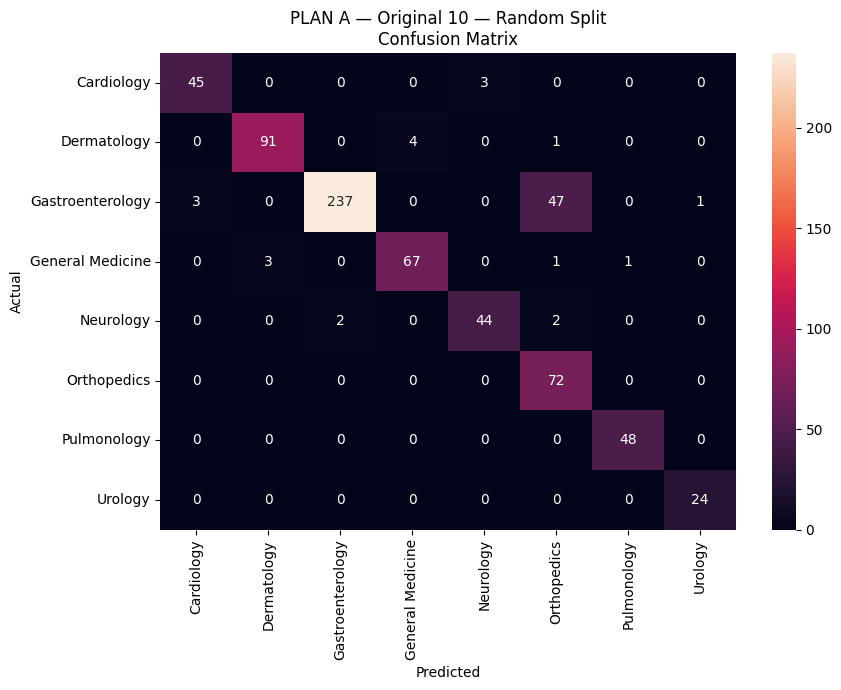


PLAN A — Original 10 — Disease Grouped
Split: Disease-grouped 80/20 split
Number of features: 10
Training rows: 2760
Testing rows: 720
Accuracy       : 0.6500
Macro F1       : 0.2723
Top-2 Accuracy : 0.9667
Top-3 Accuracy : 0.9917

Test-set class distribution:
Gastroenterology    480
General Medicine    120
Dermatology         120

Classification report:
                  precision    recall  f1-score   support

     Dermatology       1.00      0.95      0.97       120
Gastroenterology       1.00      0.72      0.84       480
General Medicine       0.50      0.05      0.09       120

       micro avg       0.99      0.65      0.78       720
       macro avg       0.83      0.57      0.64       720
    weighted avg       0.92      0.65      0.74       720



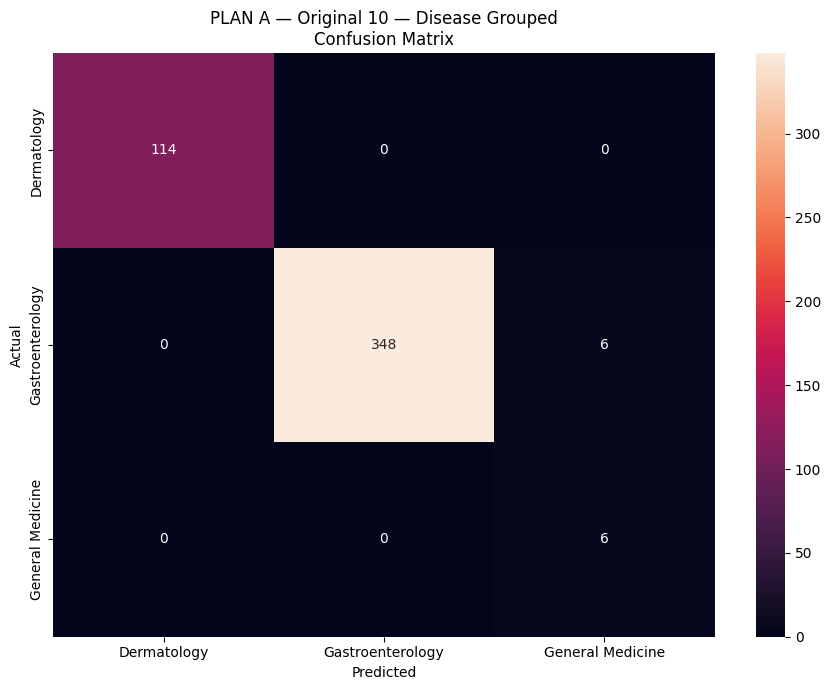


PLAN B — Statistical Top 10 — Random Split
Split: Stratified random 80/20 split
Number of features: 10
Training rows: 2784
Testing rows: 696
Accuracy       : 0.8348
Macro F1       : 0.8870
Top-2 Accuracy : 0.9885
Top-3 Accuracy : 0.9957

Test-set class distribution:
Gastroenterology    288
Dermatology          96
Orthopedics          72
General Medicine     72
Cardiology           48
Pulmonology          48
Neurology            48
Urology              24

Classification report:
                  precision    recall  f1-score   support

      Cardiology       0.94      0.94      0.94        48
     Dermatology       0.97      0.95      0.96        96
Gastroenterology       0.99      0.66      0.79       288
General Medicine       0.92      0.93      0.92        72
       Neurology       0.94      0.92      0.93        48
     Orthopedics       0.44      1.00      0.61        72
     Pulmonology       0.91      1.00      0.95        48
         Urology       1.00      1.00      1.00    

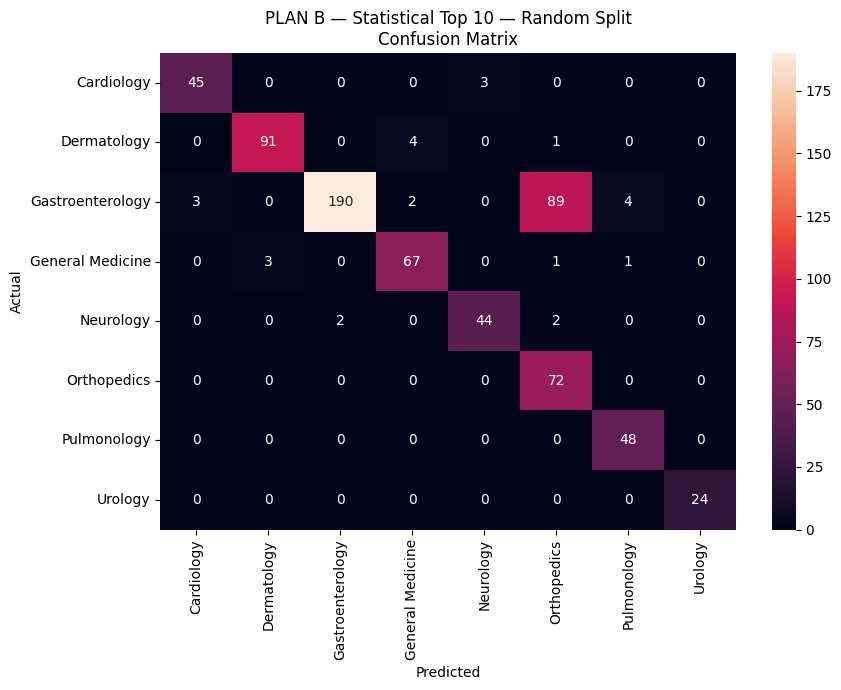


PLAN B — Statistical Top 10 — Disease Grouped
Split: Disease-grouped 80/20 split
Number of features: 10
Training rows: 2760
Testing rows: 720
Accuracy       : 0.6333
Macro F1       : 0.3148
Top-2 Accuracy : 0.9667
Top-3 Accuracy : 0.9917

Test-set class distribution:
Gastroenterology    480
General Medicine    120
Dermatology         120

Classification report:
                  precision    recall  f1-score   support

     Dermatology       1.00      0.95      0.97       120
Gastroenterology       1.00      0.70      0.82       480
General Medicine       0.50      0.05      0.09       120

       micro avg       0.99      0.63      0.77       720
       macro avg       0.83      0.57      0.63       720
    weighted avg       0.92      0.63      0.73       720



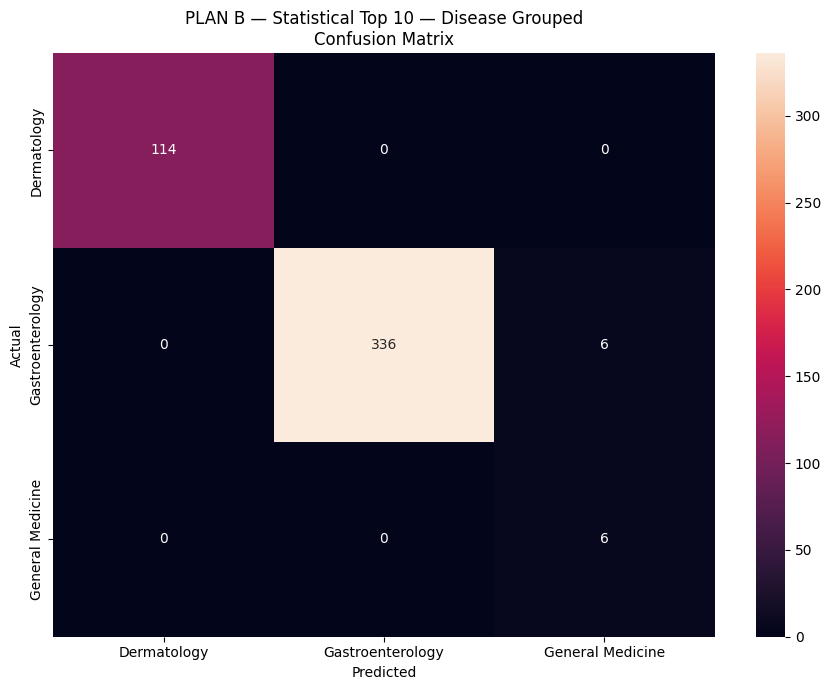


PLAN C — Patient-Friendly Grouped 10 — Random Split
Split: Stratified random 80/20 split
Number of features: 10
Training rows: 2784
Testing rows: 696
Accuracy       : 0.9799
Macro F1       : 0.9794
Top-2 Accuracy : 0.9914
Top-3 Accuracy : 0.9957

Test-set class distribution:
Gastroenterology    288
Dermatology          96
Orthopedics          72
General Medicine     72
Cardiology           48
Pulmonology          48
Neurology            48
Urology              24

Classification report:
                  precision    recall  f1-score   support

      Cardiology       0.94      1.00      0.97        48
     Dermatology       1.00      1.00      1.00        96
Gastroenterology       0.99      0.97      0.98       288
General Medicine       0.96      0.99      0.97        72
       Neurology       1.00      0.92      0.96        48
     Orthopedics       0.96      1.00      0.98        72
     Pulmonology       1.00      1.00      1.00        48
         Urology       0.96      1.00     

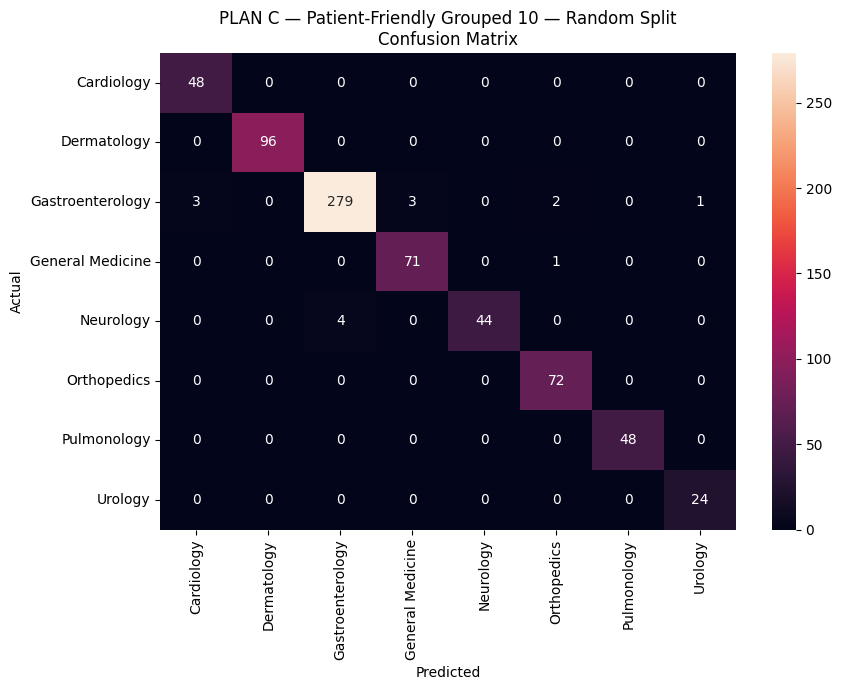


PLAN C — Patient-Friendly Grouped 10 — Disease Grouped
Split: Disease-grouped 80/20 split
Number of features: 10
Training rows: 2760
Testing rows: 720
Accuracy       : 0.6667
Macro F1       : 0.2685
Top-2 Accuracy : 0.9750
Top-3 Accuracy : 0.9833

Test-set class distribution:
Gastroenterology    480
General Medicine    120
Dermatology         120

Classification report:
                  precision    recall  f1-score   support

     Dermatology       0.50      1.00      0.67       120
Gastroenterology       1.00      0.74      0.85       480
General Medicine       1.00      0.05      0.10       120

       micro avg       0.80      0.67      0.73       720
       macro avg       0.83      0.60      0.54       720
    weighted avg       0.92      0.67      0.69       720



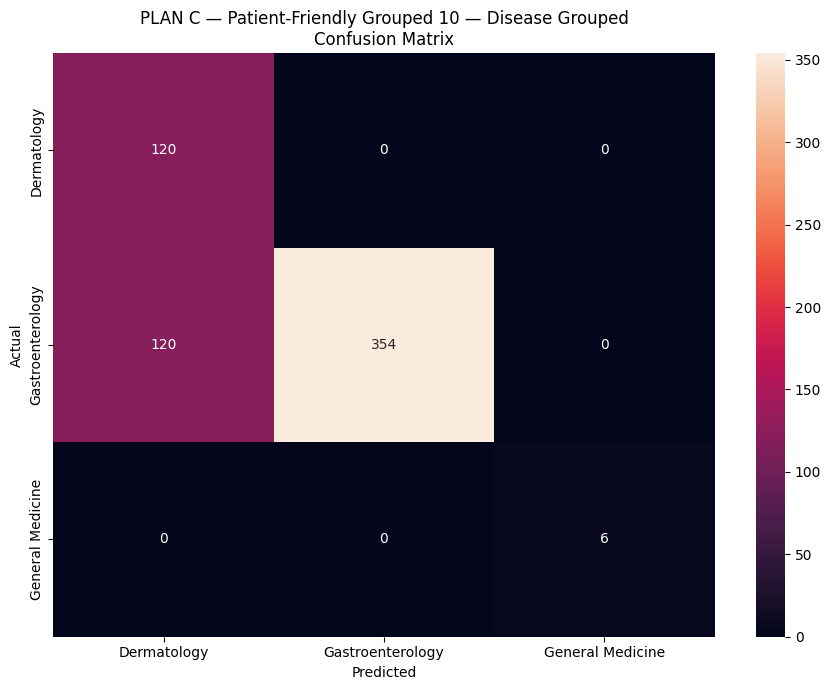


PLAN C+ — Grouped 10 + Urinary Detail — Random Split
Split: Stratified random 80/20 split
Number of features: 12
Training rows: 2784
Testing rows: 696
Accuracy       : 0.9813
Macro F1       : 0.9822
Top-2 Accuracy : 0.9914
Top-3 Accuracy : 0.9957

Test-set class distribution:
Gastroenterology    288
Dermatology          96
Orthopedics          72
General Medicine     72
Cardiology           48
Pulmonology          48
Neurology            48
Urology              24

Classification report:
                  precision    recall  f1-score   support

      Cardiology       0.94      1.00      0.97        48
     Dermatology       1.00      1.00      1.00        96
Gastroenterology       0.99      0.97      0.98       288
General Medicine       0.96      0.99      0.97        72
       Neurology       1.00      0.92      0.96        48
     Orthopedics       0.96      1.00      0.98        72
     Pulmonology       1.00      1.00      1.00        48
         Urology       1.00      1.00    

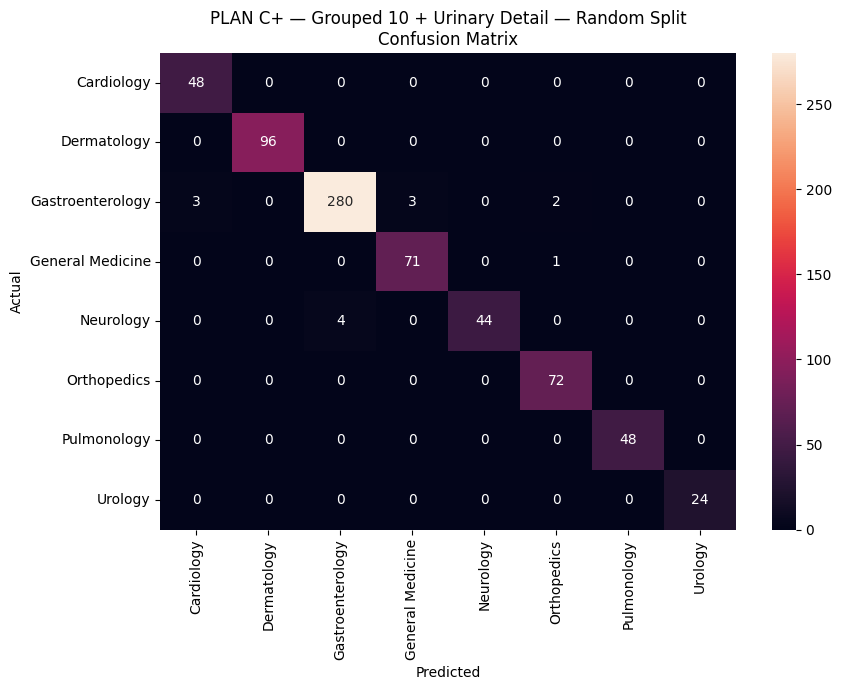


PLAN C+ — Grouped 10 + Urinary Detail — Disease Grouped
Split: Disease-grouped 80/20 split
Number of features: 12
Training rows: 2760
Testing rows: 720
Accuracy       : 0.6667
Macro F1       : 0.3200
Top-2 Accuracy : 0.9750
Top-3 Accuracy : 0.9833

Test-set class distribution:
Gastroenterology    480
General Medicine    120
Dermatology         120

Classification report:
                  precision    recall  f1-score   support

     Dermatology       0.49      1.00      0.66       120
Gastroenterology       1.00      0.74      0.85       480
General Medicine       1.00      0.05      0.10       120

       micro avg       0.79      0.67      0.72       720
       macro avg       0.83      0.60      0.53       720
    weighted avg       0.91      0.67      0.69       720



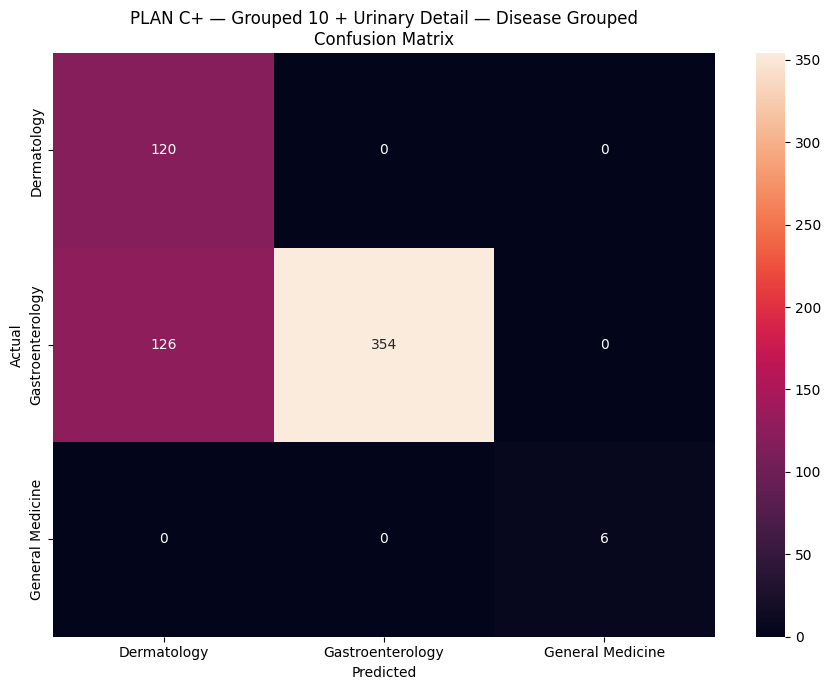


FINAL RANDOM-SPLIT COMPARISON
                                               model  features  accuracy  macro_f1  top2_accuracy  top3_accuracy
                 PLAN A — Original 10 — Random Split        10  0.902299  0.920744       0.988506       0.989943
          PLAN B — Statistical Top 10 — Random Split        10  0.834770  0.886951       0.988506       0.995690
 PLAN C — Patient-Friendly Grouped 10 — Random Split        10  0.979885  0.979405       0.991379       0.995690
PLAN C+ — Grouped 10 + Urinary Detail — Random Split        12  0.981322  0.982179       0.991379       0.995690

FINAL DISEASE-GROUPED COMPARISON
                                                  model  features  accuracy  macro_f1  top2_accuracy  top3_accuracy
                 PLAN A — Original 10 — Disease Grouped        10  0.650000  0.272264       0.966667       0.991667
          PLAN B — Statistical Top 10 — Disease Grouped        10  0.633333  0.314800       0.966667       0.991667
 PLAN C — Patient-Frie

In [ ]:
# ============================================================
# SMART HEALTHCARE POC — PLAN C EXPERIMENT (UPDATED)
#
# PURPOSE
# -------
# Compare different compact symptom representations for
# Logistic Regression specialty recommendation.
#
# PLAN A:
#   Original 10 broad symptoms
#
# PLAN B:
#   Statistical Top 10 raw symptoms
#
# PLAN C:
#   Patient-friendly grouped 10 symptoms
#
# PLAN C+:
#   Plan C + best 2 urinary subfeatures
#
# TARGET SPECIALTIES:
#   1. General Medicine
#   2. Cardiology
#   3. Pulmonology
#   4. Gastroenterology
#   5. Orthopedics
#   6. Neurology
#   7. Dermatology
#   8. Urology
#
# EVALUATION
# ----------
# 1. Stratified random 80/20 split
# 2. Disease-grouped 80/20 split
# 3. Accuracy
# 4. Macro F1
# 5. Top-2 accuracy
# 6. Top-3 accuracy
# 7. Classification report
# 8. Confusion matrix
#
# IMPORTANT
# ---------
# This is still an EXPERIMENT.
# We do NOT create the final dataset/model yet.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import re
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 220)

print("Libraries loaded successfully.")


# ============================================================
# 1. FIND / UPLOAD DATASETS
# ============================================================

possible_symptom_paths = [
    "/content/Symptom.csv",
    "/content/symptom.csv",
    "/mnt/data/Symptom.csv",
    "/mnt/data/symptom.csv"
]

possible_specialist_paths = [
    "/content/Disease Specialist.csv",
    "/content/Disease_Specialist.csv",
    "/content/disease specialist.csv",
    "/mnt/data/Disease Specialist.csv",
    "/mnt/data/Disease_Specialist.csv"
]

symptom_path = next(
    (p for p in possible_symptom_paths if os.path.exists(p)),
    None
)

specialist_path = next(
    (p for p in possible_specialist_paths if os.path.exists(p)),
    None
)


if symptom_path is None or specialist_path is None:

    print("\nFiles not found automatically.")
    print("Please upload BOTH CSV files.")

    from google.colab import files

    uploaded = files.upload()

    for name in uploaded.keys():

        normalized_name = (
            name.lower()
            .replace("_", " ")
            .strip()
        )

        if (
            "symptom" in normalized_name
            and "specialist" not in normalized_name
        ):
            symptom_path = f"/content/{name}"

        if "specialist" in normalized_name:
            specialist_path = f"/content/{name}"


if symptom_path is None:
    raise FileNotFoundError(
        "Could not find Symptom.csv"
    )

if specialist_path is None:
    raise FileNotFoundError(
        "Could not find Disease Specialist.csv"
    )


print("\nUsing:")
print("Symptom dataset   :", symptom_path)
print("Specialist dataset:", specialist_path)


# ============================================================
# 2. READ DATA
# ============================================================

symptom_df = pd.read_csv(symptom_path)
specialist_df = pd.read_csv(specialist_path)

print("\n" + "=" * 90)
print("DATASET SHAPES")
print("=" * 90)

print("Symptom.csv:", symptom_df.shape)
print("Disease Specialist.csv:", specialist_df.shape)


# ============================================================
# 3. CLEAN COLUMN NAMES
# ============================================================

def clean_column_name(col):
    col = str(col).strip().lower()
    col = col.replace(" ", "_")
    col = col.replace("-", "_")
    return col


symptom_df.columns = [
    clean_column_name(c)
    for c in symptom_df.columns
]

specialist_df.columns = [
    clean_column_name(c)
    for c in specialist_df.columns
]


# ============================================================
# 4. IDENTIFY IMPORTANT COLUMNS
# ============================================================

disease_candidates_symptom = [
    c for c in symptom_df.columns
    if c in ["disease", "diagnosis", "condition"]
]

disease_candidates_specialist = [
    c for c in specialist_df.columns
    if c in ["disease", "diagnosis", "condition"]
]

specialist_candidates = [
    c for c in specialist_df.columns
    if "special" in c or "doctor" in c
]


if not disease_candidates_symptom:
    raise ValueError(
        "Disease column was not found in Symptom.csv. "
        f"Columns: {symptom_df.columns.tolist()}"
    )

if not disease_candidates_specialist:
    raise ValueError(
        "Disease column was not found in specialist file. "
        f"Columns: {specialist_df.columns.tolist()}"
    )

if not specialist_candidates:
    raise ValueError(
        "Specialist column was not found. "
        f"Columns: {specialist_df.columns.tolist()}"
    )


disease_col_symptom = disease_candidates_symptom[0]
disease_col_specialist = disease_candidates_specialist[0]
specialist_col = specialist_candidates[0]


# ============================================================
# 5. TEXT NORMALIZATION
# ============================================================

def normalize_text(x):

    if pd.isna(x):
        return ""

    x = str(x).strip().lower()
    x = re.sub(r"\s+", " ", x)

    return x


symptom_df["_disease_key"] = (
    symptom_df[disease_col_symptom]
    .apply(normalize_text)
)

specialist_df["_disease_key"] = (
    specialist_df[disease_col_specialist]
    .apply(normalize_text)
)

specialist_df["_specialist_clean"] = (
    specialist_df[specialist_col]
    .astype(str)
    .str.strip()
)


# ============================================================
# 6. SPECIALTY NORMALIZATION
# ============================================================

SPECIALIST_MAP = {

    # General Medicine
    "primary care provider": "General Medicine",
    "general practitioner": "General Medicine",
    "general physician": "General Medicine",
    "general medicine": "General Medicine",

    # Cardiology
    "cardiologist": "Cardiology",
    "cardiology": "Cardiology",

    # Pulmonology
    "pulmonologist": "Pulmonology",
    "pulmonology": "Pulmonology",

    # Gastroenterology
    "gastroenterologist": "Gastroenterology",
    "gastroenterology": "Gastroenterology",
    "hepatologist": "Gastroenterology",
    "hepatology": "Gastroenterology",
    "proctologist": "Gastroenterology",

    # Orthopedics
    "orthopedic": "Orthopedics",
    "orthopaedic": "Orthopedics",
    "orthopedics": "Orthopedics",
    "orthopaedics": "Orthopedics",

    # Neurology
    "neurologist": "Neurology",
    "neurology": "Neurology",
    "neurosurgeon": "Neurology",

    # Dermatology
    "dermatologist": "Dermatology",
    "dermatology": "Dermatology",

    # Urology
    "urologist": "Urology",
    "urology": "Urology"
}


specialist_df["_specialty"] = (
    specialist_df["_specialist_clean"]
    .apply(normalize_text)
    .map(SPECIALIST_MAP)
)


TARGET_SPECIALTIES = [
    "General Medicine",
    "Cardiology",
    "Pulmonology",
    "Gastroenterology",
    "Orthopedics",
    "Neurology",
    "Dermatology",
    "Urology"
]


# ============================================================
# 7. MERGE DATASETS
# ============================================================

mapping_df = (
    specialist_df[
        ["_disease_key", "_specialty"]
    ]
    .drop_duplicates()
)

merged_df = symptom_df.merge(
    mapping_df,
    on="_disease_key",
    how="left"
)


# Keep only supported classes
model_df = merged_df[
    merged_df["_specialty"].isin(
        TARGET_SPECIALTIES
    )
].copy()


print("\n" + "=" * 90)
print("MERGED / FILTERED DATA")
print("=" * 90)

print("Total merged rows:", len(merged_df))
print("Usable rows:", len(model_df))

print("\nRows by specialty:")

print(
    model_df["_specialty"]
    .value_counts()
    .reindex(TARGET_SPECIALTIES)
    .fillna(0)
    .astype(int)
)


# ============================================================
# 8. IDENTIFY RAW SYMPTOM COLUMNS
# ============================================================

raw_symptom_columns = [
    c for c in model_df.columns
    if re.match(
        r"symptom_\d+$",
        c
    )
]

print("\n" + "=" * 90)
print("RAW SYMPTOM COLUMNS")
print("=" * 90)

print(raw_symptom_columns)


# ============================================================
# 9. COLLECT UNIQUE RAW SYMPTOMS
# ============================================================

all_symptoms = set()

for col in raw_symptom_columns:

    values = (
        model_df[col]
        .dropna()
        .apply(normalize_text)
    )

    for value in values:

        if value:
            all_symptoms.add(value)


all_symptoms = sorted(
    all_symptoms
)

print("\nUnique raw symptoms:", len(all_symptoms))


# ============================================================
# 10. CREATE RAW BINARY MATRIX
# ============================================================

raw_feature_matrix = pd.DataFrame(
    0,
    index=model_df.index,
    columns=all_symptoms
)

for col in raw_symptom_columns:

    col_values = (
        model_df[col]
        .fillna("")
        .apply(normalize_text)
    )

    for symptom in all_symptoms:

        mask = (
            col_values == symptom
        )

        raw_feature_matrix.loc[
            mask,
            symptom
        ] = 1


raw_feature_matrix = (
    raw_feature_matrix.astype(int)
)


# ============================================================
# 11. HELPER TO BUILD GROUPED FEATURES
# ============================================================

def build_grouped_feature(
    feature_name,
    source_symptoms,
    matrix
):
    """
    Creates one binary feature from a set of source symptoms.

    If ANY source symptom is present:
        feature = 1

    Otherwise:
        feature = 0
    """

    available = [
        s for s in source_symptoms
        if s in matrix.columns
    ]

    if not available:

        print(
            f"WARNING: No source symptoms found "
            f"for {feature_name}"
        )

        return pd.Series(
            0,
            index=matrix.index,
            name=feature_name
        )

    result = (
        matrix[available]
        .max(axis=1)
        .astype(int)
    )

    result.name = feature_name

    return result


# ============================================================
# 12. PLAN C DEFINITIONS
# ============================================================

GROUP_DEFINITIONS = {

    "fever": [
        "fever",
        "high_fever",
        "mild_fever"
    ],

    "cough": [
        "cough"
    ],

    "breathlessness": [
        "breathlessness"
    ],

    "chest_pain": [
        "chest_pain"
    ],

    "headache": [
        "headache"
    ],

    "digestive_problem": [
        "abdominal_pain",
        "stomach_pain",
        "vomiting",
        "nausea",
        "indigestion",
        "acidity",
        "diarrhoea",
        "constipation"
    ],

    "joint_or_muscle_problem": [
        "joint_pain",
        "painful_walking",
        "swelling_joints",
        "neck_pain",
        "knee_pain",
        "hip_joint_pain",
        "movement_stiffness",
        "muscle_pain",
        "muscle_weakness"
    ],

    "skin_problem": [
        "skin_rash",
        "itching",
        "blister",
        "skin_peeling",
        "inflammatory_nails"
    ],

    "urinary_problem": [
        "continuous_feel_of_urine",
        "bladder_discomfort",
        "burning_micturition",
        "foul_smell_of urine",
        "yellow_urine"
    ],

    "fatigue": [
        "fatigue",
        "malaise",
        "lethargy"
    ]
}


# ============================================================
# 13. SHOW GROUP → RAW FEATURE MAPPING
# ============================================================

print("\n" + "=" * 110)
print("PLAN C GROUP DEFINITIONS")
print("=" * 110)

for group_name, source_list in GROUP_DEFINITIONS.items():

    available = [
        s
        for s in source_list
        if s in raw_feature_matrix.columns
    ]

    print("\n" + group_name)
    print("Requested:")
    print(source_list)

    print("Available in dataset:")
    print(available)


# ============================================================
# 14. BUILD PLAN C
# ============================================================

grouped_features_df = pd.DataFrame(
    index=model_df.index
)

for group_name, source_list in GROUP_DEFINITIONS.items():

    grouped_features_df[group_name] = (
        build_grouped_feature(
            group_name,
            source_list,
            raw_feature_matrix
        )
    )


PLAN_C_FEATURES = [
    "fever",
    "cough",
    "breathlessness",
    "chest_pain",
    "headache",
    "digestive_problem",
    "joint_or_muscle_problem",
    "skin_problem",
    "urinary_problem",
    "fatigue"
]


# ============================================================
# 15. PLAN A — ORIGINAL USER DESIGN
# ============================================================

PLAN_A_FEATURES = [
    "fever",
    "cough",
    "breathlessness",
    "chest_pain",
    "headache",
    "vomiting",
    "abdominal_pain",
    "joint_pain",
    "skin_rash",
    "urinary_problem"
]


plan_a_df = pd.DataFrame(
    index=model_df.index
)


# Simple direct features
direct_features = [
    "cough",
    "breathlessness",
    "chest_pain",
    "headache",
    "vomiting",
    "abdominal_pain",
    "joint_pain",
    "skin_rash"
]


for feature in direct_features:

    if feature in raw_feature_matrix.columns:

        plan_a_df[feature] = (
            raw_feature_matrix[feature]
            .astype(int)
        )

    else:

        plan_a_df[feature] = 0


# Fever grouping
plan_a_df["fever"] = (
    build_grouped_feature(
        "fever",
        [
            "fever",
            "high_fever",
            "mild_fever"
        ],
        raw_feature_matrix
    )
)


# Urinary grouping
plan_a_df["urinary_problem"] = (
    build_grouped_feature(
        "urinary_problem",
        [
            "continuous_feel_of_urine",
            "bladder_discomfort",
            "burning_micturition",
            "foul_smell_of urine",
            "yellow_urine"
        ],
        raw_feature_matrix
    )
)

plan_a_df = plan_a_df[
    PLAN_A_FEATURES
]


# ============================================================
# 16. CREATE STATISTICAL TOP-10 (PLAN B)
# ============================================================

X_raw = raw_feature_matrix[
    all_symptoms
].astype(int)

label_encoder = LabelEncoder()

y_numeric = label_encoder.fit_transform(
    model_df["_specialty"].astype(str)
)


# ------------------------------------------------------------
# Chi-square
# ------------------------------------------------------------

chi_values, chi_pvalues = chi2(
    X_raw,
    y_numeric
)

chi_rank_df = pd.DataFrame({
    "feature": all_symptoms,
    "chi2": chi_values,
    "chi2_p": chi_pvalues
})

chi_rank_df = (
    chi_rank_df
    .sort_values(
        "chi2",
        ascending=False
    )
    .reset_index(drop=True)
)

chi_rank_df["chi_rank"] = (
    np.arange(len(chi_rank_df)) + 1
)


# ------------------------------------------------------------
# Mutual Information
# ------------------------------------------------------------

mi_values = mutual_info_classif(
    X_raw,
    y_numeric,
    discrete_features=True,
    random_state=42
)

mi_rank_df = pd.DataFrame({
    "feature": all_symptoms,
    "mutual_information": mi_values
})

mi_rank_df = (
    mi_rank_df
    .sort_values(
        "mutual_information",
        ascending=False
    )
    .reset_index(drop=True)
)

mi_rank_df["mi_rank"] = (
    np.arange(len(mi_rank_df)) + 1
)


# ------------------------------------------------------------
# Logistic Regression coefficient strength
# ------------------------------------------------------------

lr_all = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=42
)

lr_all.fit(
    X_raw,
    y_numeric
)

coef_strength = np.mean(
    np.abs(lr_all.coef_),
    axis=0
)

coef_rank_df = pd.DataFrame({
    "feature": all_symptoms,
    "logreg_strength": coef_strength
})

coef_rank_df = (
    coef_rank_df
    .sort_values(
        "logreg_strength",
        ascending=False
    )
    .reset_index(drop=True)
)

coef_rank_df["logreg_rank"] = (
    np.arange(len(coef_rank_df)) + 1
)


# ------------------------------------------------------------
# Combine ranking methods
# ------------------------------------------------------------

ranking = (
    chi_rank_df[
        [
            "feature",
            "chi2",
            "chi2_p",
            "chi_rank"
        ]
    ]
    .merge(
        mi_rank_df[
            [
                "feature",
                "mutual_information",
                "mi_rank"
            ]
        ],
        on="feature"
    )
    .merge(
        coef_rank_df[
            [
                "feature",
                "logreg_strength",
                "logreg_rank"
            ]
        ],
        on="feature"
    )
)


ranking["average_rank"] = (
    ranking[
        [
            "chi_rank",
            "mi_rank",
            "logreg_rank"
        ]
    ]
    .mean(axis=1)
)

ranking = (
    ranking
    .sort_values(
        "average_rank"
    )
    .reset_index(drop=True)
)

ranking["consensus_rank"] = (
    np.arange(len(ranking)) + 1
)


PLAN_B_FEATURES = (
    ranking
    .head(10)["feature"]
    .tolist()
)

plan_b_df = raw_feature_matrix[
    PLAN_B_FEATURES
].copy()


# ============================================================
# 17. STATISTICAL TOP FEATURE REPORT
# ============================================================

print("\n" + "=" * 110)
print("STATISTICAL FEATURE RANKING — TOP 20")
print("=" * 110)

print(
    ranking[
        [
            "consensus_rank",
            "feature",
            "chi2",
            "mutual_information",
            "logreg_strength",
            "average_rank"
        ]
    ]
    .head(20)
    .to_string(index=False)
)


# ============================================================
# 18. PLAN B TOP 10
# ============================================================

print("\n" + "=" * 90)
print("PLAN B — STATISTICAL TOP 10")
print("=" * 90)

for i, feature in enumerate(
    PLAN_B_FEATURES,
    1
):
    print(
        f"{i:2d}. {feature}"
    )


# ============================================================
# 19. URINARY SUBFEATURE ANALYSIS
# ============================================================

URINARY_SUBFEATURES = [
    "continuous_feel_of_urine",
    "bladder_discomfort",
    "burning_micturition",
    "foul_smell_of urine",
    "yellow_urine"
]

available_urinary = [
    feature
    for feature in URINARY_SUBFEATURES
    if feature in raw_feature_matrix.columns
]


print("\n" + "=" * 110)
print("URINARY SUBFEATURES")
print("=" * 110)

print(
    available_urinary
)


urinary_results = []


for feature in available_urinary:

    x = raw_feature_matrix[
        feature
    ]

    # Chi-square
    chi_value = chi2(
        x.to_frame(),
        y_numeric
    )[0][0]

    # Mutual information
    mi_value = mutual_info_classif(
        x.to_frame(),
        y_numeric,
        discrete_features=True,
        random_state=42
    )[0]

    # Specialty rates
    temp_df = pd.DataFrame({
        "specialty": model_df["_specialty"].values,
        "feature_value": x.values
    })

    rates = (
        temp_df
        .groupby("specialty")[
            "feature_value"
        ]
        .mean()
    )

    rates = rates.reindex(
        TARGET_SPECIALTIES
    ).fillna(0)

    best_specialty = (
        rates.idxmax()
    )

    best_rate = (
        rates.max()
    )

    urinary_results.append({
        "feature": feature,
        "chi2": chi_value,
        "mutual_information": mi_value,
        "best_specialty": best_specialty,
        "best_specialty_rate": best_rate
    })


urinary_rank = pd.DataFrame(
    urinary_results
)


if len(urinary_rank) > 0:

    urinary_rank["chi_rank"] = (
        urinary_rank["chi2"]
        .rank(
            ascending=False,
            method="min"
        )
    )

    urinary_rank["mi_rank"] = (
        urinary_rank["mutual_information"]
        .rank(
            ascending=False,
            method="min"
        )
    )

    urinary_rank["specificity_rank"] = (
        urinary_rank["best_specialty_rate"]
        .rank(
            ascending=False,
            method="min"
        )
    )

    urinary_rank["average_rank"] = (
        urinary_rank[
            [
                "chi_rank",
                "mi_rank",
                "specificity_rank"
            ]
        ]
        .mean(axis=1)
    )

    urinary_rank = (
        urinary_rank
        .sort_values(
            "average_rank"
        )
        .reset_index(drop=True)
    )


print("\n" + "=" * 110)
print("URINARY SUBFEATURE RANKING")
print("=" * 110)

if len(urinary_rank) > 0:

    print(
        urinary_rank.to_string(
            index=False
        )
    )

else:

    print(
        "No urinary subfeatures available."
    )


# ============================================================
# 20. SELECT BEST TWO URINARY FEATURES
# ============================================================

if len(urinary_rank) >= 2:

    best_urinary = (
        urinary_rank
        .head(2)["feature"]
        .tolist()
    )

elif len(urinary_rank) == 1:

    best_urinary = (
        urinary_rank["feature"]
        .tolist()
    )

else:

    best_urinary = []


print("\n" + "=" * 90)
print("BEST URINARY SUBFEATURES")
print("=" * 90)

for i, feature in enumerate(
    best_urinary,
    1
):
    print(
        f"{i}. {feature}"
    )


# ============================================================
# 21. PLAN C+
# ============================================================

plan_c_plus_df = grouped_features_df[
    PLAN_C_FEATURES
].copy()


for feature in best_urinary:

    plan_c_plus_df[feature] = (
        raw_feature_matrix[
            feature
        ]
        .astype(int)
    )


PLAN_C_PLUS_FEATURES = (
    PLAN_C_FEATURES
    + best_urinary
)


# ============================================================
# 22. TARGET
# ============================================================

y_series = (
    model_df["_specialty"]
    .astype(str)
)


# ============================================================
# 23. CUSTOM TOP-K CALCULATION
# ============================================================
#
# We DO NOT use sklearn top_k_accuracy_score here because
# disease-grouped splits can contain only a subset of classes.
#
# Instead:
#
# For each sample:
#   sort predicted probabilities descending
#   see if true class is within the top k
#
# This works even when some classes are absent from the
# particular test split.
# ============================================================

def custom_top_k_accuracy(
    y_true,
    probabilities,
    model_classes,
    k
):

    y_true = np.asarray(
        y_true
    )

    probabilities = np.asarray(
        probabilities
    )

    # map labels to model probability column positions
    class_to_index = {
        cls: idx
        for idx, cls in enumerate(
            model_classes
        )
    }

    correct = 0
    total = len(y_true)

    for true_label, probs in zip(
        y_true,
        probabilities
    ):

        # sort indices by probability descending
        ranked_indices = np.argsort(
            probs
        )[::-1]

        top_indices = ranked_indices[
            :k
        ]

        true_index = (
            class_to_index.get(
                true_label,
                None
            )
        )

        if (
            true_index is not None
            and true_index in top_indices
        ):
            correct += 1

    if total == 0:
        return np.nan

    return correct / total


# ============================================================
# 24. ROBUST MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    X_df,
    y_values,
    title,
    grouped=False
):

    X_df = X_df.copy()

    y_values = np.asarray(
        y_values
    )

    # --------------------------------------------------------
    # SPLIT
    # --------------------------------------------------------

    if grouped:

        groups = (
            model_df["_disease_key"]
            .values
        )

        splitter = GroupShuffleSplit(
            n_splits=1,
            test_size=0.20,
            random_state=42
        )

        train_idx, test_idx = next(
            splitter.split(
                X_df,
                y_values,
                groups=groups
            )
        )

        split_name = (
            "Disease-grouped 80/20 split"
        )

    else:

        train_idx, test_idx = (
            train_test_split(
                np.arange(
                    len(X_df)
                ),
                test_size=0.20,
                random_state=42,
                stratify=y_values
            )
        )

        split_name = (
            "Stratified random 80/20 split"
        )


    X_train = X_df.iloc[
        train_idx
    ]

    X_test = X_df.iloc[
        test_idx
    ]

    y_train = y_values[
        train_idx
    ]

    y_test = y_values[
        test_idx
    ]


    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------

    model = LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42
    )


    model.fit(
        X_train,
        y_train
    )


    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    predictions = (
        model.predict(
            X_test
        )
    )

    probabilities = (
        model.predict_proba(
            X_test
        )
    )


    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    accuracy = (
        accuracy_score(
            y_test,
            predictions
        )
    )

    macro_f1 = (
        f1_score(
            y_test,
            predictions,
            average="macro"
        )
    )


    top2 = custom_top_k_accuracy(
        y_test,
        probabilities,
        model.classes_,
        k=2
    )

    top3 = custom_top_k_accuracy(
        y_test,
        probabilities,
        model.classes_,
        k=3
    )


    # --------------------------------------------------------
    # PRINT
    # --------------------------------------------------------

    print("\n" + "=" * 110)
    print(title)
    print("=" * 110)

    print("Split:", split_name)

    print(
        "Number of features:",
        X_df.shape[1]
    )

    print(
        "Training rows:",
        len(X_train)
    )

    print(
        "Testing rows:",
        len(X_test)
    )

    print(
        f"Accuracy       : {accuracy:.4f}"
    )

    print(
        f"Macro F1       : {macro_f1:.4f}"
    )

    print(
        f"Top-2 Accuracy : {top2:.4f}"
    )

    print(
        f"Top-3 Accuracy : {top3:.4f}"
    )


    # --------------------------------------------------------
    # TEST CLASS DISTRIBUTION
    # --------------------------------------------------------

    print(
        "\nTest-set class distribution:"
    )

    print(
        pd.Series(
            y_test
        )
        .value_counts()
        .to_string()
    )


    # --------------------------------------------------------
    # CLASSIFICATION REPORT
    # --------------------------------------------------------

    present_labels = (
        np.unique(
            y_test
        )
    )

    present_names = [
        str(x)
        for x in present_labels
    ]

    print(
        "\nClassification report:"
    )

    print(
        classification_report(
            y_test,
            predictions,
            labels=present_labels,
            target_names=present_names,
            zero_division=0
        )
    )


    # --------------------------------------------------------
    # CONFUSION MATRIX
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        predictions,
        labels=present_labels
    )

    plt.figure(
        figsize=(9, 7)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=present_names,
        yticklabels=present_names
    )

    plt.title(
        title + "\nConfusion Matrix"
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "Actual"
    )

    plt.tight_layout()

    plt.show()


    return {
        "model": title,
        "features": X_df.shape[1],
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "top2_accuracy": top2,
        "top3_accuracy": top3
    }


# ============================================================
# 25. RUN ALL MODELS
# ============================================================

random_results = []
grouped_results = []


# ------------------------------------------------------------
# PLAN A
# ------------------------------------------------------------

random_results.append(
    evaluate_model(
        plan_a_df,
        y_series,
        "PLAN A — Original 10 — Random Split",
        grouped=False
    )
)

grouped_results.append(
    evaluate_model(
        plan_a_df,
        y_series,
        "PLAN A — Original 10 — Disease Grouped",
        grouped=True
    )
)


# ------------------------------------------------------------
# PLAN B
# ------------------------------------------------------------

random_results.append(
    evaluate_model(
        plan_b_df,
        y_series,
        "PLAN B — Statistical Top 10 — Random Split",
        grouped=False
    )
)

grouped_results.append(
    evaluate_model(
        plan_b_df,
        y_series,
        "PLAN B — Statistical Top 10 — Disease Grouped",
        grouped=True
    )
)


# ------------------------------------------------------------
# PLAN C
# ------------------------------------------------------------

random_results.append(
    evaluate_model(
        grouped_features_df[
            PLAN_C_FEATURES
        ],
        y_series,
        "PLAN C — Patient-Friendly Grouped 10 — Random Split",
        grouped=False
    )
)

grouped_results.append(
    evaluate_model(
        grouped_features_df[
            PLAN_C_FEATURES
        ],
        y_series,
        "PLAN C — Patient-Friendly Grouped 10 — Disease Grouped",
        grouped=True
    )
)


# ------------------------------------------------------------
# PLAN C+
# ------------------------------------------------------------

random_results.append(
    evaluate_model(
        plan_c_plus_df[
            PLAN_C_PLUS_FEATURES
        ],
        y_series,
        "PLAN C+ — Grouped 10 + Urinary Detail — Random Split",
        grouped=False
    )
)

grouped_results.append(
    evaluate_model(
        plan_c_plus_df[
            PLAN_C_PLUS_FEATURES
        ],
        y_series,
        "PLAN C+ — Grouped 10 + Urinary Detail — Disease Grouped",
        grouped=True
    )
)


# ============================================================
# 26. COMPARISON TABLES
# ============================================================

random_results_df = pd.DataFrame(
    random_results
)

grouped_results_df = pd.DataFrame(
    grouped_results
)


print("\n" + "=" * 120)
print("FINAL RANDOM-SPLIT COMPARISON")
print("=" * 120)

print(
    random_results_df.to_string(
        index=False
    )
)


print("\n" + "=" * 120)
print("FINAL DISEASE-GROUPED COMPARISON")
print("=" * 120)

print(
    grouped_results_df.to_string(
        index=False
    )
)


# ============================================================
# 27. FEATURE SETS
# ============================================================

print("\n" + "=" * 110)
print("FEATURE SETS")
print("=" * 110)


print("\nPLAN A:")
for i, feature in enumerate(
    PLAN_A_FEATURES,
    1
):
    print(
        f"{i:2d}. {feature}"
    )


print("\nPLAN B:")
for i, feature in enumerate(
    PLAN_B_FEATURES,
    1
):
    print(
        f"{i:2d}. {feature}"
    )


print("\nPLAN C:")
for i, feature in enumerate(
    PLAN_C_FEATURES,
    1
):
    print(
        f"{i:2d}. {feature}"
    )


print("\nPLAN C+:")
for i, feature in enumerate(
    PLAN_C_PLUS_FEATURES,
    1
):
    print(
        f"{i:2d}. {feature}"
    )


# ============================================================
# 28. PLAN C SPECIALTY OCCURRENCE RATES
# ============================================================

print("\n" + "=" * 120)
print("PLAN C — FEATURE PRESENCE BY SPECIALTY")
print("=" * 120)

plan_c_with_target = pd.concat(
    [
        grouped_features_df[
            PLAN_C_FEATURES
        ],
        model_df[
            "_specialty"
        ]
    ],
    axis=1
)

plan_c_specialty_rates = (
    plan_c_with_target
    .groupby("_specialty")[
        PLAN_C_FEATURES
    ]
    .mean()
    .reindex(
        TARGET_SPECIALTIES
    )
)

print(
    plan_c_specialty_rates
    .round(3)
    .to_string()
)


# ============================================================
# 29. FEATURE → BEST SPECIALTY
# ============================================================

print("\n" + "=" * 110)
print("PLAN C — BEST SPECIALTY FOR EACH FEATURE")
print("=" * 110)

for feature in PLAN_C_FEATURES:

    rates = (
        plan_c_with_target
        .groupby("_specialty")[
            feature
        ]
        .mean()
        .reindex(
            TARGET_SPECIALTIES
        )
        .fillna(0)
        .sort_values(
            ascending=False
        )
    )

    print(
        f"{feature:30s}"
        f" → {rates.index[0]:20s}"
        f" ({rates.iloc[0]:.3f})"
    )


# ============================================================
# 30. FEATURE USAGE
# ============================================================

print("\n" + "=" * 110)
print("PLAN C FEATURE USAGE")
print("=" * 110)

usage_rows = []

for feature in PLAN_C_FEATURES:

    positive_rows = int(
        grouped_features_df[
            feature
        ].sum()
    )

    positive_rate = (
        grouped_features_df[
            feature
        ].mean()
    )

    usage_rows.append({
        "feature": feature,
        "positive_rows": positive_rows,
        "positive_rate": positive_rate
    })


usage_df = pd.DataFrame(
    usage_rows
)

print(
    usage_df.to_string(
        index=False
    )
)


# ============================================================
# 31. TOP 20 STATISTICAL FEATURES
# ============================================================

print("\n" + "=" * 110)
print("TOP 20 STATISTICAL FEATURES")
print("=" * 110)

for i, feature in enumerate(
    ranking.head(20)["feature"],
    1
):
    print(
        f"{i:2d}. {feature}"
    )


# ============================================================
# 32. SAVE RESULTS
# ============================================================

ranking.to_csv(
    "/content/feature_ranking_plan_c_experiment.csv",
    index=False
)

random_results_df.to_csv(
    "/content/plan_comparison_random.csv",
    index=False
)

grouped_results_df.to_csv(
    "/content/plan_comparison_disease_grouped.csv",
    index=False
)

urinary_rank.to_csv(
    "/content/urinary_subfeature_ranking.csv",
    index=False
)

plan_c_specialty_rates.to_csv(
    "/content/plan_c_specialty_feature_rates.csv"
)


# ============================================================
# 33. FINAL COPY/PASTE SUMMARY
# ============================================================

print("\n" + "=" * 130)
print("FINAL SUMMARY — COPY THIS WHOLE SECTION BACK TO CHATGPT")
print("=" * 130)


print("\nSOURCE DATA:")
print(
    "Symptom rows:",
    len(symptom_df)
)

print(
    "Specialist rows:",
    len(specialist_df)
)

print(
    "Usable merged rows:",
    len(model_df)
)

print(
    "Raw candidate symptoms:",
    len(all_symptoms)
)


print("\nTARGET SPECIALTIES:")
for specialty in TARGET_SPECIALTIES:
    print(
        " -",
        specialty
    )


print("\nPLAN A:")
print(
    PLAN_A_FEATURES
)


print("\nPLAN B:")
print(
    PLAN_B_FEATURES
)


print("\nPLAN C:")
print(
    PLAN_C_FEATURES
)


print("\nBEST URINARY SUBFEATURES:")
print(
    best_urinary
)


print("\nPLAN C+:")
print(
    PLAN_C_PLUS_FEATURES
)


print("\nRANDOM-SPLIT RESULTS:")
print(
    random_results_df.to_string(
        index=False
    )
)


print("\nDISEASE-GROUPED RESULTS:")
print(
    grouped_results_df.to_string(
        index=False
    )
)


print("\nPLAN C SPECIALTY RATES:")
print(
    plan_c_specialty_rates
    .round(3)
    .to_string()
)


print("\nTOP 20 STATISTICAL FEATURES:")
for i, feature in enumerate(
    ranking.head(20)["feature"],
    1
):
    print(
        f"{i}. {feature}"
    )


print("\nOUTPUT FILES:")
print(
    "/content/feature_ranking_plan_c_experiment.csv"
)

print(
    "/content/plan_comparison_random.csv"
)

print(
    "/content/plan_comparison_disease_grouped.csv"
)

print(
    "/content/urinary_subfeature_ranking.csv"
)

print(
    "/content/plan_c_specialty_feature_rates.csv"
)


print("\nEXPERIMENT COMPLETE.")
print(
    "Do NOT create the final custom dataset yet."
)
print(
    "Paste the FINAL SUMMARY section back into ChatGPT."
)

In [ ]:
!pip install fpdf2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.0/337.0 kB 32.1 MB/s eta 0:00:00


In [ ]:
from fpdf import FPDF
import pandas as pd

class ExperimentReport(FPDF):
    def header(self):
        self.set_font('Helvetica', 'B', 15)
        self.cell(0, 10, 'Smart Healthcare POC - Experiment Summary Report', border=True, ln=1, align='C')
        self.ln(5)

    def add_section(self, title):
        self.set_font('Helvetica', 'B', 12)
        self.set_fill_color(200, 220, 255)
        self.cell(0, 10, title, ln=1, fill=True)
        self.ln(2)

    def add_table_from_df(self, df):
        self.set_font('Courier', '', 8)
        # Clean characters that FPDF core fonts can't handle (like em-dash)
        table_text = df.to_string(index=False).replace('\u2014', '-')
        self.multi_cell(0, 5, table_text, border=1)
        self.ln(5)

def create_pdf_summary():
    pdf = ExperimentReport()
    pdf.add_page()

    # 1. Source Data Info
    pdf.add_section("1. Source Data Overview")
    pdf.set_font('Helvetica', '', 10)
    pdf.cell(0, 10, f"Usable Merged Rows: {len(model_df)}", ln=1)
    pdf.cell(0, 10, f"Raw Candidate Symptoms: {len(all_symptoms)}", ln=1)
    pdf.ln(5)

    # 2. Plan Comparison (Random Split)
    pdf.add_section("2. Performance: Random Split Results")
    pdf.add_table_from_df(random_results_df.round(4))

    # 3. Plan Comparison (Disease Grouped)
    pdf.add_section("3. Performance: Disease-Grouped Results")
    pdf.add_table_from_df(grouped_results_df.round(4))

    # 4. Feature Sets Detail
    pdf.add_section("4. Selected Feature Sets (Top 10 / Plan C+)")
    pdf.set_font('Helvetica', '', 9)
    # Clean the feature lists for special chars too
    plan_b_text = ', '.join(PLAN_B_FEATURES).replace('\u2014', '-')
    plan_c_plus_text = ', '.join(PLAN_C_PLUS_FEATURES).replace('\u2014', '-')
    pdf.multi_cell(0, 5, f"Plan B (Statistical Top 10): {plan_b_text}\n\n"
                         f"Plan C+ (Grouped + Urinary): {plan_c_plus_text}")
    pdf.ln(5)

    # 5. Statistical Rankings
    pdf.add_section("5. Top 20 Statistical Consensus Features")
    pdf.add_table_from_df(ranking[['consensus_rank', 'feature', 'average_rank']].head(20))

    # Output
    output_path = "/content/POC_Experiment_Final_Report.pdf"
    pdf.output(output_path)
    print(f"PDF Report created successfully at: {output_path}")

create_pdf_summary()

PDF Report created successfully at: /content/POC_Experiment_Final_Report.pdf


In [ ]:
# ============================================================
# SMART HEALTHCARE POC
# FINAL FEATURE-SELECTION + MODEL-COMPARISON EXPERIMENT
#
# PURPOSE
# -------
# This is the FINAL analytical experiment before we freeze:
#
#   - target specialties
#   - patient-facing feature concepts
#   - urinary subfeatures
#   - custom dataset design
#
# WE COMPARE:
#
# PLAN A:
#   Original 10 broad features
#
# PLAN B:
#   Statistical Top 10 raw symptoms
#
# PLAN C:
#   Patient-friendly grouped 10 features
#
# PLAN C+:
#   Plan C + 2 urinary detail features
#
#
# TARGET SPECIALTIES
# ------------------
# 1. General Medicine
# 2. Cardiology
# 3. Pulmonology
# 4. Gastroenterology
# 5. Orthopedics
# 6. Neurology
# 7. Dermatology
# 8. Urology
#
#
# ANALYSIS
# --------
# - Merge both datasets
# - Clean symptom values
# - Build binary symptom matrix
# - Rank 100 candidate symptoms
# - Chi-square
# - Mutual Information
# - Logistic Regression coefficient strength
# - Specificity
# - Redundancy/correlation
# - Compare Plan A / B / C / C+
# - Random stratified evaluation
# - Disease-grouped stratified evaluation
# - Accuracy
# - Macro F1
# - Top-2 accuracy
# - Top-3 accuracy
# - Classification reports
# - Confusion matrices
# - Specialty feature rates
# - Urinary subfeature ranking
#
#
# OUTPUTS
# -------
# /content/final_feature_experiment_report.pdf
# /content/final_feature_experiment_summary.txt
# /content/final_feature_analysis_bundle.zip
#
# Plus useful CSV files.
#
# IMPORTANT
# ---------
# DO NOT BUILD THE FINAL CUSTOM DATASET YET.
#
# Run this and send me the PDF.
# ============================================================


# ============================================================
# 0. INSTALL / IMPORT
# ============================================================

!pip -q install pandas numpy scikit-learn matplotlib seaborn reportlab openpyxl

import os
import re
import zipfile
import warnings
import textwrap
import math

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# StratifiedGroupKFold is preferred for disease-aware evaluation
try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
except ImportError:
    HAS_STRATIFIED_GROUP_KFOLD = False
    from sklearn.model_selection import GroupShuffleSplit

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch, mm
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    PageBreak,
    Image as RLImage,
    KeepTogether
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 240)

print("Libraries loaded successfully.")


# ============================================================
# 1. FILE DISCOVERY / UPLOAD
# ============================================================

possible_symptom_paths = [
    "/content/Symptom.csv",
    "/content/symptom.csv",
    "/mnt/data/Symptom.csv",
    "/mnt/data/symptom.csv"
]

possible_specialist_paths = [
    "/content/Disease Specialist.csv",
    "/content/Disease_Specialist.csv",
    "/content/disease specialist.csv",
    "/mnt/data/Disease Specialist.csv",
    "/mnt/data/Disease_Specialist.csv"
]

symptom_path = next(
    (p for p in possible_symptom_paths if os.path.exists(p)),
    None
)

specialist_path = next(
    (p for p in possible_specialist_paths if os.path.exists(p)),
    None
)


if symptom_path is None or specialist_path is None:

    print("\nFiles not found automatically.")
    print("Please upload BOTH CSV files.")

    from google.colab import files

    uploaded = files.upload()

    for name in uploaded.keys():

        n = (
            name.lower()
            .replace("_", " ")
            .strip()
        )

        if (
            "symptom" in n
            and "specialist" not in n
        ):
            symptom_path = f"/content/{name}"

        if "specialist" in n:
            specialist_path = f"/content/{name}"


if symptom_path is None:
    raise FileNotFoundError("Could not find Symptom.csv")

if specialist_path is None:
    raise FileNotFoundError(
        "Could not find Disease Specialist.csv"
    )


print("\nUsing:")
print("Symptom dataset   :", symptom_path)
print("Specialist dataset:", specialist_path)


# ============================================================
# 2. READ DATA
# ============================================================

symptom_df = pd.read_csv(symptom_path)
specialist_df = pd.read_csv(specialist_path)

print("\n" + "=" * 100)
print("DATASET SHAPES")
print("=" * 100)

print("Symptom.csv:", symptom_df.shape)
print("Disease Specialist.csv:", specialist_df.shape)


# ============================================================
# 3. NORMALIZE COLUMN NAMES
# ============================================================

def clean_column_name(col):
    col = str(col).strip().lower()
    col = col.replace(" ", "_")
    col = col.replace("-", "_")
    return col


symptom_df.columns = [
    clean_column_name(c)
    for c in symptom_df.columns
]

specialist_df.columns = [
    clean_column_name(c)
    for c in specialist_df.columns
]


# ============================================================
# 4. IDENTIFY COLUMNS
# ============================================================

disease_candidates_1 = [
    c for c in symptom_df.columns
    if c in ["disease", "diagnosis", "condition"]
]

disease_candidates_2 = [
    c for c in specialist_df.columns
    if c in ["disease", "diagnosis", "condition"]
]

specialist_candidates = [
    c for c in specialist_df.columns
    if (
        "special" in c
        or "doctor" in c
    )
]


if not disease_candidates_1:
    raise ValueError(
        "No disease column found in Symptom.csv."
    )

if not disease_candidates_2:
    raise ValueError(
        "No disease column found in specialist file."
    )

if not specialist_candidates:
    raise ValueError(
        "No specialist column found."
    )


disease_col_1 = disease_candidates_1[0]
disease_col_2 = disease_candidates_2[0]
specialist_col = specialist_candidates[0]


# ============================================================
# 5. TEXT NORMALIZATION
# ============================================================

def normalize_text(x):

    if pd.isna(x):
        return ""

    x = str(x).strip().lower()
    x = re.sub(r"\s+", " ", x)

    return x


symptom_df["_disease_key"] = (
    symptom_df[disease_col_1]
    .apply(normalize_text)
)

specialist_df["_disease_key"] = (
    specialist_df[disease_col_2]
    .apply(normalize_text)
)

specialist_df["_specialist_clean"] = (
    specialist_df[specialist_col]
    .astype(str)
    .str.strip()
)


# ============================================================
# 6. SPECIALTY MAPPING
# ============================================================

SPECIALIST_MAP = {

    # General Medicine
    "primary care provider": "General Medicine",
    "general practitioner": "General Medicine",
    "general physician": "General Medicine",
    "general medicine": "General Medicine",

    # Cardiology
    "cardiologist": "Cardiology",
    "cardiology": "Cardiology",

    # Pulmonology
    "pulmonologist": "Pulmonology",
    "pulmonology": "Pulmonology",

    # Gastroenterology
    "gastroenterologist": "Gastroenterology",
    "gastroenterology": "Gastroenterology",
    "hepatologist": "Gastroenterology",
    "hepatology": "Gastroenterology",
    "proctologist": "Gastroenterology",

    # Orthopedics
    "orthopedic": "Orthopedics",
    "orthopaedic": "Orthopedics",
    "orthopedics": "Orthopedics",
    "orthopaedics": "Orthopedics",

    # Neurology
    "neurologist": "Neurology",
    "neurology": "Neurology",
    "neurosurgeon": "Neurology",

    # Dermatology
    "dermatologist": "Dermatology",
    "dermatology": "Dermatology",

    # Urology
    "urologist": "Urology",
    "urology": "Urology"
}


TARGET_SPECIALTIES = [
    "General Medicine",
    "Cardiology",
    "Pulmonology",
    "Gastroenterology",
    "Orthopedics",
    "Neurology",
    "Dermatology",
    "Urology"
]


specialist_df["_specialty"] = (
    specialist_df["_specialist_clean"]
    .apply(normalize_text)
    .map(SPECIALIST_MAP)
)


# ============================================================
# 7. MERGE
# ============================================================

mapping_df = (
    specialist_df[
        ["_disease_key", "_specialty"]
    ]
    .drop_duplicates()
)

merged_df = symptom_df.merge(
    mapping_df,
    on="_disease_key",
    how="left"
)

model_df = merged_df[
    merged_df["_specialty"].isin(
        TARGET_SPECIALTIES
    )
].copy()


print("\n" + "=" * 100)
print("MERGED / FILTERED DATA")
print("=" * 100)

print("Merged rows:", len(merged_df))
print("Usable rows:", len(model_df))

print("\nRows by specialty:")
print(
    model_df["_specialty"]
    .value_counts()
    .reindex(TARGET_SPECIALTIES)
    .fillna(0)
    .astype(int)
)


# ============================================================
# 8. RAW SYMPTOM COLUMNS
# ============================================================

raw_symptom_columns = [
    c for c in model_df.columns
    if re.match(
        r"symptom_\d+$",
        c
    )
]

print("\nRaw symptom columns:")
print(raw_symptom_columns)


# ============================================================
# 9. ALL RAW SYMPTOMS
# ============================================================

all_symptoms = set()

for col in raw_symptom_columns:

    for value in (
        model_df[col]
        .dropna()
        .apply(normalize_text)
    ):

        if value:
            all_symptoms.add(value)


all_symptoms = sorted(
    all_symptoms
)

print(
    "\nUnique raw symptoms:",
    len(all_symptoms)
)


# ============================================================
# 10. BINARY RAW FEATURE MATRIX
# ============================================================

raw_feature_matrix = pd.DataFrame(
    0,
    index=model_df.index,
    columns=all_symptoms
)


for col in raw_symptom_columns:

    col_values = (
        model_df[col]
        .fillna("")
        .apply(normalize_text)
    )

    for symptom in all_symptoms:

        mask = (
            col_values == symptom
        )

        raw_feature_matrix.loc[
            mask,
            symptom
        ] = 1


raw_feature_matrix = (
    raw_feature_matrix.astype(int)
)


# ============================================================
# 11. LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()

y_numeric = label_encoder.fit_transform(
    model_df["_specialty"].astype(str)
)

y_series = (
    model_df["_specialty"]
    .astype(str)
)

print("\nClasses:")
for i, cls in enumerate(
    label_encoder.classes_
):
    print(
        i,
        "->",
        cls
    )


# ============================================================
# 12. STATISTICAL FEATURE RANKING
# ============================================================

X_raw = raw_feature_matrix[
    all_symptoms
].astype(int)


# ------------------------------------------------------------
# Chi-square
# ------------------------------------------------------------

chi_values, chi_pvalues = chi2(
    X_raw,
    y_numeric
)

chi_df = pd.DataFrame({
    "feature": all_symptoms,
    "chi2": chi_values,
    "chi2_pvalue": chi_pvalues
})

chi_df = (
    chi_df
    .sort_values(
        "chi2",
        ascending=False
    )
    .reset_index(drop=True)
)

chi_df["chi_rank"] = (
    np.arange(len(chi_df)) + 1
)


# ------------------------------------------------------------
# Mutual information
# ------------------------------------------------------------

mi_values = mutual_info_classif(
    X_raw,
    y_numeric,
    discrete_features=True,
    random_state=42
)

mi_df = pd.DataFrame({
    "feature": all_symptoms,
    "mutual_information": mi_values
})

mi_df = (
    mi_df
    .sort_values(
        "mutual_information",
        ascending=False
    )
    .reset_index(drop=True)
)

mi_df["mi_rank"] = (
    np.arange(len(mi_df)) + 1
)


# ------------------------------------------------------------
# Logistic Regression coefficient strength
# ------------------------------------------------------------

lr_all = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=42
)

lr_all.fit(
    X_raw,
    y_numeric
)

coef_strength = (
    np.mean(
        np.abs(
            lr_all.coef_
        ),
        axis=0
    )
)

coef_df = pd.DataFrame({
    "feature": all_symptoms,
    "logreg_strength": coef_strength
})

coef_df = (
    coef_df
    .sort_values(
        "logreg_strength",
        ascending=False
    )
    .reset_index(drop=True)
)

coef_df["logreg_rank"] = (
    np.arange(len(coef_df)) + 1
)


# ------------------------------------------------------------
# Combined consensus rank
# ------------------------------------------------------------

ranking = (
    chi_df[
        [
            "feature",
            "chi2",
            "chi2_pvalue",
            "chi_rank"
        ]
    ]
    .merge(
        mi_df[
            [
                "feature",
                "mutual_information",
                "mi_rank"
            ]
        ],
        on="feature"
    )
    .merge(
        coef_df[
            [
                "feature",
                "logreg_strength",
                "logreg_rank"
            ]
        ],
        on="feature"
    )
)


ranking["average_rank"] = (
    ranking[
        [
            "chi_rank",
            "mi_rank",
            "logreg_rank"
        ]
    ]
    .mean(axis=1)
)

ranking = (
    ranking
    .sort_values(
        "average_rank"
    )
    .reset_index(drop=True)
)

ranking["consensus_rank"] = (
    np.arange(len(ranking)) + 1
)


# ============================================================
# 13. SPECIALTY-SPECIFIC FEATURE SPECIFICITY
# ============================================================

specificity_rows = []

for feature in all_symptoms:

    rates = (
        pd.concat(
            [
                raw_feature_matrix[
                    feature
                ],
                model_df[
                    "_specialty"
                ]
            ],
            axis=1
        )
        .groupby("_specialty")[
            feature
        ]
        .mean()
        .reindex(TARGET_SPECIALTIES)
        .fillna(0)
    )

    best_specialty = (
        rates.idxmax()
    )

    best_rate = (
        rates.max()
    )

    other_rates = (
        rates.drop(
            best_specialty
        )
    )

    avg_other = (
        other_rates.mean()
        if len(other_rates) > 0
        else 0
    )

    specificity = (
        best_rate - avg_other
    )

    specificity_rows.append({
        "feature": feature,
        "best_specialty": best_specialty,
        "best_class_rate": best_rate,
        "avg_other_class_rate": avg_other,
        "specificity_score": specificity
    })


specificity_df = pd.DataFrame(
    specificity_rows
)

specificity_df = (
    specificity_df
    .sort_values(
        "specificity_score",
        ascending=False
    )
    .reset_index(drop=True)
)

specificity_df["specificity_rank"] = (
    np.arange(len(specificity_df)) + 1
)


ranking = ranking.merge(
    specificity_df[
        [
            "feature",
            "best_specialty",
            "best_class_rate",
            "avg_other_class_rate",
            "specificity_score",
            "specificity_rank"
        ]
    ],
    on="feature",
    how="left"
)


# ============================================================
# 14. TOP 30 STATISTICAL FEATURES
# ============================================================

print("\n" + "=" * 120)
print("TOP 30 STATISTICAL FEATURES")
print("=" * 120)

print(
    ranking[
        [
            "consensus_rank",
            "feature",
            "chi2",
            "mutual_information",
            "logreg_strength",
            "best_specialty",
            "specificity_score",
            "average_rank"
        ]
    ]
    .head(30)
    .to_string(index=False)
)


# ============================================================
# 15. PLAN B — STATISTICAL TOP 10
# ============================================================

PLAN_B_FEATURES = (
    ranking
    .head(10)["feature"]
    .tolist()
)

plan_b_df = raw_feature_matrix[
    PLAN_B_FEATURES
].copy()


print("\n" + "=" * 100)
print("PLAN B — STATISTICAL TOP 10")
print("=" * 100)

for i, feature in enumerate(
    PLAN_B_FEATURES,
    1
):
    print(
        f"{i:2d}. {feature}"
    )


# ============================================================
# 16. GROUPED PATIENT-FRIENDLY FEATURE DEFINITIONS
# ============================================================

GROUP_DEFINITIONS = {

    "fever": [
        "fever",
        "high_fever",
        "mild_fever"
    ],

    "cough": [
        "cough"
    ],

    "breathlessness": [
        "breathlessness"
    ],

    "chest_pain": [
        "chest_pain"
    ],

    "headache": [
        "headache"
    ],

    "digestive_problem": [
        "abdominal_pain",
        "stomach_pain",
        "vomiting",
        "nausea",
        "indigestion",
        "acidity",
        "diarrhoea",
        "constipation"
    ],

    "joint_or_muscle_problem": [
        "joint_pain",
        "painful_walking",
        "swelling_joints",
        "neck_pain",
        "knee_pain",
        "hip_joint_pain",
        "movement_stiffness",
        "muscle_pain",
        "muscle_weakness"
    ],

    "skin_problem": [
        "skin_rash",
        "itching",
        "blister",
        "skin_peeling",
        "inflammatory_nails"
    ],

    "urinary_problem": [
        "continuous_feel_of_urine",
        "bladder_discomfort",
        "burning_micturition",
        "foul_smell_of urine",
        "yellow_urine"
    ],

    "fatigue": [
        "fatigue",
        "malaise",
        "lethargy"
    ]
}


# ============================================================
# 17. GROUPED FEATURE FUNCTION
# ============================================================

def build_grouped_feature(
    feature_name,
    source_symptoms,
    matrix
):

    available = [
        s
        for s in source_symptoms
        if s in matrix.columns
    ]

    if not available:

        return pd.Series(
            0,
            index=matrix.index,
            name=feature_name
        )

    return (
        matrix[
            available
        ]
        .max(axis=1)
        .astype(int)
        .rename(feature_name)
    )


# ============================================================
# 18. BUILD PLAN C
# ============================================================

grouped_features_df = pd.DataFrame(
    index=model_df.index
)

for group_name, sources in GROUP_DEFINITIONS.items():

    grouped_features_df[group_name] = (
        build_grouped_feature(
            group_name,
            sources,
            raw_feature_matrix
        )
    )


PLAN_C_FEATURES = [
    "fever",
    "cough",
    "breathlessness",
    "chest_pain",
    "headache",
    "digestive_problem",
    "joint_or_muscle_problem",
    "skin_problem",
    "urinary_problem",
    "fatigue"
]


# ============================================================
# 19. PLAN A — USER'S ORIGINAL 10
# ============================================================

PLAN_A_FEATURES = [
    "fever",
    "cough",
    "breathlessness",
    "chest_pain",
    "headache",
    "vomiting",
    "abdominal_pain",
    "joint_pain",
    "skin_rash",
    "urinary_problem"
]


plan_a_df = pd.DataFrame(
    index=model_df.index
)


# Direct features
for feature in [
    "cough",
    "breathlessness",
    "chest_pain",
    "headache",
    "vomiting",
    "abdominal_pain",
    "joint_pain",
    "skin_rash"
]:

    if feature in raw_feature_matrix.columns:
        plan_a_df[feature] = (
            raw_feature_matrix[
                feature
            ]
            .astype(int)
        )
    else:
        plan_a_df[feature] = 0


# Fever
plan_a_df["fever"] = (
    build_grouped_feature(
        "fever",
        [
            "fever",
            "high_fever",
            "mild_fever"
        ],
        raw_feature_matrix
    )
)


# Urinary
plan_a_df["urinary_problem"] = (
    build_grouped_feature(
        "urinary_problem",
        [
            "continuous_feel_of_urine",
            "bladder_discomfort",
            "burning_micturition",
            "foul_smell_of urine",
            "yellow_urine"
        ],
        raw_feature_matrix
    )
)

plan_a_df = plan_a_df[
    PLAN_A_FEATURES
]


# ============================================================
# 20. URINARY SUBFEATURE ANALYSIS
# ============================================================

URINARY_SUBFEATURES = [
    "continuous_feel_of_urine",
    "bladder_discomfort",
    "burning_micturition",
    "foul_smell_of urine",
    "yellow_urine"
]


available_urinary = [
    f
    for f in URINARY_SUBFEATURES
    if f in raw_feature_matrix.columns
]


urinary_rows = []

for feature in available_urinary:

    x = raw_feature_matrix[
        feature
    ]

    chi_value = chi2(
        x.to_frame(),
        y_numeric
    )[0][0]

    mi_value = mutual_info_classif(
        x.to_frame(),
        y_numeric,
        discrete_features=True,
        random_state=42
    )[0]

    temp = pd.DataFrame({
        "specialty": model_df[
            "_specialty"
        ].values,
        "value": x.values
    })

    rates = (
        temp
        .groupby("specialty")[
            "value"
        ]
        .mean()
        .reindex(
            TARGET_SPECIALTIES
        )
        .fillna(0)
    )

    best_specialty = (
        rates.idxmax()
    )

    best_rate = (
        rates.max()
    )

    urinary_rows.append({
        "feature": feature,
        "chi2": chi_value,
        "mutual_information": mi_value,
        "best_specialty": best_specialty,
        "best_specialty_rate": best_rate
    })


urinary_rank = pd.DataFrame(
    urinary_rows
)


if len(urinary_rank) > 0:

    urinary_rank["chi_rank"] = (
        urinary_rank["chi2"]
        .rank(
            ascending=False,
            method="min"
        )
    )

    urinary_rank["mi_rank"] = (
        urinary_rank["mutual_information"]
        .rank(
            ascending=False,
            method="min"
        )
    )

    urinary_rank["specificity_rank"] = (
        urinary_rank["best_specialty_rate"]
        .rank(
            ascending=False,
            method="min"
        )
    )

    urinary_rank["average_rank"] = (
        urinary_rank[
            [
                "chi_rank",
                "mi_rank",
                "specificity_rank"
            ]
        ]
        .mean(axis=1)
    )

    urinary_rank = (
        urinary_rank
        .sort_values(
            "average_rank"
        )
        .reset_index(drop=True)
    )


if len(urinary_rank) >= 2:

    BEST_URINARY = (
        urinary_rank
        .head(2)["feature"]
        .tolist()
    )

elif len(urinary_rank) == 1:

    BEST_URINARY = (
        urinary_rank["feature"]
        .tolist()
    )

else:

    BEST_URINARY = []


print("\n" + "=" * 110)
print("URINARY SUBFEATURE ANALYSIS")
print("=" * 110)

print(
    urinary_rank.to_string(
        index=False
    )
)

print("\nBest urinary subfeatures:")
for i, f in enumerate(
    BEST_URINARY,
    1
):
    print(
        f"{i}. {f}"
    )


# ============================================================
# 21. PLAN C+
# ============================================================

plan_c_plus_df = (
    grouped_features_df[
        PLAN_C_FEATURES
    ]
    .copy()
)


for feature in BEST_URINARY:

    plan_c_plus_df[
        feature
    ] = raw_feature_matrix[
        feature
    ].astype(int)


PLAN_C_PLUS_FEATURES = (
    PLAN_C_FEATURES
    + BEST_URINARY
)


# ============================================================
# 22. SPECIALTY FEATURE RATES FOR PLAN C
# ============================================================

plan_c_with_target = pd.concat(
    [
        grouped_features_df[
            PLAN_C_FEATURES
        ],
        model_df[
            "_specialty"
        ]
    ],
    axis=1
)


plan_c_specialty_rates = (
    plan_c_with_target
    .groupby(
        "_specialty"
    )[
        PLAN_C_FEATURES
    ]
    .mean()
    .reindex(
        TARGET_SPECIALTIES
    )
)


# ============================================================
# 23. CORRELATION / REDUNDANCY
# ============================================================

corr_matrix = X_raw.corr()

high_corr_pairs = []

for i in range(
    len(all_symptoms)
):

    for j in range(
        i + 1,
        len(all_symptoms)
    ):

        f1 = all_symptoms[i]
        f2 = all_symptoms[j]

        r = corr_matrix.loc[
            f1,
            f2
        ]

        if abs(r) >= 0.80:

            high_corr_pairs.append({
                "feature_1": f1,
                "feature_2": f2,
                "correlation": r
            })


high_corr_df = pd.DataFrame(
    high_corr_pairs
)


if len(high_corr_df) > 0:

    high_corr_df = (
        high_corr_df
        .sort_values(
            "correlation",
            key=lambda x: x.abs(),
            ascending=False
        )
        .reset_index(drop=True)
    )


# ============================================================
# 24. CUSTOM TOP-K ACCURACY
# ============================================================

def custom_top_k_accuracy(
    y_true,
    probabilities,
    model_classes,
    k
):

    y_true = np.asarray(
        y_true
    )

    probabilities = np.asarray(
        probabilities
    )

    model_classes = np.asarray(
        model_classes
    )

    class_to_index = {
        label: i
        for i, label in enumerate(
            model_classes
        )
    }

    correct = 0

    for true_label, probs in zip(
        y_true,
        probabilities
    ):

        ranked = np.argsort(
            probs
        )[::-1]

        top_indices = ranked[
            :min(
                k,
                len(ranked)
            )
        ]

        true_index = (
            class_to_index
            .get(
                true_label,
                None
            )
        )

        if (
            true_index is not None
            and true_index in top_indices
        ):
            correct += 1

    if len(y_true) == 0:
        return np.nan

    return correct / len(y_true)


# ============================================================
# 25. RANDOM STRATIFIED EVALUATION
# ============================================================

def evaluate_random(
    X_df,
    y_values,
    title
):

    X_df = X_df.copy()

    y_values = np.asarray(
        y_values
    )

    train_idx, test_idx = (
        train_test_split(
            np.arange(
                len(X_df)
            ),
            test_size=0.20,
            random_state=42,
            stratify=y_values
        )
    )

    X_train = X_df.iloc[
        train_idx
    ]

    X_test = X_df.iloc[
        test_idx
    ]

    y_train = y_values[
        train_idx
    ]

    y_test = y_values[
        test_idx
    ]

    model = LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    probabilities = model.predict_proba(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    top2 = custom_top_k_accuracy(
        y_test,
        probabilities,
        model.classes_,
        2
    )

    top3 = custom_top_k_accuracy(
        y_test,
        probabilities,
        model.classes_,
        3
    )

    # Classification report
    report_dict = classification_report(
        y_test,
        predictions,
        output_dict=True,
        zero_division=0
    )

    # Confusion matrix
    all_class_names = label_encoder.classes_.tolist()

    cm = confusion_matrix(
        y_test,
        predictions,
        labels=all_class_names
    )

    return {
        "title": title,
        "split_type": "Random stratified",
        "features": X_df.shape[1],
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "top2": top2,
        "top3": top3,
        "report": report_dict,
        "confusion_matrix": cm,
        "confusion_labels": all_class_names,
        "model": model
    }


# ============================================================
# 26. DISEASE-GROUPED STRATIFIED EVALUATION
# ============================================================
#
# Preferred:
# StratifiedGroupKFold
#
# This tries to preserve specialty proportions while keeping
# ALL rows belonging to the same disease in the same split.
#
# This is much better than ordinary GroupShuffleSplit for this
# dataset because some specialty classes have only a few
# diseases.
# ============================================================

def evaluate_disease_grouped(
    X_df,
    y_values,
    title
):

    X_df = X_df.copy()

    y_values = np.asarray(
        y_values
    )

    groups = (
        model_df[
            "_disease_key"
        ]
        .values
    )

    split_found = False

    chosen_train_idx = None
    chosen_test_idx = None


    # --------------------------------------------------------
    # Preferred method
    # --------------------------------------------------------

    if HAS_STRATIFIED_GROUP_KFOLD:

        # Try multiple folds
        max_splits = 5

        sgkf = StratifiedGroupKFold(
            n_splits=max_splits,
            shuffle=True,
            random_state=42
        )

        candidate_splits = []

        for train_idx, test_idx in sgkf.split(
            X_df,
            y_values,
            groups
        ):

            train_classes = set(
                y_values[
                    train_idx
                ]
            )

            test_classes = set(
                y_values[
                    test_idx
                ]
            )

            candidate_splits.append(
                (
                    train_idx,
                    test_idx,
                    len(test_classes),
                    len(train_classes)
                )
            )

        # Prefer split with maximum number of
        # classes in both train and test.
        candidate_splits = sorted(
            candidate_splits,
            key=lambda x: (
                x[2],
                x[3]
            ),
            reverse=True
        )

        if len(candidate_splits) > 0:

            chosen_train_idx = (
                candidate_splits[0][0]
            )

            chosen_test_idx = (
                candidate_splits[0][1]
            )

            split_found = True


    # --------------------------------------------------------
    # Fallback
    # --------------------------------------------------------

    if not split_found:

        gss = GroupShuffleSplit(
            n_splits=50,
            test_size=0.20,
            random_state=42
        )

        best_candidate = None

        for train_idx, test_idx in gss.split(
            X_df,
            y_values,
            groups
        ):

            train_classes = set(
                y_values[
                    train_idx
                ]
            )

            test_classes = set(
                y_values[
                    test_idx
                ]
            )

            score = (
                len(test_classes),
                len(train_classes)
            )

            if (
                best_candidate is None
                or score > best_candidate[0]
            ):

                best_candidate = (
                    score,
                    train_idx,
                    test_idx
                )

        if best_candidate is not None:

            chosen_train_idx = (
                best_candidate[1]
            )

            chosen_test_idx = (
                best_candidate[2]
            )

            split_found = True


    if not split_found:
        raise RuntimeError(
            "Could not create a disease-grouped split."
        )


    train_idx = chosen_train_idx
    test_idx = chosen_test_idx


    X_train = X_df.iloc[
        train_idx
    ]

    X_test = X_df.iloc[
        test_idx
    ]

    y_train = y_values[
        train_idx
    ]

    y_test = y_values[
        test_idx
    ]


    model = LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    probabilities = model.predict_proba(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    top2 = custom_top_k_accuracy(
        y_test,
        probabilities,
        model.classes_,
        2
    )

    top3 = custom_top_k_accuracy(
        y_test,
        probabilities,
        model.classes_,
        3
    )

    report_dict = classification_report(
        y_test,
        predictions,
        output_dict=True,
        zero_division=0
    )

    all_class_names = (
        label_encoder.classes_.tolist()
    )

    cm = confusion_matrix(
        y_test,
        predictions,
        labels=all_class_names
    )

    return {
        "title": title,
        "split_type": "Disease-grouped stratified",
        "features": X_df.shape[1],
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "top2": top2,
        "top3": top3,
        "report": report_dict,
        "confusion_matrix": cm,
        "confusion_labels": all_class_names,
        "model": model,
        "train_classes": sorted(
            set(y_train)
        ),
        "test_classes": sorted(
            set(y_test)
        )
    }


# ============================================================
# 27. RUN ALL FOUR PLANS
# ============================================================

PLAN_DATASETS = {

    "Plan A": (
        plan_a_df[
            PLAN_A_FEATURES
        ],
        PLAN_A_FEATURES
    ),

    "Plan B": (
        plan_b_df[
            PLAN_B_FEATURES
        ],
        PLAN_B_FEATURES
    ),

    "Plan C": (
        grouped_features_df[
            PLAN_C_FEATURES
        ],
        PLAN_C_FEATURES
    ),

    "Plan C+": (
        plan_c_plus_df[
            PLAN_C_PLUS_FEATURES
        ],
        PLAN_C_PLUS_FEATURES
    )
}


results_random = []
results_grouped = []

detailed_results = {}


for plan_name, (
    X_plan,
    features
) in PLAN_DATASETS.items():

    random_result = evaluate_random(
        X_plan,
        y_series,
        f"{plan_name} - Random"
    )

    grouped_result = evaluate_disease_grouped(
        X_plan,
        y_series,
        f"{plan_name} - Disease Grouped"
    )

    results_random.append({
        "Plan": plan_name,
        "Features": len(features),
        "Accuracy": random_result["accuracy"],
        "Macro F1": random_result["macro_f1"],
        "Top-2": random_result["top2"],
        "Top-3": random_result["top3"]
    })

    results_grouped.append({
        "Plan": plan_name,
        "Features": len(features),
        "Accuracy": grouped_result["accuracy"],
        "Macro F1": grouped_result["macro_f1"],
        "Top-2": grouped_result["top2"],
        "Top-3": grouped_result["top3"]
    })

    detailed_results[
        f"{plan_name} - Random"
    ] = random_result

    detailed_results[
        f"{plan_name} - Disease Grouped"
    ] = grouped_result


random_results_df = pd.DataFrame(
    results_random
)

grouped_results_df = pd.DataFrame(
    results_grouped
)


# ============================================================
# 28. PRINT RESULTS
# ============================================================

print("\n" + "=" * 120)
print("RANDOM STRATIFIED COMPARISON")
print("=" * 120)

print(
    random_results_df
    .round(4)
    .to_string(index=False)
)


print("\n" + "=" * 120)
print("DISEASE-GROUPED STRATIFIED COMPARISON")
print("=" * 120)

print(
    grouped_results_df
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 29. FEATURE SETS
# ============================================================

print("\n" + "=" * 120)
print("FINAL FEATURE SETS")
print("=" * 120)

print("\nPLAN A:")
for i, f in enumerate(
    PLAN_A_FEATURES,
    1
):
    print(
        f"{i:2d}. {f}"
    )

print("\nPLAN B:")
for i, f in enumerate(
    PLAN_B_FEATURES,
    1
):
    print(
        f"{i:2d}. {f}"
    )

print("\nPLAN C:")
for i, f in enumerate(
    PLAN_C_FEATURES,
    1
):
    print(
        f"{i:2d}. {f}"
    )

print("\nPLAN C+:")
for i, f in enumerate(
    PLAN_C_PLUS_FEATURES,
    1
):
    print(
        f"{i:2d}. {f}"
    )


# ============================================================
# 30. PLAN C SPECIALTY RATE TABLE
# ============================================================

print("\n" + "=" * 120)
print("PLAN C FEATURE PRESENCE BY SPECIALTY")
print("=" * 120)

print(
    plan_c_specialty_rates
    .round(3)
    .to_string()
)


# ============================================================
# 31. PRINT BEST SPECIALTY FOR EACH PLAN C FEATURE
# ============================================================

plan_c_best_specialty = []

for feature in PLAN_C_FEATURES:

    rates = (
        plan_c_specialty_rates[
            feature
        ]
        .sort_values(
            ascending=False
        )
    )

    plan_c_best_specialty.append({
        "feature": feature,
        "best_specialty": rates.index[0],
        "best_rate": rates.iloc[0]
    })


plan_c_best_specialty_df = pd.DataFrame(
    plan_c_best_specialty
)


print("\n" + "=" * 120)
print("PLAN C FEATURE → BEST SPECIALTY")
print("=" * 120)

print(
    plan_c_best_specialty_df
    .round(3)
    .to_string(index=False)
)


# ============================================================
# 32. CLASS DISTRIBUTION
# ============================================================

class_distribution_df = (
    model_df[
        "_specialty"
    ]
    .value_counts()
    .reindex(
        TARGET_SPECIALTIES
    )
    .fillna(0)
    .astype(int)
    .reset_index()
)

class_distribution_df.columns = [
    "Specialty",
    "Rows"
]


# ============================================================
# 33. DISEASE COUNTS PER SPECIALTY
# ============================================================

disease_counts_df = (
    model_df[
        [
            "_specialty",
            "_disease_key"
        ]
    ]
    .drop_duplicates()
    .groupby(
        "_specialty"
    )
    .size()
    .reindex(
        TARGET_SPECIALTIES
    )
    .fillna(0)
    .astype(int)
    .reset_index()
)

disease_counts_df.columns = [
    "Specialty",
    "Unique diseases"
]


# ============================================================
# 34. PLAN C FEATURE USAGE
# ============================================================

feature_usage_rows = []

for feature in PLAN_C_FEATURES:

    positives = int(
        grouped_features_df[
            feature
        ].sum()
    )

    rate = (
        grouped_features_df[
            feature
        ].mean()
    )

    feature_usage_rows.append({
        "Feature": feature,
        "Positive rows": positives,
        "Positive rate": rate
    })


feature_usage_df = pd.DataFrame(
    feature_usage_rows
)


# ============================================================
# 35. SAMPLE PLAN C DATASET
# ============================================================

plan_c_sample_df = pd.concat(
    [
        grouped_features_df[
            PLAN_C_FEATURES
        ],
        model_df[
            "_specialty"
        ].rename("specialization"),
        model_df[
            "_disease_key"
        ].rename("source_disease")
    ],
    axis=1
).head(20)


# ============================================================
# 36. PLAN C+ SAMPLE
# ============================================================

plan_c_plus_sample_df = pd.concat(
    [
        plan_c_plus_df[
            PLAN_C_PLUS_FEATURES
        ],
        model_df[
            "_specialty"
        ].rename("specialization"),
        model_df[
            "_disease_key"
        ].rename("source_disease")
    ],
    axis=1
).head(20)


# ============================================================
# 37. CREATE PLOTS
# ============================================================

output_dir = "/content/final_feature_experiment_assets"

os.makedirs(
    output_dir,
    exist_ok=True
)


# ------------------------------------------------------------
# Plot 1 — random comparison
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

x = np.arange(
    len(random_results_df)
)

width = 0.35

plt.bar(
    x - width/2,
    random_results_df[
        "Accuracy"
    ],
    width,
    label="Accuracy"
)

plt.bar(
    x + width/2,
    random_results_df[
        "Macro F1"
    ],
    width,
    label="Macro F1"
)

plt.xticks(
    x,
    random_results_df[
        "Plan"
    ]
)

plt.ylim(
    0,
    1.05
)

plt.ylabel(
    "Score"
)

plt.title(
    "Random Stratified Performance Comparison"
)

plt.legend()

plt.tight_layout()

random_comparison_plot = (
    f"{output_dir}/random_comparison.png"
)

plt.savefig(
    random_comparison_plot,
    dpi=180,
    bbox_inches="tight"
)

plt.close()


# ------------------------------------------------------------
# Plot 2 — grouped comparison
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

x = np.arange(
    len(grouped_results_df)
)

plt.bar(
    x - width/2,
    grouped_results_df[
        "Accuracy"
    ],
    width,
    label="Accuracy"
)

plt.bar(
    x + width/2,
    grouped_results_df[
        "Macro F1"
    ],
    width,
    label="Macro F1"
)

plt.xticks(
    x,
    grouped_results_df[
        "Plan"
    ]
)

plt.ylim(
    0,
    1.05
)

plt.ylabel(
    "Score"
)

plt.title(
    "Disease-Grouped Stratified Performance Comparison"
)

plt.legend()

plt.tight_layout()

grouped_comparison_plot = (
    f"{output_dir}/grouped_comparison.png"
)

plt.savefig(
    grouped_comparison_plot,
    dpi=180,
    bbox_inches="tight"
)

plt.close()


# ------------------------------------------------------------
# Plot 3 — Top 20 feature ranking
# ------------------------------------------------------------

top20_plot_df = (
    ranking
    .head(20)
    .sort_values(
        "average_rank",
        ascending=False
    )
)

plt.figure(
    figsize=(11, 8)
)

plt.barh(
    top20_plot_df[
        "feature"
    ],
    top20_plot_df[
        "average_rank"
    ]
)

plt.xlabel(
    "Average Rank (lower is better)"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 20 Statistical Feature Consensus Ranking"
)

plt.tight_layout()

top20_plot = (
    f"{output_dir}/top20_feature_ranking.png"
)

plt.savefig(
    top20_plot,
    dpi=180,
    bbox_inches="tight"
)

plt.close()


# ------------------------------------------------------------
# Plot 4 — Plan C specialty rates
# ------------------------------------------------------------

plt.figure(
    figsize=(13, 7)
)

sns.heatmap(
    plan_c_specialty_rates,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Plan C Feature Presence by Specialty"
)

plt.xlabel(
    "Patient Feature"
)

plt.ylabel(
    "Specialty"
)

plt.tight_layout()

specialty_rate_plot = (
    f"{output_dir}/plan_c_specialty_rates.png"
)

plt.savefig(
    specialty_rate_plot,
    dpi=180,
    bbox_inches="tight"
)

plt.close()


# ------------------------------------------------------------
# Plot 5 — confusion matrices
# ------------------------------------------------------------

confusion_paths = {}

for key, result in detailed_results.items():

    safe_name = (
        key.lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("-", "_")
    )

    path = (
        f"{output_dir}/"
        f"{safe_name}_confusion_matrix.png"
    )

    plt.figure(
        figsize=(9, 7)
    )

    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt="d",
        xticklabels=result[
            "confusion_labels"
        ],
        yticklabels=result[
            "confusion_labels"
        ]
    )

    plt.title(
        f"{key} - Confusion Matrix"
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "Actual"
    )

    plt.tight_layout()

    plt.savefig(
        path,
        dpi=180,
        bbox_inches="tight"
    )

    plt.close()

    confusion_paths[
        key
    ] = path


# ============================================================
# 38. SAVE CSV OUTPUTS
# ============================================================

csv_files = {}

csv_files[
    "feature_ranking.csv"
] = "/content/final_feature_ranking.csv"

ranking.to_csv(
    csv_files[
        "feature_ranking.csv"
    ],
    index=False
)


csv_files[
    "random_results.csv"
] = "/content/final_random_results.csv"

random_results_df.to_csv(
    csv_files[
        "random_results.csv"
    ],
    index=False
)


csv_files[
    "disease_grouped_results.csv"
] = "/content/final_disease_grouped_results.csv"

grouped_results_df.to_csv(
    csv_files[
        "disease_grouped_results.csv"
    ],
    index=False
)


csv_files[
    "urinary_ranking.csv"
] = "/content/final_urinary_ranking.csv"

urinary_rank.to_csv(
    csv_files[
        "urinary_ranking.csv"
    ],
    index=False
)


csv_files[
    "plan_c_specialty_rates.csv"
] = "/content/final_plan_c_specialty_rates.csv"

plan_c_specialty_rates.to_csv(
    csv_files[
        "plan_c_specialty_rates.csv"
    ]
)


csv_files[
    "class_distribution.csv"
] = "/content/final_class_distribution.csv"

class_distribution_df.to_csv(
    csv_files[
        "class_distribution.csv"
    ],
    index=False
)


csv_files[
    "disease_counts.csv"
] = "/content/final_disease_counts.csv"

disease_counts_df.to_csv(
    csv_files[
        "disease_counts.csv"
    ],
    index=False
)


csv_files[
    "feature_usage.csv"
] = "/content/final_feature_usage.csv"

feature_usage_df.to_csv(
    csv_files[
        "feature_usage.csv"
    ],
    index=False
)


csv_files[
    "plan_c_sample.csv"
] = "/content/final_plan_c_sample.csv"

plan_c_sample_df.to_csv(
    csv_files[
        "plan_c_sample.csv"
    ],
    index=False
)


csv_files[
    "plan_c_plus_sample.csv"
] = "/content/final_plan_c_plus_sample.csv"

plan_c_plus_sample_df.to_csv(
    csv_files[
        "plan_c_plus_sample.csv"
    ],
    index=False
)


if len(high_corr_df) > 0:

    csv_files[
        "high_correlation_pairs.csv"
    ] = "/content/final_high_correlation_pairs.csv"

    high_corr_df.to_csv(
        csv_files[
            "high_correlation_pairs.csv"
        ],
        index=False
    )


# ============================================================
# 39. REPORT HELPER FUNCTIONS
# ============================================================

styles = getSampleStyleSheet()

styles.add(
    ParagraphStyle(
        name="ReportTitleCustom",
        parent=styles["Title"],
        fontSize=22,
        leading=27,
        alignment=TA_CENTER,
        spaceAfter=18
    )
)

styles.add(
    ParagraphStyle(
        name="SectionCustom",
        parent=styles["Heading1"],
        fontSize=15,
        leading=18,
        spaceBefore=10,
        spaceAfter=8
    )
)

styles.add(
    ParagraphStyle(
        name="SubSectionCustom",
        parent=styles["Heading2"],
        fontSize=12,
        leading=15,
        spaceBefore=7,
        spaceAfter=5
    )
)

styles.add(
    ParagraphStyle(
        name="BodyCustom",
        parent=styles["BodyText"],
        fontSize=8.5,
        leading=11,
        spaceAfter=5
    )
)

styles.add(
    ParagraphStyle(
        name="SmallCustom",
        parent=styles["BodyText"],
        fontSize=7,
        leading=8.5,
        spaceAfter=3
    )
)


def p(text, style="BodyCustom"):
    return Paragraph(
        str(text),
        styles[style]
    )


def make_table(
    df,
    max_rows=None,
    font_size=7,
    col_widths=None
):

    df2 = df.copy()

    if max_rows is not None:
        df2 = df2.head(
            max_rows
        )

    # Convert numpy/pandas values into readable strings
    data = [
        [
            str(c)
            for c in df2.columns
        ]
    ]

    for _, row in df2.iterrows():

        values = []

        for value in row.tolist():

            if isinstance(
                value,
                (float, np.floating)
            ):
                if np.isnan(value):
                    values.append("")
                else:
                    values.append(
                        f"{value:.4f}"
                    )
            else:
                values.append(
                    str(value)
                )

        data.append(values)


    table = Table(
        data,
        repeatRows=1,
        colWidths=col_widths,
        hAlign="LEFT"
    )

    table.setStyle(
        TableStyle([
            (
                "BACKGROUND",
                (0, 0),
                (-1, 0),
                colors.HexColor(
                    "#D9EAF7"
                )
            ),
            (
                "TEXTCOLOR",
                (0, 0),
                (-1, 0),
                colors.black
            ),
            (
                "FONTNAME",
                (0, 0),
                (-1, 0),
                "Helvetica-Bold"
            ),
            (
                "FONTSIZE",
                (0, 0),
                (-1, -1),
                font_size
            ),
            (
                "LEADING",
                (0, 0),
                (-1, -1),
                font_size + 1
            ),
            (
                "GRID",
                (0, 0),
                (-1, -1),
                0.35,
                colors.grey
            ),
            (
                "VALIGN",
                (0, 0),
                (-1, -1),
                "MIDDLE"
            ),
            (
                "ROWBACKGROUNDS",
                (0, 1),
                (-1, -1),
                [
                    colors.white,
                    colors.HexColor(
                        "#F7F7F7"
                    )
                ]
            )
        ])
    )

    return table


def add_image(
    path,
    width=170*mm
):

    if not os.path.exists(path):
        return Spacer(
            1,
            5
        )

    img = RLImage(
        path,
        width=width,
        height=width * 0.60
    )

    return img


# ============================================================
# 40. BUILD TEXT SUMMARY
# ============================================================

summary_lines = []

summary_lines.append(
    "SMART HEALTHCARE POC - FINAL FEATURE EXPERIMENT"
)

summary_lines.append(
    "=" * 80
)

summary_lines.append(
    f"Source symptom rows: {len(symptom_df)}"
)

summary_lines.append(
    f"Source specialist rows: {len(specialist_df)}"
)

summary_lines.append(
    f"Usable merged rows: {len(model_df)}"
)

summary_lines.append(
    f"Candidate raw symptoms: {len(all_symptoms)}"
)

summary_lines.append("")

summary_lines.append(
    "TARGET SPECIALTIES:"
)

for s in TARGET_SPECIALTIES:

    summary_lines.append(
        f"- {s}"
    )

summary_lines.append("")

summary_lines.append(
    "PLAN A FEATURES:"
)

summary_lines.append(
    str(PLAN_A_FEATURES)
)

summary_lines.append("")

summary_lines.append(
    "PLAN B FEATURES:"
)

summary_lines.append(
    str(PLAN_B_FEATURES)
)

summary_lines.append("")

summary_lines.append(
    "PLAN C FEATURES:"
)

summary_lines.append(
    str(PLAN_C_FEATURES)
)

summary_lines.append("")

summary_lines.append(
    "BEST URINARY SUBFEATURES:"
)

summary_lines.append(
    str(BEST_URINARY)
)

summary_lines.append("")

summary_lines.append(
    "PLAN C+ FEATURES:"
)

summary_lines.append(
    str(PLAN_C_PLUS_FEATURES)
)

summary_lines.append("")

summary_lines.append(
    "RANDOM SPLIT RESULTS:"
)

summary_lines.append(
    random_results_df
    .round(4)
    .to_string(index=False)
)

summary_lines.append("")

summary_lines.append(
    "DISEASE-GROUPED RESULTS:"
)

summary_lines.append(
    grouped_results_df
    .round(4)
    .to_string(index=False)
)

summary_lines.append("")

summary_lines.append(
    "PLAN C SPECIALTY RATES:"
)

summary_lines.append(
    plan_c_specialty_rates
    .round(3)
    .to_string()
)

summary_lines.append("")

summary_lines.append(
    "TOP 20 STATISTICAL FEATURES:"
)

for i, feature in enumerate(
    ranking.head(20)["feature"],
    1
):

    summary_lines.append(
        f"{i}. {feature}"
    )

summary_lines.append("")

summary_lines.append(
    "URINARY SUBFEATURE RANKING:"
)

if len(urinary_rank) > 0:
    summary_lines.append(
        urinary_rank
        .round(4)
        .to_string(index=False)
    )

summary_lines.append("")

summary_lines.append(
    "CLASS DISTRIBUTION:"
)

summary_lines.append(
    class_distribution_df
    .to_string(index=False)
)


summary_text = "\n".join(
    summary_lines
)


summary_txt_path = (
    "/content/final_feature_experiment_summary.txt"
)

with open(
    summary_txt_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        summary_text
    )


# ============================================================
# 41. BUILD PDF REPORT
# ============================================================

report_pdf_path = (
    "/content/final_feature_experiment_report.pdf"
)


doc = SimpleDocTemplate(
    report_pdf_path,
    pagesize=landscape(A4),
    rightMargin=12*mm,
    leftMargin=12*mm,
    topMargin=12*mm,
    bottomMargin=12*mm
)


story = []


# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

story.append(
    p(
        "Smart Healthcare POC<br/>"
        "Final Feature-Selection & Logistic Regression Experiment",
        "ReportTitleCustom"
    )
)

story.append(
    p(
        "Purpose: determine the most appropriate compact "
        "patient-facing symptom representation before creating "
        "the final custom specialty-routing dataset."
    )
)

story.append(
    Spacer(
        1,
        8
    )
)


# ------------------------------------------------------------
# DATASET OVERVIEW
# ------------------------------------------------------------

story.append(
    p(
        "1. Dataset Overview",
        "SectionCustom"
    )
)

overview_df = pd.DataFrame({
    "Item": [
        "Symptom.csv rows",
        "Disease Specialist.csv rows",
        "Merged usable rows",
        "Raw candidate symptoms",
        "Target specialties"
    ],
    "Value": [
        len(symptom_df),
        len(specialist_df),
        len(model_df),
        len(all_symptoms),
        len(TARGET_SPECIALTIES)
    ]
})

story.append(
    make_table(
        overview_df,
        font_size=8
    )
)

story.append(
    Spacer(
        1,
        6
    )
)

story.append(
    p(
        "Target specialties: "
        + ", ".join(
            TARGET_SPECIALTIES
        )
    )
)


# ------------------------------------------------------------
# CLASS DISTRIBUTION
# ------------------------------------------------------------

story.append(
    p(
        "2. Class Distribution",
        "SectionCustom"
    )
)

story.append(
    make_table(
        class_distribution_df,
        font_size=8
    )
)

story.append(
    Spacer(
        1,
        5
    )
)

story.append(
    make_table(
        disease_counts_df,
        font_size=8
    )
)


# ------------------------------------------------------------
# TOP FEATURES
# ------------------------------------------------------------

story.append(
    p(
        "3. Statistical Feature Ranking",
        "SectionCustom"
    )
)

story.append(
    p(
        "Each raw symptom was evaluated using Chi-square, "
        "Mutual Information, Logistic Regression coefficient "
        "strength, and specialty specificity. The consensus rank "
        "is used only as a screening mechanism; it is not automatically "
        "the final website feature list."
    )
)

top30_report = ranking[
    [
        "consensus_rank",
        "feature",
        "chi2",
        "mutual_information",
        "logreg_strength",
        "best_specialty",
        "specificity_score",
        "average_rank"
    ]
].head(30)

story.append(
    make_table(
        top30_report,
        max_rows=30,
        font_size=6.3
    )
)

story.append(
    Spacer(
        1,
        6
    )
)

story.append(
    add_image(
        top20_plot,
        width=230*mm
    )
)


story.append(
    PageBreak()
)


# ------------------------------------------------------------
# FEATURE PLANS
# ------------------------------------------------------------

story.append(
    p(
        "4. Candidate Feature Plans",
        "SectionCustom"
    )
)


plans_df = pd.DataFrame({
    "Plan": [
        "Plan A - Original 10",
        "Plan B - Statistical Top 10",
        "Plan C - Grouped 10",
        "Plan C+ - Grouped 10 + urinary detail"
    ],
    "Number of features": [
        len(PLAN_A_FEATURES),
        len(PLAN_B_FEATURES),
        len(PLAN_C_FEATURES),
        len(PLAN_C_PLUS_FEATURES)
    ],
    "Features": [
        ", ".join(PLAN_A_FEATURES),
        ", ".join(PLAN_B_FEATURES),
        ", ".join(PLAN_C_FEATURES),
        ", ".join(PLAN_C_PLUS_FEATURES)
    ]
})

story.append(
    make_table(
        plans_df,
        font_size=6.5
    )
)


# ------------------------------------------------------------
# URINARY
# ------------------------------------------------------------

story.append(
    p(
        "5. Urinary Branching Analysis",
        "SectionCustom"
    )
)

story.append(
    p(
        "The parent feature is urinary_problem. "
        "The analysis tests whether adding a small number of "
        "urinary subfeatures can improve specialty discrimination."
    )
)

if len(urinary_rank) > 0:

    story.append(
        make_table(
            urinary_rank,
            font_size=7
        )
    )


# ------------------------------------------------------------
# PLAN C MAPPING
# ------------------------------------------------------------

story.append(
    p(
        "6. Patient-Friendly Grouping Definitions",
        "SectionCustom"
    )
)

group_rows = []

for group_name, sources in GROUP_DEFINITIONS.items():

    available = [
        s
        for s in sources
        if s in raw_feature_matrix.columns
    ]

    group_rows.append({
        "Website feature": group_name,
        "Source symptoms used": ", ".join(
            available
        )
    })


group_df = pd.DataFrame(
    group_rows
)

story.append(
    make_table(
        group_df,
        font_size=6.7
    )
)


# ------------------------------------------------------------
# SPECIALTY RATES
# ------------------------------------------------------------

story.append(
    PageBreak()
)

story.append(
    p(
        "7. Plan C - Feature Presence by Specialty",
        "SectionCustom"
    )
)

story.append(
    make_table(
        plan_c_specialty_rates.reset_index(),
        font_size=6.7
    )
)

story.append(
    Spacer(
        1,
        6
    )
)

story.append(
    add_image(
        specialty_rate_plot,
        width=230*mm
    )
)


# ------------------------------------------------------------
# FEATURE USAGE
# ------------------------------------------------------------

story.append(
    p(
        "8. Plan C - Feature Usage",
        "SectionCustom"
    )
)

story.append(
    make_table(
        feature_usage_df,
        font_size=7
    )
)


# ------------------------------------------------------------
# REDUNDANCY
# ------------------------------------------------------------

story.append(
    p(
        "9. High-Correlation / Redundancy Examples",
        "SectionCustom"
    )
)

if len(high_corr_df) > 0:

    story.append(
        make_table(
            high_corr_df[
                [
                    "feature_1",
                    "feature_2",
                    "correlation"
                ]
            ].head(40),
            font_size=6.5
        )
    )

else:

    story.append(
        p(
            "No pairs with |correlation| >= 0.80 were found."
        )
    )


# ------------------------------------------------------------
# PERFORMANCE
# ------------------------------------------------------------

story.append(
    PageBreak()
)

story.append(
    p(
        "10. Model Performance Comparison",
        "SectionCustom"
    )
)

story.append(
    p(
        "Random stratified split is a useful benchmark. "
        "Disease-grouped stratified evaluation is more conservative "
        "because records from the same disease are kept together."
    )
)

story.append(
    p(
        "Random Stratified Results",
        "SubSectionCustom"
    )
)

story.append(
    make_table(
        random_results_df,
        font_size=7
    )
)

story.append(
    Spacer(
        1,
        6
    )
)

story.append(
    add_image(
        random_comparison_plot,
        width=210*mm
    )
)

story.append(
    p(
        "Disease-Grouped Stratified Results",
        "SubSectionCustom"
    )
)

story.append(
    make_table(
        grouped_results_df,
        font_size=7
    )
)

story.append(
    Spacer(
        1,
        6
    )
)

story.append(
    add_image(
        grouped_comparison_plot,
        width=210*mm
    )
)


# ------------------------------------------------------------
# CONFUSION MATRICES
# ------------------------------------------------------------

story.append(
    PageBreak()
)

story.append(
    p(
        "11. Confusion Matrices",
        "SectionCustom"
    )
)

for key in [
    "Plan A - Random",
    "Plan B - Random",
    "Plan C - Random",
    "Plan C+ - Random"
]:

    story.append(
        p(
            key,
            "SubSectionCustom"
        )
    )

    story.append(
        add_image(
            confusion_paths[key],
            width=180*mm
        )
    )


story.append(
    PageBreak()
)


for key in [
    "Plan A - Disease Grouped",
    "Plan B - Disease Grouped",
    "Plan C - Disease Grouped",
    "Plan C+ - Disease Grouped"
]:

    story.append(
        p(
            key,
            "SubSectionCustom"
        )
    )

    story.append(
        add_image(
            confusion_paths[key],
            width=180*mm
        )
    )


# ------------------------------------------------------------
# CLASSIFICATION DETAILS
# ------------------------------------------------------------

story.append(
    PageBreak()
)

story.append(
    p(
        "12. Classification Report Details",
        "SectionCustom"
    )
)


for key, result in detailed_results.items():

    story.append(
        p(
            key,
            "SubSectionCustom"
        )
    )

    report = result[
        "report"
    ]

    report_rows = []

    for cls in label_encoder.classes_:

        if cls in report:

            row = report[
                cls
            ]

            report_rows.append({
                "Specialty": cls,
                "Precision": row[
                    "precision"
                ],
                "Recall": row[
                    "recall"
                ],
                "F1": row[
                    "f1-score"
                ],
                "Support": row[
                    "support"
                ]
            })

    report_df = pd.DataFrame(
        report_rows
    )

    if len(report_df) > 0:

        story.append(
            make_table(
                report_df,
                font_size=6.7
            )
        )

    story.append(
        Spacer(
            1,
            5
        )
    )


# ------------------------------------------------------------
# SAMPLE DATASET
# ------------------------------------------------------------

story.append(
    PageBreak()
)

story.append(
    p(
        "13. Sample of Plan C Derived Representation",
        "SectionCustom"
    )
)

story.append(
    make_table(
        plan_c_sample_df,
        max_rows=15,
        font_size=5.7
    )
)

story.append(
    p(
        "Note: source_disease is retained only for auditing "
        "during dataset construction. It should not be an input "
        "feature in the final deployed model."
    )
)


story.append(
    Spacer(
        1,
        8
    )
)

story.append(
    p(
        "14. Sample of Plan C+ Derived Representation",
        "SectionCustom"
    )
)

story.append(
    make_table(
        plan_c_plus_sample_df,
        max_rows=15,
        font_size=5.5
    )
)


# ------------------------------------------------------------
# FINAL DECISION SUPPORT
# ------------------------------------------------------------

story.append(
    PageBreak()
)

story.append(
    p(
        "15. Decision-Making Summary",
        "SectionCustom"
    )
)


# Find best random plan
best_random_row = (
    random_results_df
    .sort_values(
        [
            "Macro F1",
            "Accuracy"
        ],
        ascending=False
    )
    .iloc[0]
)


# Find best disease-grouped plan
best_grouped_row = (
    grouped_results_df
    .sort_values(
        [
            "Macro F1",
            "Accuracy"
        ],
        ascending=False
    )
    .iloc[0]
)


decision_text = [
    f"Best random-split plan by Macro F1: "
    f"{best_random_row['Plan']} "
    f"(Accuracy={best_random_row['Accuracy']:.4f}, "
    f"Macro F1={best_random_row['Macro F1']:.4f}).",

    f"Best disease-grouped plan by Macro F1: "
    f"{best_grouped_row['Plan']} "
    f"(Accuracy={best_grouped_row['Accuracy']:.4f}, "
    f"Macro F1={best_grouped_row['Macro F1']:.4f}).",

    "The disease-grouped result should be interpreted more "
    "conservatively than the ordinary random split because "
    "disease-specific records are kept together.",

    "The final feature set should not be selected only from "
    "statistical ranking. Patient understandability, redundancy, "
    "specialty coverage and model performance should all be "
    "considered together.",

    "The reported scores are performance on this source dataset. "
    "They are not evidence of clinical-grade accuracy on real "
    "patients."
]


for line in decision_text:

    story.append(
        p(
            line
        )
    )


# ------------------------------------------------------------
# RECOMMENDED NEXT STEP
# ------------------------------------------------------------

story.append(
    p(
        "16. Recommended Next Step",
        "SectionCustom"
    )
)

story.append(
    p(
        "Use this report to freeze the final symptom-feature "
        "design. Then create the custom specialty-routing dataset "
        "from the two source files using that fixed feature map. "
        "Only after that should the final Logistic Regression model "
        "be trained and saved for integration with the website."
    )
)


# ------------------------------------------------------------
# BUILD PDF
# ------------------------------------------------------------

doc.build(
    story
)


# ============================================================
# 42. CREATE ZIP BUNDLE
# ============================================================

zip_path = (
    "/content/final_feature_experiment_analysis_bundle.zip"
)

files_to_zip = [
    report_pdf_path,
    summary_txt_path
]

files_to_zip.extend(
    csv_files.values()
)

files_to_zip.extend(
    confusion_paths.values()
)

files_to_zip.extend([
    random_comparison_plot,
    grouped_comparison_plot,
    top20_plot,
    specialty_rate_plot
])


with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as z:

    for path in files_to_zip:

        if os.path.exists(path):

            z.write(
                path,
                arcname=os.path.basename(
                    path
                )
            )


# ============================================================
# 43. FINAL CONSOLE SUMMARY
# ============================================================

print("\n")
print("=" * 130)
print("FINAL EXPERIMENT COMPLETE")
print("=" * 130)

print("\nSOURCE DATA")
print(
    f"Symptom rows             : {len(symptom_df)}"
)
print(
    f"Specialist rows          : {len(specialist_df)}"
)
print(
    f"Usable merged rows       : {len(model_df)}"
)
print(
    f"Candidate raw symptoms   : {len(all_symptoms)}"
)

print("\nTARGET SPECIALTIES")
for s in TARGET_SPECIALTIES:
    print(
        " -",
        s
    )

print("\nPLAN A")
print(
    PLAN_A_FEATURES
)

print("\nPLAN B")
print(
    PLAN_B_FEATURES
)

print("\nPLAN C")
print(
    PLAN_C_FEATURES
)

print("\nBEST URINARY SUBFEATURES")
print(
    BEST_URINARY
)

print("\nPLAN C+")
print(
    PLAN_C_PLUS_FEATURES
)

print("\nRANDOM STRATIFIED RESULTS")
print(
    random_results_df.round(4).to_string(
        index=False
    )
)

print("\nDISEASE-GROUPED STRATIFIED RESULTS")
print(
    grouped_results_df.round(4).to_string(
        index=False
    )
)

print("\nPLAN C SPECIALTY RATES")
print(
    plan_c_specialty_rates.round(3).to_string()
)

print("\nTOP 20 STATISTICAL FEATURES")
for i, feature in enumerate(
    ranking.head(20)["feature"],
    1
):
    print(
        f"{i}. {feature}"
    )

print("\nBEST RANDOM PLAN BY MACRO F1")
print(
    best_random_row.to_string()
)

print("\nBEST DISEASE-GROUPED PLAN BY MACRO F1")
print(
    best_grouped_row.to_string()
)

print("\nGENERATED FILES")
print(
    "PDF REPORT:"
)
print(
    report_pdf_path
)

print(
    "\nTEXT SUMMARY:"
)
print(
    summary_txt_path
)

print(
    "\nZIP BUNDLE:"
)
print(
    zip_path
)

for name, path in csv_files.items():
    print(
        f"{name}: {path}"
    )


print("\n" + "=" * 130)
print("IMPORTANT")
print("=" * 130)

print(
    "DO NOT CREATE THE FINAL CUSTOM DATASET YET."
)

print(
    "Upload final_feature_experiment_report.pdf back to ChatGPT."
)

print(
    "The PDF contains the decision-making information, tables, "
    "plots and confusion matrices needed for the next step."
)


# ============================================================
# 44. OPTIONAL AUTOMATIC DOWNLOAD
# ============================================================
#
# Uncomment ONE of the following if you want Colab to download
# the file automatically.
#
# from google.colab import files
# files.download(report_pdf_path)
#
# OR:
#
# files.download(zip_path)
#
# ============================================================

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 35.7 MB/s eta 0:00:00
Libraries loaded successfully.

Using:
Symptom dataset   : /content/Symptom.csv
Specialist dataset: /content/Disease Specialist.csv

DATASET SHAPES
Symptom.csv: (4920, 18)
Disease Specialist.csv: (41, 2)

MERGED / FILTERED DATA
Merged rows: 4920
Usable rows: 3480

Rows by specialty:
_specialty
General Medicine     360
Cardiology           240
Pulmonology          240
Gastroenterology    1440
Orthopedics          360
Neurology            240
Dermatology          480
Urology              120
Name: count, dtype: int64

Raw symptom columns:
['symptom_1', 'symptom_2', 'symptom_3', 'symptom_4', 'symptom_5', 'symptom_6', 'symptom_7', 'symptom_8', 'symptom_9', 'symptom_10', 'symptom_11', 'symptom_12', 'symptom_13', 'symptom_14', 'symptom_15', 'symptom_16', 'symptom_17']

Unique raw symptoms: 100

Classes:
0 -> Cardiology
1 -> Dermatology
2 -> Gastroenterology
3 -> General Medicine
4 -> Neurology
5 -> Orthopedics
6 -> 

In [ ]:
# ============================================================
# SMART HEALTHCARE POC
# FINAL CUSTOM SPECIALTY-ROUTING DATASET GENERATOR
#
# SOURCE:
#   1. Symptom.csv
#   2. Disease Specialist.csv
#
# FINAL ML INPUTS:
#   1. fever
#   2. cough
#   3. breathlessness
#   4. chest_pain
#   5. headache
#   6. digestive_problem
#   7. joint_or_muscle_problem
#   8. skin_problem
#   9. urinary_problem
#   10. fatigue
#
# TARGET:
#   specialization
#
# TARGET SPECIALTIES:
#   General Medicine
#   Cardiology
#   Pulmonology
#   Gastroenterology
#   Orthopedics
#   Neurology
#   Dermatology
#   Urology
#
# IMPORTANT:
#   This code creates the DERIVED DATASET only.
#   It does NOT create synthetic/augmented rows.
#   It does NOT train the final model.
#
# OUTPUTS:
#   custom_specialty_routing_dataset.csv
#   custom_specialty_routing_dataset.xlsx
#   custom_specialty_routing_audit.csv
#   custom_specialty_dataset_summary.csv
#   custom_specialty_dataset_report.txt
# ============================================================


# ============================================================
# 0. INSTALL / IMPORT
# ============================================================

!pip -q install pandas numpy openpyxl

import os
import re
import numpy as np
import pandas as pd

from collections import Counter


pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 220)


print("Libraries loaded successfully.")


# ============================================================
# 1. FIND OR UPLOAD FILES
# ============================================================

possible_symptom_paths = [
    "/content/Symptom.csv",
    "/content/symptom.csv",
    "/mnt/data/Symptom.csv",
    "/mnt/data/symptom.csv"
]

possible_specialist_paths = [
    "/content/Disease Specialist.csv",
    "/content/Disease_Specialist.csv",
    "/content/disease specialist.csv",
    "/mnt/data/Disease Specialist.csv",
    "/mnt/data/Disease_Specialist.csv"
]


symptom_path = next(
    (p for p in possible_symptom_paths if os.path.exists(p)),
    None
)

specialist_path = next(
    (p for p in possible_specialist_paths if os.path.exists(p)),
    None
)


if symptom_path is None or specialist_path is None:

    print("\nCSV files were not found automatically.")
    print("Please upload BOTH files now.")

    from google.colab import files

    uploaded = files.upload()

    for filename in uploaded.keys():

        normalized = (
            filename
            .lower()
            .replace("_", " ")
            .strip()
        )

        if (
            "symptom" in normalized
            and "specialist" not in normalized
        ):
            symptom_path = (
                "/content/"
                + filename
            )

        elif "specialist" in normalized:

            specialist_path = (
                "/content/"
                + filename
            )


if symptom_path is None:
    raise FileNotFoundError(
        "Symptom.csv could not be found."
    )

if specialist_path is None:
    raise FileNotFoundError(
        "Disease Specialist.csv could not be found."
    )


print("\nFiles selected:")
print(
    "Symptom dataset   :",
    symptom_path
)

print(
    "Specialist dataset:",
    specialist_path
)


# ============================================================
# 2. READ SOURCE DATA
# ============================================================

symptom_df = pd.read_csv(
    symptom_path
)

specialist_df = pd.read_csv(
    specialist_path
)


print("\n" + "=" * 100)
print("SOURCE DATASET INFORMATION")
print("=" * 100)

print(
    "Symptom.csv shape:",
    symptom_df.shape
)

print(
    "Disease Specialist.csv shape:",
    specialist_df.shape
)


# ============================================================
# 3. NORMALIZE COLUMN NAMES
# ============================================================

def clean_column_name(column):

    column = str(
        column
    ).strip().lower()

    column = column.replace(
        " ",
        "_"
    )

    column = column.replace(
        "-",
        "_"
    )

    return column


symptom_df.columns = [
    clean_column_name(c)
    for c in symptom_df.columns
]

specialist_df.columns = [
    clean_column_name(c)
    for c in specialist_df.columns
]


# ============================================================
# 4. FIND IMPORTANT COLUMNS
# ============================================================

disease_candidates_symptom = [
    c
    for c in symptom_df.columns
    if c in [
        "disease",
        "diagnosis",
        "condition"
    ]
]

disease_candidates_specialist = [
    c
    for c in specialist_df.columns
    if c in [
        "disease",
        "diagnosis",
        "condition"
    ]
]

specialist_candidates = [
    c
    for c in specialist_df.columns
    if (
        "special" in c
        or "doctor" in c
    )
]


if not disease_candidates_symptom:

    raise ValueError(
        "Could not find disease column in Symptom.csv."
    )


if not disease_candidates_specialist:

    raise ValueError(
        "Could not find disease column in "
        "Disease Specialist.csv."
    )


if not specialist_candidates:

    raise ValueError(
        "Could not find specialist column."
    )


disease_col_symptom = (
    disease_candidates_symptom[0]
)

disease_col_specialist = (
    disease_candidates_specialist[0]
)

specialist_col = (
    specialist_candidates[0]
)


# ============================================================
# 5. TEXT CLEANING FUNCTION
# ============================================================

def normalize_text(value):

    if pd.isna(value):

        return ""

    value = str(value).strip().lower()

    value = re.sub(
        r"\s+",
        " ",
        value
    )

    return value


# ============================================================
# 6. CREATE DISEASE JOIN KEYS
# ============================================================

symptom_df["_disease_key"] = (
    symptom_df[
        disease_col_symptom
    ]
    .apply(normalize_text)
)

specialist_df["_disease_key"] = (
    specialist_df[
        disease_col_specialist
    ]
    .apply(normalize_text)
)


specialist_df["_specialist_clean"] = (
    specialist_df[
        specialist_col
    ]
    .astype(str)
    .str.strip()
)


# ============================================================
# 7. SPECIALIST → OUR FINAL TARGET LABEL
# ============================================================

SPECIALIST_MAP = {

    # General Medicine
    "primary care provider":
        "General Medicine",

    "general practitioner":
        "General Medicine",

    "general physician":
        "General Medicine",

    "general medicine":
        "General Medicine",


    # Cardiology
    "cardiologist":
        "Cardiology",

    "cardiology":
        "Cardiology",


    # Pulmonology
    "pulmonologist":
        "Pulmonology",

    "pulmonology":
        "Pulmonology",


    # Gastroenterology
    "gastroenterologist":
        "Gastroenterology",

    "gastroenterology":
        "Gastroenterology",

    "hepatologist":
        "Gastroenterology",

    "hepatology":
        "Gastroenterology",

    "proctologist":
        "Gastroenterology",


    # Orthopedics
    "orthopedic":
        "Orthopedics",

    "orthopaedic":
        "Orthopedics",

    "orthopedics":
        "Orthopedics",

    "orthopaedics":
        "Orthopedics",


    # Neurology
    "neurologist":
        "Neurology",

    "neurology":
        "Neurology",

    "neurosurgeon":
        "Neurology",


    # Dermatology
    "dermatologist":
        "Dermatology",

    "dermatology":
        "Dermatology",


    # Urology
    "urologist":
        "Urology",

    "urology":
        "Urology"
}


TARGET_SPECIALTIES = [
    "General Medicine",
    "Cardiology",
    "Pulmonology",
    "Gastroenterology",
    "Orthopedics",
    "Neurology",
    "Dermatology",
    "Urology"
]


specialist_df["_specialty"] = (
    specialist_df[
        "_specialist_clean"
    ]
    .apply(normalize_text)
    .map(SPECIALIST_MAP)
)


# ============================================================
# 8. CREATE DISEASE → SPECIALTY MAPPING
# ============================================================

disease_specialty_map = (
    specialist_df[
        [
            "_disease_key",
            "_specialty"
        ]
    ]
    .drop_duplicates()
)


# Check whether multiple target labels exist
# for the same disease.

mapping_conflicts = (
    disease_specialty_map
    .groupby(
        "_disease_key"
    )["_specialty"]
    .nunique()
)

mapping_conflict_diseases = (
    mapping_conflicts[
        mapping_conflicts > 1
    ]
)


print("\n" + "=" * 100)
print("DISEASE → SPECIALTY MAPPING CHECK")
print("=" * 100)

print(
    "Total unique diseases in specialist file:",
    disease_specialty_map[
        "_disease_key"
    ].nunique()
)

print(
    "Diseases with conflicting target labels:",
    len(
        mapping_conflict_diseases
    )
)


if len(mapping_conflict_diseases) > 0:

    print(
        "\nWARNING: Conflicting disease mappings found:"
    )

    for disease in (
        mapping_conflict_diseases.index
    ):

        print(
            disease
        )


# ============================================================
# 9. MERGE SOURCE DATA
# ============================================================

merged_df = symptom_df.merge(
    disease_specialty_map,
    on="_disease_key",
    how="left"
)


print("\n" + "=" * 100)
print("MERGE CHECK")
print("=" * 100)

print(
    "Merged rows:",
    len(merged_df)
)

print(
    "Rows with no specialty:",
    merged_df[
        "_specialty"
    ].isna().sum()
)


# ============================================================
# 10. KEEP ONLY OUR 8 SPECIALTIES
# ============================================================

model_source_df = merged_df[
    merged_df[
        "_specialty"
    ].isin(
        TARGET_SPECIALTIES
    )
].copy()


print("\n" + "=" * 100)
print("FILTERED SOURCE DATA")
print("=" * 100)

print(
    "Rows retained:",
    len(model_source_df)
)

print(
    "Rows removed:",
    len(merged_df)
    - len(model_source_df)
)


# ============================================================
# 11. IDENTIFY RAW SYMPTOM COLUMNS
# ============================================================

raw_symptom_columns = [
    c
    for c in model_source_df.columns
    if re.match(
        r"symptom_\d+$",
        c
    )
]


print("\nRaw symptom columns:")
print(
    raw_symptom_columns
)


if len(raw_symptom_columns) == 0:

    raise ValueError(
        "No Symptom_1 ... Symptom_17 columns found."
    )


# ============================================================
# 12. COLLECT RAW SYMPTOMS
# ============================================================

all_raw_symptoms = set()


for column in raw_symptom_columns:

    values = (
        model_source_df[
            column
        ]
        .dropna()
        .apply(
            normalize_text
        )
    )

    for value in values:

        if value != "":

            all_raw_symptoms.add(
                value
            )


all_raw_symptoms = sorted(
    all_raw_symptoms
)


print("\nUnique raw symptom values:")
print(
    len(all_raw_symptoms)
)


# ============================================================
# 13. CREATE RAW BINARY FEATURE MATRIX
# ============================================================

raw_matrix = pd.DataFrame(
    0,
    index=model_source_df.index,
    columns=all_raw_symptoms,
    dtype=np.int8
)


for column in raw_symptom_columns:

    values = (
        model_source_df[
            column
        ]
        .fillna("")
        .apply(
            normalize_text
        )
    )

    for symptom in all_raw_symptoms:

        mask = (
            values == symptom
        )

        raw_matrix.loc[
            mask,
            symptom
        ] = 1


# ============================================================
# 14. DEFINE FINAL 10 PATIENT FEATURES
# ============================================================
#
# IMPORTANT:
# We are using GROUPS only where clinically similar/raw
# symptoms need to be represented by one simple patient
# question.
#
# A grouped feature becomes 1 when ANY of its source
# symptoms appears in the row.
#
# Otherwise it becomes 0.
# ============================================================

FEATURE_GROUPS = {

    "fever": [
        "fever",
        "high_fever",
        "mild_fever"
    ],

    "cough": [
        "cough"
    ],

    "breathlessness": [
        "breathlessness"
    ],

    "chest_pain": [
        "chest_pain"
    ],

    "headache": [
        "headache"
    ],

    "digestive_problem": [
        "abdominal_pain",
        "stomach_pain",
        "vomiting",
        "nausea",
        "indigestion",
        "acidity",
        "diarrhoea",
        "constipation"
    ],

    "joint_or_muscle_problem": [
        "joint_pain",
        "painful_walking",
        "swelling_joints",
        "neck_pain",
        "knee_pain",
        "hip_joint_pain",
        "movement_stiffness",
        "muscle_pain",
        "muscle_weakness"
    ],

    "skin_problem": [
        "skin_rash",
        "itching",
        "blister",
        "skin_peeling",
        "inflammatory_nails"
    ],

    "urinary_problem": [
        "continuous_feel_of_urine",
        "bladder_discomfort",
        "burning_micturition",
        "foul_smell_of urine",
        "yellow_urine"
    ],

    "fatigue": [
        "fatigue",
        "malaise",
        "lethargy"
    ]
}


FINAL_FEATURES = [
    "fever",
    "cough",
    "breathlessness",
    "chest_pain",
    "headache",
    "digestive_problem",
    "joint_or_muscle_problem",
    "skin_problem",
    "urinary_problem",
    "fatigue"
]


# ============================================================
# 15. VALIDATE GROUP DEFINITIONS
# ============================================================

print("\n" + "=" * 110)
print("FINAL FEATURE GROUP DEFINITIONS")
print("=" * 110)


feature_mapping_report = []


for feature in FINAL_FEATURES:

    requested = FEATURE_GROUPS[
        feature
    ]

    available = [
        x
        for x in requested
        if x in raw_matrix.columns
    ]

    missing = [
        x
        for x in requested
        if x not in raw_matrix.columns
    ]

    feature_mapping_report.append({
        "feature": feature,
        "source_symptoms_available": ", ".join(
            available
        ),
        "source_symptoms_missing": ", ".join(
            missing
        )
    })

    print(
        f"\n{feature}"
    )

    print(
        "  Available:",
        available
    )

    if missing:

        print(
            "  Missing:",
            missing
        )


feature_mapping_report_df = pd.DataFrame(
    feature_mapping_report
)


# ============================================================
# 16. BUILD THE FINAL 10 FEATURES
# ============================================================

custom_features_df = pd.DataFrame(
    index=model_source_df.index
)


for feature in FINAL_FEATURES:

    source_symptoms = (
        FEATURE_GROUPS[
            feature
        ]
    )

    available = [
        x
        for x in source_symptoms
        if x in raw_matrix.columns
    ]

    if len(available) == 0:

        custom_features_df[
            feature
        ] = 0

    else:

        custom_features_df[
            feature
        ] = (
            raw_matrix[
                available
            ]
            .max(axis=1)
            .astype(np.int8)
        )


# ============================================================
# 17. ADD TARGET
# ============================================================

custom_dataset = custom_features_df.copy()

custom_dataset[
    "specialization"
] = (
    model_source_df[
        "_specialty"
    ]
    .values
)


# ============================================================
# 18. CREATE AUDIT VERSION
# ============================================================
#
# This version is for us to inspect.
#
# source_disease is NOT used as an ML feature.
# ============================================================

audit_dataset = custom_dataset.copy()

audit_dataset[
    "source_disease"
] = (
    model_source_df[
        disease_col_symptom
    ]
    .astype(str)
    .values
)

audit_dataset[
    "_disease_key"
] = (
    model_source_df[
        "_disease_key"
    ]
    .values
)


# ============================================================
# 19. ENSURE BINARY VALUES
# ============================================================

for feature in FINAL_FEATURES:

    custom_dataset[
        feature
    ] = (
        custom_dataset[
            feature
        ]
        .astype(int)
    )


# ============================================================
# 20. CHECK DATA QUALITY
# ============================================================

print("\n" + "=" * 110)
print("FINAL DATASET SHAPE")
print("=" * 110)

print(
    custom_dataset.shape
)


print("\nFinal columns:")
print(
    custom_dataset.columns.tolist()
)


print("\n" + "=" * 110)
print("BINARY FEATURE VALIDATION")
print("=" * 110)


binary_validation = []


for feature in FINAL_FEATURES:

    unique_values = sorted(
        custom_dataset[
            feature
        ]
        .dropna()
        .unique()
        .tolist()
    )

    is_binary = (
        set(unique_values)
        .issubset({0, 1})
    )

    binary_validation.append({
        "feature": feature,
        "unique_values": str(
            unique_values
        ),
        "is_binary": is_binary
    })


binary_validation_df = pd.DataFrame(
    binary_validation
)

print(
    binary_validation_df.to_string(
        index=False
    )
)


# ============================================================
# 21. CHECK MISSING VALUES
# ============================================================

print("\n" + "=" * 110)
print("MISSING VALUE CHECK")
print("=" * 110)

missing_counts = (
    custom_dataset
    .isna()
    .sum()
)

print(
    missing_counts.to_string()
)


# ============================================================
# 22. CLASS DISTRIBUTION
# ============================================================

class_distribution = (
    custom_dataset[
        "specialization"
    ]
    .value_counts()
    .reindex(
        TARGET_SPECIALTIES
    )
    .fillna(0)
    .astype(int)
)


print("\n" + "=" * 110)
print("SPECIALTY DISTRIBUTION")
print("=" * 110)

print(
    class_distribution.to_string()
)


# ============================================================
# 23. DISEASE COUNT BY SPECIALTY
# ============================================================

disease_count_by_specialty = (
    audit_dataset[
        [
            "_disease_key",
            "specialization"
        ]
    ]
    .drop_duplicates()
    .groupby(
        "specialization"
    )
    .size()
    .reindex(
        TARGET_SPECIALTIES
    )
    .fillna(0)
    .astype(int)
)


print("\n" + "=" * 110)
print("UNIQUE DISEASES PER SPECIALTY")
print("=" * 110)

print(
    disease_count_by_specialty.to_string()
)


# ============================================================
# 24. FEATURE USAGE
# ============================================================

feature_usage_rows = []


for feature in FINAL_FEATURES:

    positive_count = int(
        custom_dataset[
            feature
        ]
        .sum()
    )

    total_rows = (
        len(custom_dataset)
    )

    positive_rate = (
        positive_count
        / total_rows
        if total_rows > 0
        else 0
    )

    feature_usage_rows.append({
        "feature": feature,
        "positive_rows": positive_count,
        "positive_rate": positive_rate
    })


feature_usage_df = pd.DataFrame(
    feature_usage_rows
)


print("\n" + "=" * 110)
print("FEATURE USAGE")
print("=" * 110)

print(
    feature_usage_df.to_string(
        index=False
    )
)


# ============================================================
# 25. FEATURE PRESENCE BY SPECIALTY
# ============================================================

feature_specialty_rates = (
    pd.concat(
        [
            custom_features_df[
                FINAL_FEATURES
            ],
            model_source_df[
                "_specialty"
            ]
            .rename(
                "specialization"
            )
        ],
        axis=1
    )
    .groupby(
        "specialization"
    )[
        FINAL_FEATURES
    ]
    .mean()
    .reindex(
        TARGET_SPECIALTIES
    )
)


print("\n" + "=" * 110)
print("FEATURE PRESENCE BY SPECIALTY")
print("=" * 110)

print(
    feature_specialty_rates
    .round(3)
    .to_string()
)


# ============================================================
# 26. BEST SPECIALTY ASSOCIATED WITH EACH FEATURE
# ============================================================

feature_best_specialty_rows = []


for feature in FINAL_FEATURES:

    rates = (
        feature_specialty_rates[
            feature
        ]
        .sort_values(
            ascending=False
        )
    )

    best_specialty = (
        rates.index[0]
    )

    best_rate = (
        rates.iloc[0]
    )

    feature_best_specialty_rows.append({
        "feature": feature,
        "best_specialty": best_specialty,
        "best_rate": best_rate
    })


feature_best_specialty_df = pd.DataFrame(
    feature_best_specialty_rows
)


print("\n" + "=" * 110)
print("FEATURE → STRONGEST SPECIALTY")
print("=" * 110)

print(
    feature_best_specialty_df
    .round(3)
    .to_string(index=False)
)


# ============================================================
# 27. FIND EXACT DUPLICATE FEATURE PATTERNS
# ============================================================
#
# Because we only have 10 binary features, many source rows
# may produce the same feature pattern.
#
# We do NOT automatically delete them.
#
# We report them so we can decide later whether we want:
#   A) source-weighted dataset
#   B) unique pattern dataset
#
# For now, RETAIN all source-derived rows.
# ============================================================

pattern_counts = (
    custom_dataset[
        FINAL_FEATURES
    ]
    .value_counts()
    .reset_index(
        name="row_count"
    )
)


print("\n" + "=" * 110)
print("FEATURE PATTERN SUMMARY")
print("=" * 110)

print(
    "Unique 10-feature patterns:",
    len(pattern_counts)
)

print(
    "Total source-derived rows:",
    len(custom_dataset)
)

print(
    "\nMost frequent patterns:"
)

print(
    pattern_counts
    .head(20)
    .to_string(
        index=False
    )
)


# ============================================================
# 28. CHECK CONFLICTING LABELS
# ============================================================
#
# Important:
# If the exact same 10-bit symptom pattern occurs with two
# different specialties, that is not necessarily an error.
#
# It simply means the same simple symptom set is insufficient
# by itself to perfectly distinguish those specialties.
#
# We report those patterns.
# ============================================================

pattern_specialty_counts = (
    custom_dataset[
        FINAL_FEATURES
        + ["specialization"]
    ]
    .groupby(
        FINAL_FEATURES
    )[
        "specialization"
    ]
    .nunique()
)


conflicting_patterns = (
    pattern_specialty_counts[
        pattern_specialty_counts > 1
    ]
)


print("\n" + "=" * 110)
print("PATTERN → MULTIPLE SPECIALTIES CHECK")
print("=" * 110)

print(
    "Feature patterns appearing with multiple specialties:",
    len(conflicting_patterns)
)


if len(conflicting_patterns) > 0:

    conflict_table = (
        conflicting_patterns
        .reset_index(
            name="specialty_count"
        )
    )

    conflict_table["specialties"] = (
        conflict_table[
            FINAL_FEATURES
        ]
        .apply(
            lambda row: ", ".join(
                sorted(
                    custom_dataset[
                        (
                            custom_dataset[
                                FINAL_FEATURES
                            ]
                            == row.values
                        )
                        .all(axis=1)
                    ]
                    [
                        "specialization"
                    ]
                    .unique()
                )
            ),
            axis=1
        )
    )

    print(
        conflict_table
        .head(30)
        .to_string(
            index=False
        )
    )


# ============================================================
# 29. CHECK ALL-ZERO INPUTS
# ============================================================
#
# This matters because your website may eventually allow the
# user to skip optional questions.
#
# With our current source-derived data, check whether a row
# has no positive symptoms at all.
# ============================================================

all_zero_mask = (
    custom_dataset[
        FINAL_FEATURES
    ]
    .sum(axis=1)
    == 0
)


all_zero_count = (
    int(
        all_zero_mask.sum()
    )
)


print("\n" + "=" * 110)
print("ALL-ZERO FEATURE ROW CHECK")
print("=" * 110)

print(
    "Rows with all 10 symptoms = 0:",
    all_zero_count
)


if all_zero_count > 0:

    print(
        "\nWARNING:"
    )

    print(
        "There are source-derived rows where none of the "
        "10 selected features is present."
    )

    print(
        "We should decide later whether those rows should "
        "be retained, excluded, or handled separately."
    )


# ============================================================
# 30. SAVE FINAL ML DATASET
# ============================================================

final_csv_path = (
    "/content/"
    "custom_specialty_routing_dataset.csv"
)

custom_dataset.to_csv(
    final_csv_path,
    index=False
)


# ============================================================
# 31. SAVE AUDIT DATASET
# ============================================================

audit_csv_path = (
    "/content/"
    "custom_specialty_routing_audit.csv"
)

audit_dataset.to_csv(
    audit_csv_path,
    index=False
)


# ============================================================
# 32. SAVE EXCEL VERSION
# ============================================================

excel_path = (
    "/content/"
    "custom_specialty_routing_dataset.xlsx"
)

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    custom_dataset.to_excel(
        writer,
        sheet_name="ML_Dataset",
        index=False
    )

    audit_dataset.to_excel(
        writer,
        sheet_name="Audit_Data",
        index=False
    )

    feature_mapping_report_df.to_excel(
        writer,
        sheet_name="Feature_Mapping",
        index=False
    )

    feature_specialty_rates.to_excel(
        writer,
        sheet_name="Specialty_Feature_Rates"
    )

    feature_usage_df.to_excel(
        writer,
        sheet_name="Feature_Usage",
        index=False
    )


# ============================================================
# 33. SAVE SUMMARY CSV
# ============================================================

summary_rows = []

for specialty in TARGET_SPECIALTIES:

    summary_rows.append({
        "specialization": specialty,
        "rows": int(
            class_distribution[
                specialty
            ]
        ),
        "unique_diseases": int(
            disease_count_by_specialty[
                specialty
            ]
        )
    })


summary_df = pd.DataFrame(
    summary_rows
)


summary_csv_path = (
    "/content/"
    "custom_specialty_dataset_summary.csv"
)

summary_df.to_csv(
    summary_csv_path,
    index=False
)


# ============================================================
# 34. CREATE TEXT REPORT
# ============================================================

report_lines = []


report_lines.append(
    "SMART HEALTHCARE POC"
)

report_lines.append(
    "CUSTOM SPECIALTY-ROUTING DATASET REPORT"
)

report_lines.append(
    "=" * 80
)


report_lines.append(
    f"Source Symptom.csv rows: {len(symptom_df)}"
)

report_lines.append(
    f"Source Specialist rows: {len(specialist_df)}"
)

report_lines.append(
    f"Merged rows: {len(merged_df)}"
)

report_lines.append(
    f"Usable rows: {len(model_source_df)}"
)

report_lines.append(
    f"Raw symptoms: {len(all_raw_symptoms)}"
)

report_lines.append(
    f"Final features: {len(FINAL_FEATURES)}"
)

report_lines.append(
    f"Target specialties: {len(TARGET_SPECIALTIES)}"
)


report_lines.append(
    "\nFINAL FEATURES:"
)

for i, feature in enumerate(
    FINAL_FEATURES,
    1
):

    report_lines.append(
        f"{i}. {feature}"
    )


report_lines.append(
    "\nTARGET SPECIALTIES:"
)

for specialty in TARGET_SPECIALTIES:

    report_lines.append(
        f"- {specialty}"
    )


report_lines.append(
    "\nSPECIALTY DISTRIBUTION:"
)

report_lines.append(
    class_distribution.to_string()
)


report_lines.append(
    "\nUNIQUE DISEASES PER SPECIALTY:"
)

report_lines.append(
    disease_count_by_specialty.to_string()
)


report_lines.append(
    "\nFEATURE USAGE:"
)

report_lines.append(
    feature_usage_df.to_string(
        index=False
    )
)


report_lines.append(
    "\nFEATURE PRESENCE BY SPECIALTY:"
)

report_lines.append(
    feature_specialty_rates
    .round(3)
    .to_string()
)


report_lines.append(
    "\nFEATURE → BEST SPECIALTY:"
)

report_lines.append(
    feature_best_specialty_df
    .round(3)
    .to_string(
        index=False
    )
)


report_lines.append(
    "\nUNIQUE 10-FEATURE PATTERNS:"
)

report_lines.append(
    str(
        len(pattern_counts)
    )
)


report_lines.append(
    "\nMULTI-SPECIALTY FEATURE PATTERNS:"
)

report_lines.append(
    str(
        len(conflicting_patterns)
    )
)


report_lines.append(
    "\nALL-ZERO ROWS:"
)

report_lines.append(
    str(
        all_zero_count
    )
)


report_lines.append(
    "\nNOTE:"
)

report_lines.append(
    "source_disease is for auditing only and must not "
    "be supplied to the final Logistic Regression model."
)


report_lines.append(
    "\nDATASET STATUS:"
)

report_lines.append(
    "This dataset is derived from the two source datasets. "
    "No artificial/synthetic rows were added."
)


report_path = (
    "/content/"
    "custom_specialty_dataset_report.txt"
)


with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "\n".join(
            report_lines
        )
    )


# ============================================================
# 35. DISPLAY IMPORTANT RESULTS
# ============================================================

print("\n" + "=" * 120)
print("FINAL CUSTOM DATASET CREATED")
print("=" * 120)

print(
    "\nML dataset:"
)

print(
    final_csv_path
)

print(
    "\nExcel dataset:"
)

print(
    excel_path
)

print(
    "\nAudit dataset:"
)

print(
    audit_csv_path
)

print(
    "\nSummary:"
)

print(
    summary_csv_path
)

print(
    "\nReport:"
)

print(
    report_path
)


print("\n" + "=" * 120)
print("FINAL DATASET COLUMNS")
print("=" * 120)

print(
    custom_dataset.columns.tolist()
)


print("\n" + "=" * 120)
print("FIRST 20 FINAL DATASET ROWS")
print("=" * 120)

display(
    custom_dataset.head(20)
)


print("\n" + "=" * 120)
print("SPECIALTY DISTRIBUTION")
print("=" * 120)

display(
    summary_df
)


print("\n" + "=" * 120)
print("FEATURE USAGE")
print("=" * 120)

display(
    feature_usage_df
)


print("\n" + "=" * 120)
print("FEATURE PRESENCE BY SPECIALTY")
print("=" * 120)

display(
    feature_specialty_rates.round(3)
)


print("\n" + "=" * 120)
print("FEATURE GROUPING")
print("=" * 120)

display(
    feature_mapping_report_df
)


print("\n" + "=" * 120)
print("PATTERN STATISTICS")
print("=" * 120)

print(
    "Total rows:",
    len(custom_dataset)
)

print(
    "Unique 10-feature patterns:",
    len(pattern_counts)
)

print(
    "Conflicting multi-specialty patterns:",
    len(conflicting_patterns)
)

print(
    "All-zero rows:",
    all_zero_count
)


# ============================================================
# 36. OPTIONAL DOWNLOAD LINKS IN COLAB
# ============================================================

print("\n" + "=" * 120)
print("DOWNLOAD FILES")
print("=" * 120)

print(
    "CSV :",
    final_csv_path
)

print(
    "XLSX:",
    excel_path
)

print(
    "AUDIT:",
    audit_csv_path
)

print(
    "SUMMARY:",
    summary_csv_path
)

print(
    "REPORT:",
    report_path
)


# Uncomment these if you want Colab to download them:

# from google.colab import files

# files.download(final_csv_path)
# files.download(excel_path)
# files.download(audit_csv_path)
# files.download(summary_csv_path)
# files.download(report_path)


print("\n")
print("=" * 120)
print("DONE.")
print("=" * 120)

print(
    "\nDO NOT TRAIN THE FINAL MODEL YET."
)

print(
    "First inspect the displayed dataset, specialty distribution, "
    "feature-specialty table, and conflicting feature patterns."
)

print(
    "\nThen send me the following output:"
)

print(
    "1. SPECIALTY DISTRIBUTION"
)

print(
    "2. FEATURE USAGE"
)

print(
    "3. FEATURE PRESENCE BY SPECIALTY"
)

print(
    "4. FEATURE GROUPING"
)

print(
    "5. PATTERN STATISTICS"
)

print(
    "6. FIRST 20 FINAL DATASET ROWS"
)

print(
    "\nThe most useful file to upload back is:"
)

print(
    final_csv_path
)

print(
    "\nWe will use that to validate the dataset before "
    "training Logistic Regression."
)

Libraries loaded successfully.

Files selected:
Symptom dataset   : /content/Symptom.csv
Specialist dataset: /content/Disease Specialist.csv

SOURCE DATASET INFORMATION
Symptom.csv shape: (4920, 18)
Disease Specialist.csv shape: (41, 2)

DISEASE → SPECIALTY MAPPING CHECK
Total unique diseases in specialist file: 41
Diseases with conflicting target labels: 0

MERGE CHECK
Merged rows: 4920
Rows with no specialty: 1440

FILTERED SOURCE DATA
Rows retained: 3480
Rows removed: 1440

Raw symptom columns:
['symptom_1', 'symptom_2', 'symptom_3', 'symptom_4', 'symptom_5', 'symptom_6', 'symptom_7', 'symptom_8', 'symptom_9', 'symptom_10', 'symptom_11', 'symptom_12', 'symptom_13', 'symptom_14', 'symptom_15', 'symptom_16', 'symptom_17']

Unique raw symptom values:
100

FINAL FEATURE GROUP DEFINITIONS

fever
  Available: ['high_fever', 'mild_fever']
  Missing: ['fever']

cough
  Available: ['cough']

breathlessness
  Available: ['breathlessness']

chest_pain
  Available: ['chest_pain']

headache
  Av

,fever,cough,breathlessness,chest_pain,headache,digestive_problem,joint_or_muscle_problem,skin_problem,urinary_problem,fatigue,specialization
0,0,0,0,0,0,0,0,1,0,0,Dermatology
1,0,0,0,0,0,0,0,1,0,0,Dermatology
2,0,0,0,0,0,0,0,1,0,0,Dermatology
3,0,0,0,0,0,0,0,1,0,0,Dermatology
4,0,0,0,0,0,0,0,1,0,0,Dermatology
5,0,0,0,0,0,0,0,1,0,0,Dermatology
6,0,0,0,0,0,0,0,1,0,0,Dermatology
7,0,0,0,0,0,0,0,1,0,0,Dermatology
8,0,0,0,0,0,0,0,1,0,0,Dermatology
9,0,0,0,0,0,0,0,1,0,0,Dermatology



SPECIALTY DISTRIBUTION


,specialization,rows,unique_diseases
0,General Medicine,360,3
1,Cardiology,240,2
2,Pulmonology,240,2
3,Gastroenterology,1440,12
4,Orthopedics,360,3
5,Neurology,240,2
6,Dermatology,480,4
7,Urology,120,1



FEATURE USAGE


...


FEATURE PRESENCE BY SPECIALTY


,fever,cough,breathlessness,chest_pain,headache,digestive_problem,joint_or_muscle_problem,skin_problem,urinary_problem,fatigue
specialization,,,,,,,,,,
General Medicine,0.967,0.317,0.00,0.333,0.633,0.000,0.333,0.333,0.000,0.667
Cardiology,0.000,0.000,0.45,0.925,0.450,0.450,0.000,0.000,0.000,0.000
Pulmonology,0.950,0.925,0.95,0.500,0.000,0.000,0.000,0.000,0.000,0.950
Gastroenterology,0.242,0.079,0.00,0.079,0.000,0.988,0.242,0.238,0.079,0.400
Orthopedics,0.000,0.000,0.00,0.000,0.000,0.000,0.983,0.000,0.000,0.000
Neurology,0.000,0.000,0.00,0.000,0.950,1.000,0.000,0.000,0.000,0.000
Dermatology,0.212,0.000,0.00,0.000,0.000,0.000,0.238,0.988,0.000,0.000
Urology,0.000,0.000,0.00,0.000,0.000,0.000,0.000,0.000,1.000,0.000



FEATURE GROUPING


,feature,source_symptoms_available,source_symptoms_missing
0,fever,"high_fever, mild_fever",fever
1,cough,cough,
2,breathlessness,breathlessness,
3,chest_pain,chest_pain,
4,headache,headache,
5,digestive_problem,"abdominal_pain, stomach_pain, vomiting, nausea...",
6,joint_or_muscle_problem,"joint_pain, painful_walking, swelling_joints, ...",
7,skin_problem,"skin_rash, itching, blister, skin_peeling, inf...",
8,urinary_problem,"continuous_feel_of_urine, bladder_discomfort, ...",
9,fatigue,"fatigue, malaise, lethargy",



PATTERN STATISTICS
Total rows: 3480
Unique 10-feature patterns: 47
Conflicting multi-specialty patterns: 3
All-zero rows: 24

DOWNLOAD FILES
CSV : /content/custom_specialty_routing_dataset.csv
XLSX: /content/custom_specialty_routing_dataset.xlsx
AUDIT: /content/custom_specialty_routing_audit.csv
SUMMARY: /content/custom_specialty_dataset_summary.csv
REPORT: /content/custom_specialty_dataset_report.txt


DONE.

DO NOT TRAIN THE FINAL MODEL YET.
First inspect the displayed dataset, specialty distribution, feature-specialty table, and conflicting feature patterns.

Then send me the following output:
1. SPECIALTY DISTRIBUTION
2. FEATURE USAGE
3. FEATURE PRESENCE BY SPECIALTY
4. FEATURE GROUPING
5. PATTERN STATISTICS
6. FIRST 20 FINAL DATASET ROWS

The most useful file to upload back is:
/content/custom_specialty_routing_dataset.csv

We will use that to validate the dataset before training Logistic Regression.


In [ ]:
# ============================================================
# SMART HEALTHCARE POC
# FINAL CLEAN DATASET CREATOR
#
# INPUT:
#   custom_specialty_routing_dataset.csv
#
# OUTPUT:
#   final_specialty_training_dataset.csv
#   final_specialty_training_dataset.xlsx
#   final_dataset_audit.csv
#   final_dataset_summary.csv
#   final_dataset_report.txt
#
# CLEANING RULES:
#   1. Keep exactly 10 binary features + specialization
#   2. Remove rows where all 10 symptoms are 0
#   3. Remove exact symptom-patterns that map to >1 specialty
#   4. KEEP repeated valid rows
#   5. Do NOT create synthetic rows
#   6. Do NOT alter symptom values
#   7. Do NOT use source disease as an ML feature
# ============================================================


!pip -q install pandas numpy openpyxl


import os
import numpy as np
import pandas as pd


# ============================================================
# 1. FIND / UPLOAD CURRENT DATASET
# ============================================================

possible_paths = [
    "/content/custom_specialty_routing_dataset.csv",
    "/content/7dd30732-b3ea-441b-8bec-f941f1d63856.csv",
    "/mnt/data/custom_specialty_routing_dataset.csv"
]

dataset_path = next(
    (
        p for p in possible_paths
        if os.path.exists(p)
    ),
    None
)


if dataset_path is None:

    print("Dataset not found automatically.")
    print("Upload custom_specialty_routing_dataset.csv")

    from google.colab import files

    uploaded = files.upload()

    csv_files = [
        name
        for name in uploaded.keys()
        if name.lower().endswith(".csv")
    ]

    if not csv_files:
        raise FileNotFoundError(
            "No CSV file uploaded."
        )

    dataset_path = (
        "/content/"
        + csv_files[0]
    )


print(
    "Using dataset:",
    dataset_path
)


# ============================================================
# 2. READ
# ============================================================

df = pd.read_csv(
    dataset_path
)


print("\n" + "=" * 100)
print("ORIGINAL DATASET")
print("=" * 100)

print(
    "Shape:",
    df.shape
)

print(
    "Columns:",
    df.columns.tolist()
)


# ============================================================
# 3. FINAL EXPECTED FEATURES
# ============================================================

FEATURES = [
    "fever",
    "cough",
    "breathlessness",
    "chest_pain",
    "headache",
    "digestive_problem",
    "joint_or_muscle_problem",
    "skin_problem",
    "urinary_problem",
    "fatigue"
]

TARGET = "specialization"


TARGET_SPECIALTIES = [
    "General Medicine",
    "Cardiology",
    "Pulmonology",
    "Gastroenterology",
    "Orthopedics",
    "Neurology",
    "Dermatology",
    "Urology"
]


# ============================================================
# 4. VALIDATE COLUMNS
# ============================================================

expected_columns = (
    FEATURES
    + [TARGET]
)

missing_columns = [
    c
    for c in expected_columns
    if c not in df.columns
]

if missing_columns:

    raise ValueError(
        "Missing required columns: "
        + str(missing_columns)
    )


# Keep ONLY the model columns for final dataset
df = df[
    expected_columns
].copy()


# ============================================================
# 5. NORMALIZE TARGET TEXT
# ============================================================

df[TARGET] = (
    df[TARGET]
    .astype(str)
    .str.strip()
)


# ============================================================
# 6. VALIDATE TARGET CLASSES
# ============================================================

unexpected_classes = sorted(
    set(df[TARGET])
    - set(TARGET_SPECIALTIES)
)

if unexpected_classes:

    print(
        "WARNING: unexpected specialties found:",
        unexpected_classes
    )

    df = df[
        df[TARGET].isin(
            TARGET_SPECIALTIES
        )
    ].copy()


# ============================================================
# 7. CONVERT FEATURES TO INTEGER
# ============================================================

for feature in FEATURES:

    df[feature] = pd.to_numeric(
        df[feature],
        errors="coerce"
    )


# ============================================================
# 8. REMOVE INVALID / MISSING ROWS
# ============================================================

before_missing_cleanup = len(df)

df = df.dropna(
    subset=FEATURES + [TARGET]
).copy()

missing_rows_removed = (
    before_missing_cleanup
    - len(df)
)


# ============================================================
# 9. VALIDATE BINARY FEATURES
# ============================================================

binary_errors = []

for feature in FEATURES:

    values = sorted(
        df[feature]
        .unique()
        .tolist()
    )

    if not set(values).issubset({0, 1}):

        binary_errors.append({
            "feature": feature,
            "values": values
        })


if binary_errors:

    raise ValueError(
        "Non-binary values detected:\n"
        + str(binary_errors)
    )


# Force exact integer representation
for feature in FEATURES:

    df[feature] = (
        df[feature]
        .astype(int)
    )


# ============================================================
# 10. REMOVE ALL-ZERO ROWS
# ============================================================
#
# Your application requires the user to answer mandatory
# questions before recommendation, so a row with zero evidence
# from all ten features is not a useful training example.
# ============================================================

all_zero_mask = (
    df[FEATURES]
    .sum(axis=1)
    == 0
)

all_zero_count = int(
    all_zero_mask.sum()
)

all_zero_audit = df[
    all_zero_mask
].copy()

df_clean = df[
    ~all_zero_mask
].copy()


# ============================================================
# 11. FIND AMBIGUOUS FEATURE PATTERNS
# ============================================================
#
# Example:
#
# same 10 binary answers
#       ↓
# Cardiology
#       AND
# Gastroenterology
#
# With only ten inputs, that pattern has no single correct
# target. Therefore we remove the entire ambiguous pattern
# from the primary training dataset.
# ============================================================

pattern_target_counts = (
    df_clean[
        FEATURES + [TARGET]
    ]
    .groupby(
        FEATURES,
        dropna=False
    )[TARGET]
    .nunique()
)


conflicting_patterns = (
    pattern_target_counts[
        pattern_target_counts > 1
    ]
)


print("\n" + "=" * 100)
print("AMBIGUOUS PATTERNS")
print("=" * 100)

print(
    "Number of conflicting patterns:",
    len(conflicting_patterns)
)


# ============================================================
# 12. BUILD CONFLICT AUDIT
# ============================================================

conflict_audit_rows = []

if len(conflicting_patterns) > 0:

    for pattern in conflicting_patterns.index:

        # pattern is a tuple matching FEATURES order

        mask = np.ones(
            len(df_clean),
            dtype=bool
        )

        for feature, value in zip(
            FEATURES,
            pattern
        ):

            mask &= (
                df_clean[feature]
                .values
                == value
            )

        matching = df_clean[
            mask
        ]

        specialties = sorted(
            matching[TARGET]
            .unique()
            .tolist()
        )

        row = {
            feature: value
            for feature, value in zip(
                FEATURES,
                pattern
            )
        }

        row[
            "specialties"
        ] = ", ".join(
            specialties
        )

        row[
            "row_count"
        ] = len(
            matching
        )

        conflict_audit_rows.append(
            row
        )


conflict_audit_df = pd.DataFrame(
    conflict_audit_rows
)


# ============================================================
# 13. REMOVE AMBIGUOUS PATTERNS
# ============================================================

if len(conflicting_patterns) > 0:

    conflict_mask = np.zeros(
        len(df_clean),
        dtype=bool
    )

    for pattern in conflicting_patterns.index:

        row_mask = np.ones(
            len(df_clean),
            dtype=bool
        )

        for feature, value in zip(
            FEATURES,
            pattern
        ):

            row_mask &= (
                df_clean[feature]
                .values
                == value
            )

        conflict_mask |= row_mask

    conflicting_row_count = int(
        conflict_mask.sum()
    )

    df_final = df_clean[
        ~conflict_mask
    ].copy()

else:

    conflicting_row_count = 0

    df_final = df_clean.copy()


# ============================================================
# 14. DO NOT DROP VALID DUPLICATES
# ============================================================
#
# IMPORTANT:
#
# We intentionally DO NOT use:
#
#     df_final.drop_duplicates()
#
# because repeated valid rows originate from different
# source symptom patterns that became identical after our
# ten-feature compression.
#
# Keeping them preserves source frequency.
# ============================================================


# ============================================================
# 15. FINAL COLUMN ORDER
# ============================================================

df_final = df_final[
    FEATURES + [TARGET]
].copy()


# ============================================================
# 16. FINAL DATA VALIDATION
# ============================================================

# Check missing
assert (
    df_final.isna().sum().sum()
    == 0
), "Final dataset contains missing values."


# Check binary
for feature in FEATURES:

    assert set(
        df_final[feature]
        .unique()
    ).issubset({0, 1}), (
        f"Feature {feature} "
        "is not binary."
    )


# Check target
assert set(
    df_final[TARGET]
).issubset(
    TARGET_SPECIALTIES
), "Unexpected target class."


# Check all-zero
remaining_all_zero = int(
    (
        df_final[FEATURES]
        .sum(axis=1)
        == 0
    ).sum()
)

assert (
    remaining_all_zero == 0
), "All-zero rows remain."


# Check ambiguity
remaining_pattern_counts = (
    df_final[
        FEATURES + [TARGET]
    ]
    .groupby(
        FEATURES
    )[TARGET]
    .nunique()
)

remaining_conflicts = (
    remaining_pattern_counts[
        remaining_pattern_counts > 1
    ]
)

assert (
    len(remaining_conflicts) == 0
), "Ambiguous patterns remain."


# ============================================================
# 17. FINAL DATASET STATISTICS
# ============================================================

original_rows = len(df)

final_rows = len(
    df_final
)

total_removed = (
    original_rows
    - final_rows
)


print("\n" + "=" * 110)
print("FINAL CLEANING SUMMARY")
print("=" * 110)

print(
    "Original rows:",
    original_rows
)

print(
    "Missing/invalid rows removed:",
    missing_rows_removed
)

print(
    "All-zero rows removed:",
    all_zero_count
)

print(
    "Ambiguous-pattern rows removed:",
    conflicting_row_count
)

print(
    "Final rows:",
    final_rows
)

print(
    "Total rows removed:",
    total_removed
)


# ============================================================
# 18. SPECIALTY DISTRIBUTION
# ============================================================

specialty_distribution = (
    df_final[TARGET]
    .value_counts()
    .reindex(
        TARGET_SPECIALTIES
    )
    .fillna(0)
    .astype(int)
)


print("\n" + "=" * 110)
print("FINAL SPECIALTY DISTRIBUTION")
print("=" * 110)

print(
    specialty_distribution.to_string()
)


# ============================================================
# 19. FEATURE USAGE
# ============================================================

feature_usage_rows = []

for feature in FEATURES:

    positive = int(
        df_final[feature].sum()
    )

    rate = (
        positive / len(df_final)
        if len(df_final) > 0
        else 0
    )

    feature_usage_rows.append({
        "feature": feature,
        "positive_rows": positive,
        "positive_rate": rate
    })


feature_usage_df = pd.DataFrame(
    feature_usage_rows
)


print("\n" + "=" * 110)
print("FINAL FEATURE USAGE")
print("=" * 110)

print(
    feature_usage_df.to_string(
        index=False
    )
)


# ============================================================
# 20. FEATURE PRESENCE BY SPECIALTY
# ============================================================

feature_specialty_rates = (
    df_final[
        FEATURES + [TARGET]
    ]
    .groupby(
        TARGET
    )[FEATURES]
    .mean()
    .reindex(
        TARGET_SPECIALTIES
    )
)


print("\n" + "=" * 110)
print("FEATURE PRESENCE BY SPECIALTY")
print("=" * 110)

print(
    feature_specialty_rates
    .round(3)
    .to_string()
)


# ============================================================
# 21. NUMBER OF UNIQUE FEATURE PATTERNS
# ============================================================

unique_patterns = (
    df_final[
        FEATURES
    ]
    .drop_duplicates()
)

unique_pattern_count = len(
    unique_patterns
)


print("\n" + "=" * 110)
print("PATTERN SUMMARY")
print("=" * 110)

print(
    "Final rows:",
    len(df_final)
)

print(
    "Unique 10-feature patterns:",
    unique_pattern_count
)

print(
    "Remaining conflicting patterns:",
    len(remaining_conflicts)
)


# ============================================================
# 22. CHECK WHETHER EVERY SPECIALTY HAS USABLE SIGNAL
# ============================================================

specialty_feature_signal = []

for specialty in TARGET_SPECIALTIES:

    specialty_df = df_final[
        df_final[TARGET]
        == specialty
    ]

    rates = (
        specialty_df[
            FEATURES
        ]
        .mean()
    )

    active_features = [
        feature
        for feature in FEATURES
        if rates[feature] > 0
    ]

    specialty_feature_signal.append({
        "specialty": specialty,
        "rows": len(specialty_df),
        "number_of_active_features": len(
            active_features
        ),
        "active_features": ", ".join(
            active_features
        )
    })


specialty_signal_df = pd.DataFrame(
    specialty_feature_signal
)


print("\n" + "=" * 110)
print("SPECIALTY FEATURE SIGNAL")
print("=" * 110)

print(
    specialty_signal_df.to_string(
        index=False
    )
)


# ============================================================
# 23. SAVE FINAL CSV
# ============================================================

final_csv_path = (
    "/content/"
    "final_specialty_training_dataset.csv"
)

df_final.to_csv(
    final_csv_path,
    index=False
)


# ============================================================
# 24. SAVE FINAL EXCEL
# ============================================================

final_xlsx_path = (
    "/content/"
    "final_specialty_training_dataset.xlsx"
)

with pd.ExcelWriter(
    final_xlsx_path,
    engine="openpyxl"
) as writer:

    df_final.to_excel(
        writer,
        sheet_name="Training_Data",
        index=False
    )

    feature_specialty_rates.to_excel(
        writer,
        sheet_name="Feature_By_Specialty"
    )

    feature_usage_df.to_excel(
        writer,
        sheet_name="Feature_Usage",
        index=False
    )

    specialty_signal_df.to_excel(
        writer,
        sheet_name="Specialty_Signal",
        index=False
    )

    conflict_audit_df.to_excel(
        writer,
        sheet_name="Removed_Ambiguous",
        index=False
    )


# ============================================================
# 25. SAVE AUDIT DATASET
# ============================================================

audit_df = df_final.copy()

audit_df[
    "original_row_index"
] = (
    df_final.index
)

audit_csv_path = (
    "/content/"
    "final_dataset_audit.csv"
)

audit_df.to_csv(
    audit_csv_path,
    index=False
)


# ============================================================
# 26. SAVE SUMMARY CSV
# ============================================================

summary_df = pd.DataFrame({

    "metric": [
        "original_rows",
        "missing_invalid_removed",
        "all_zero_removed",
        "ambiguous_pattern_rows_removed",
        "final_rows",
        "unique_feature_patterns",
        "remaining_conflicting_patterns",
        "feature_count",
        "specialty_count"
    ],

    "value": [
        original_rows,
        missing_rows_removed,
        all_zero_count,
        conflicting_row_count,
        final_rows,
        unique_pattern_count,
        len(remaining_conflicts),
        len(FEATURES),
        len(TARGET_SPECIALTIES)
    ]
})


summary_csv_path = (
    "/content/"
    "final_specialty_dataset_summary.csv"
)

summary_df.to_csv(
    summary_csv_path,
    index=False
)


# ============================================================
# 27. SAVE TEXT REPORT
# ============================================================

report_lines = []

report_lines.append(
    "SMART HEALTHCARE POC"
)

report_lines.append(
    "FINAL CUSTOM SPECIALTY TRAINING DATASET"
)

report_lines.append(
    "=" * 80
)

report_lines.append(
    ""
)

report_lines.append(
    "FINAL FEATURES:"
)

for i, feature in enumerate(
    FEATURES,
    1
):

    report_lines.append(
        f"{i}. {feature}"
    )


report_lines.append(
    ""
)

report_lines.append(
    "TARGET SPECIALTIES:"
)

for specialty in TARGET_SPECIALTIES:

    report_lines.append(
        f"- {specialty}"
    )


report_lines.append(
    ""
)

report_lines.append(
    "DATASET CLEANING:"
)

report_lines.append(
    f"Original rows: {original_rows}"
)

report_lines.append(
    f"Missing/invalid rows removed: "
    f"{missing_rows_removed}"
)

report_lines.append(
    f"All-zero rows removed: "
    f"{all_zero_count}"
)

report_lines.append(
    f"Ambiguous-pattern rows removed: "
    f"{conflicting_row_count}"
)

report_lines.append(
    f"Final rows: {final_rows}"
)

report_lines.append(
    f"Unique 10-feature patterns: "
    f"{unique_pattern_count}"
)


report_lines.append(
    ""
)

report_lines.append(
    "SPECIALTY DISTRIBUTION:"
)

report_lines.append(
    specialty_distribution.to_string()
)


report_lines.append(
    ""
)

report_lines.append(
    "FEATURE USAGE:"
)

report_lines.append(
    feature_usage_df
    .round(4)
    .to_string(index=False)
)


report_lines.append(
    ""
)

report_lines.append(
    "FEATURE PRESENCE BY SPECIALTY:"
)

report_lines.append(
    feature_specialty_rates
    .round(4)
    .to_string()
)


report_lines.append(
    ""
)

report_lines.append(
    "SPECIALTY SIGNAL:"
)

report_lines.append(
    specialty_signal_df
    .to_string(index=False)
)


report_lines.append(
    ""
)

report_lines.append(
    "IMPORTANT MODEL NOTE:"
)

report_lines.append(
    "This dataset is intended for a proof-of-concept "
    "doctor-specialty routing model. It is not a "
    "clinically validated diagnostic dataset."
)


final_report_path = (
    "/content/"
    "final_specialty_dataset_report.txt"
)


with open(
    final_report_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "\n".join(
            report_lines
        )
    )


# ============================================================
# 28. DISPLAY FINAL DATASET
# ============================================================

print("\n" + "=" * 120)
print("FIRST 30 FINAL TRAINING ROWS")
print("=" * 120)

display(
    df_final.head(30)
)


print("\n" + "=" * 120)
print("FINAL SPECIALTY DISTRIBUTION")
print("=" * 120)

display(
    specialty_distribution
    .rename("rows")
    .to_frame()
)


print("\n" + "=" * 120)
print("FINAL FEATURE USAGE")
print("=" * 120)

display(
    feature_usage_df
    .round(4)
)


print("\n" + "=" * 120)
print("FEATURE PRESENCE BY SPECIALTY")
print("=" * 120)

display(
    feature_specialty_rates
    .round(3)
)


print("\n" + "=" * 120)
print("SPECIALTY SIGNAL")
print("=" * 120)

display(
    specialty_signal_df
)


# ============================================================
# 29. FINAL VALIDATION MESSAGE
# ============================================================

print("\n" + "=" * 120)
print("FINAL DATASET VALIDATION")
print("=" * 120)

print(
    "Missing values:",
    int(
        df_final.isna()
        .sum()
        .sum()
    )
)

print(
    "All feature columns binary:",
    all(
        set(
            df_final[f].unique()
        ).issubset({0, 1})
        for f in FEATURES
    )
)

print(
    "All-zero rows:",
    int(
        (
            df_final[FEATURES]
            .sum(axis=1)
            == 0
        ).sum()
    )
)

print(
    "Ambiguous patterns:",
    len(
        remaining_conflicts
    )
)


# ============================================================
# 30. FINAL OUTPUT PATHS
# ============================================================

print("\n" + "=" * 120)
print("FINAL FILES")
print("=" * 120)

print(
    "\nFINAL CSV:"
)

print(
    final_csv_path
)

print(
    "\nEXCEL:"
)

print(
    final_xlsx_path
)

print(
    "\nAUDIT:"
)

print(
    audit_csv_path
)

print(
    "\nSUMMARY:"
)

print(
    summary_csv_path
)

print(
    "\nREPORT:"
)

print(
    final_report_path
)


print("\n" + "=" * 120)
print("DATASET READY FOR MODEL TRAINING")
print("=" * 120)

print(
    "\nThe final ML input is:"
)

print(
    FEATURES
)

print(
    "\nThe target is:"
)

print(
    TARGET
)

print(
    "\nNext step: train and evaluate Logistic Regression."
)

Using dataset: /content/custom_specialty_routing_dataset.csv

ORIGINAL DATASET
Shape: (3480, 11)
Columns: ['fever', 'cough', 'breathlessness', 'chest_pain', 'headache', 'digestive_problem', 'joint_or_muscle_problem', 'skin_problem', 'urinary_problem', 'fatigue', 'specialization']

AMBIGUOUS PATTERNS
Number of conflicting patterns: 2

FINAL CLEANING SUMMARY
Original rows: 3480
Missing/invalid rows removed: 0
All-zero rows removed: 24
Ambiguous-pattern rows removed: 516
Final rows: 2940
Total rows removed: 540

FINAL SPECIALTY DISTRIBUTION
specialization
General Medicine    354
Cardiology          228
Pulmonology         240
Gastroenterology    942
Orthopedics         354
Neurology           228
Dermatology         474
Urology             120

FINAL FEATURE USAGE
                feature  positive_rows  positive_rate
                  fever           1026       0.348980
                  cough            450       0.153061
         breathlessness            336       0.114286
            

,fever,cough,breathlessness,chest_pain,headache,digestive_problem,joint_or_muscle_problem,skin_problem,urinary_problem,fatigue,specialization
0,0,0,0,0,0,0,0,1,0,0,Dermatology
1,0,0,0,0,0,0,0,1,0,0,Dermatology
2,0,0,0,0,0,0,0,1,0,0,Dermatology
3,0,0,0,0,0,0,0,1,0,0,Dermatology
4,0,0,0,0,0,0,0,1,0,0,Dermatology
5,0,0,0,0,0,0,0,1,0,0,Dermatology
6,0,0,0,0,0,0,0,1,0,0,Dermatology
7,0,0,0,0,0,0,0,1,0,0,Dermatology
8,0,0,0,0,0,0,0,1,0,0,Dermatology
9,0,0,0,0,0,0,0,1,0,0,Dermatology



FINAL SPECIALTY DISTRIBUTION


,rows
specialization,
General Medicine,354
Cardiology,228
Pulmonology,240
Gastroenterology,942
Orthopedics,354
Neurology,228
Dermatology,474
Urology,120



FINAL FEATURE USAGE


...


FEATURE PRESENCE BY SPECIALTY


,fever,cough,breathlessness,chest_pain,headache,digestive_problem,joint_or_muscle_problem,skin_problem,urinary_problem,fatigue
specialization,,,,,,,,,,
General Medicine,0.983,0.322,0.000,0.339,0.644,0.000,0.339,0.339,0.000,0.678
Cardiology,0.000,0.000,0.474,0.921,0.474,0.421,0.000,0.000,0.000,0.000
Pulmonology,0.950,0.925,0.950,0.500,0.000,0.000,0.000,0.000,0.000,0.950
Gastroenterology,0.369,0.121,0.000,0.115,0.000,0.987,0.369,0.363,0.121,0.611
Orthopedics,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000
Neurology,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000
Dermatology,0.215,0.000,0.000,0.000,0.000,0.000,0.241,1.000,0.000,0.000
Urology,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000



SPECIALTY SIGNAL


,specialty,rows,number_of_active_features,active_features
0,General Medicine,354,7,"fever, cough, chest_pain, headache, joint_or_m..."
1,Cardiology,228,4,"breathlessness, chest_pain, headache, digestiv..."
2,Pulmonology,240,5,"fever, cough, breathlessness, chest_pain, fatigue"
3,Gastroenterology,942,8,"fever, cough, chest_pain, digestive_problem, j..."
4,Orthopedics,354,1,joint_or_muscle_problem
5,Neurology,228,2,"headache, digestive_problem"
6,Dermatology,474,3,"fever, joint_or_muscle_problem, skin_problem"
7,Urology,120,1,urinary_problem



FINAL DATASET VALIDATION
Missing values: 0
All feature columns binary: True
All-zero rows: 0
Ambiguous patterns: 0

FINAL FILES

FINAL CSV:
/content/final_specialty_training_dataset.csv

EXCEL:
/content/final_specialty_training_dataset.xlsx

AUDIT:
/content/final_dataset_audit.csv

SUMMARY:
/content/final_specialty_dataset_summary.csv

REPORT:
/content/final_specialty_dataset_report.txt

DATASET READY FOR MODEL TRAINING

The final ML input is:
['fever', 'cough', 'breathlessness', 'chest_pain', 'headache', 'digestive_problem', 'joint_or_muscle_problem', 'skin_problem', 'urinary_problem', 'fatigue']

The target is:
specialization

Next step: train and evaluate Logistic Regression.


Using dataset:
/content/final_specialty_training_dataset.csv

Dataset shape:
(2940, 11)

Columns:
['fever', 'cough', 'breathlessness', 'chest_pain', 'headache', 'digestive_problem', 'joint_or_muscle_problem', 'skin_problem', 'urinary_problem', 'fatigue', 'specialization']

1. SCHEMA AUDIT
Missing expected columns:
[]

Extra columns:
[]

Null values:
fever                      0
cough                      0
breathlessness             0
chest_pain                 0
headache                   0
digestive_problem          0
joint_or_muscle_problem    0
skin_problem               0
urinary_problem            0
fatigue                    0
specialization             0

Binary problems:
[]

Unexpected specialties:
[]

2. BASIC DATASET STATISTICS
Rows: 2940
Features: 10
Specialties: 8

3. CLASS DISTRIBUTION
                  rows  percentage
specialization                    
General Medicine   354       12.04
Cardiology         228        7.76
Pulmonology        240        8.16
Gastroenterolo

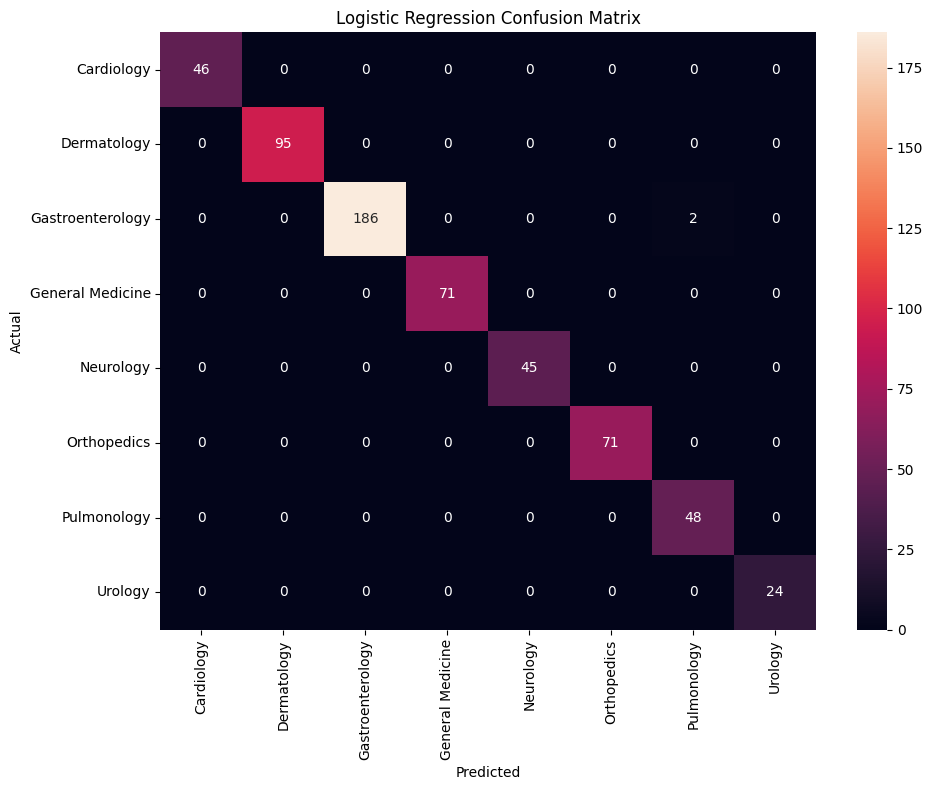


18. 5-FOLD CROSS-VALIDATION
         metric   mean    std
       accuracy 0.9976 0.0040
       macro_f1 0.9970 0.0051
macro_precision 0.9952 0.0083
   macro_recall 0.9991 0.0016

19. LOGISTIC REGRESSION COEFFICIENTS
                   fever   cough  breathlessness  chest_pain  headache  digestive_problem  joint_or_muscle_problem  skin_problem  urinary_problem  fatigue
Cardiology       -2.1149 -1.7648          3.0954      2.8247    1.9334            -1.2287                  -1.7217       -1.0597          -1.4877  -1.6486
Dermatology       0.1265 -0.0715         -0.0838     -0.2452   -1.2879            -2.5266                   0.5627        5.6741          -0.8884  -2.4319
Gastroenterology  0.2677  0.9322         -2.3214     -0.2253   -2.7444             5.1998                   0.9219        1.5064           0.4183   2.2305
General Medicine  4.1390 -0.4297         -1.9661      0.2130    1.7636            -2.1616                   0.4577       -0.6113          -0.5641   1.4632
Neurolog

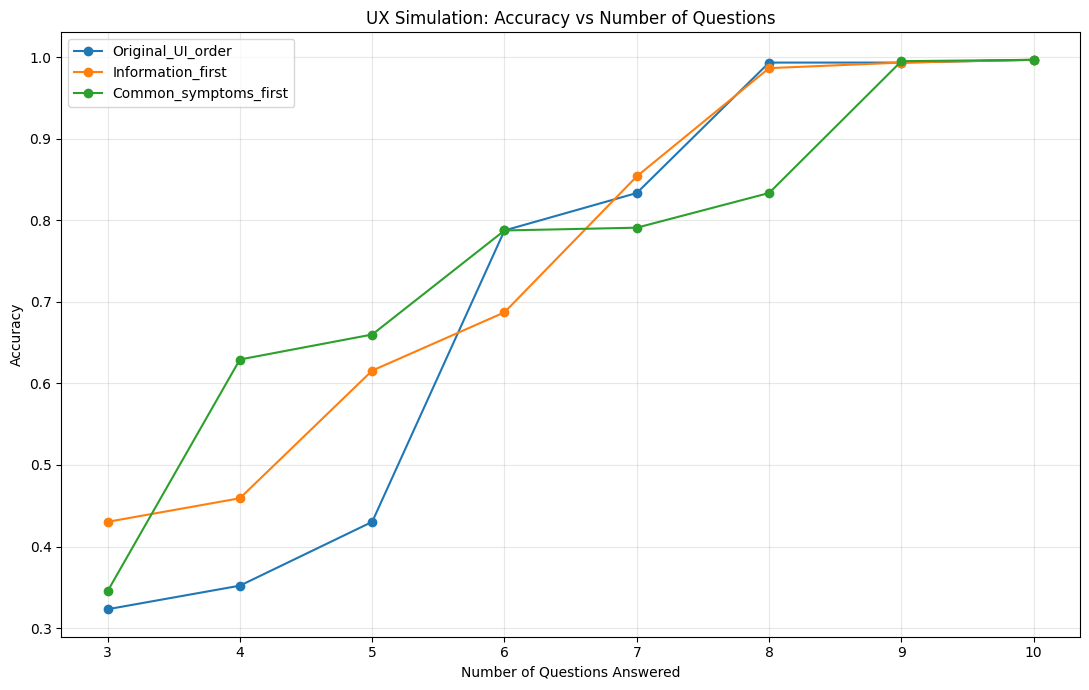

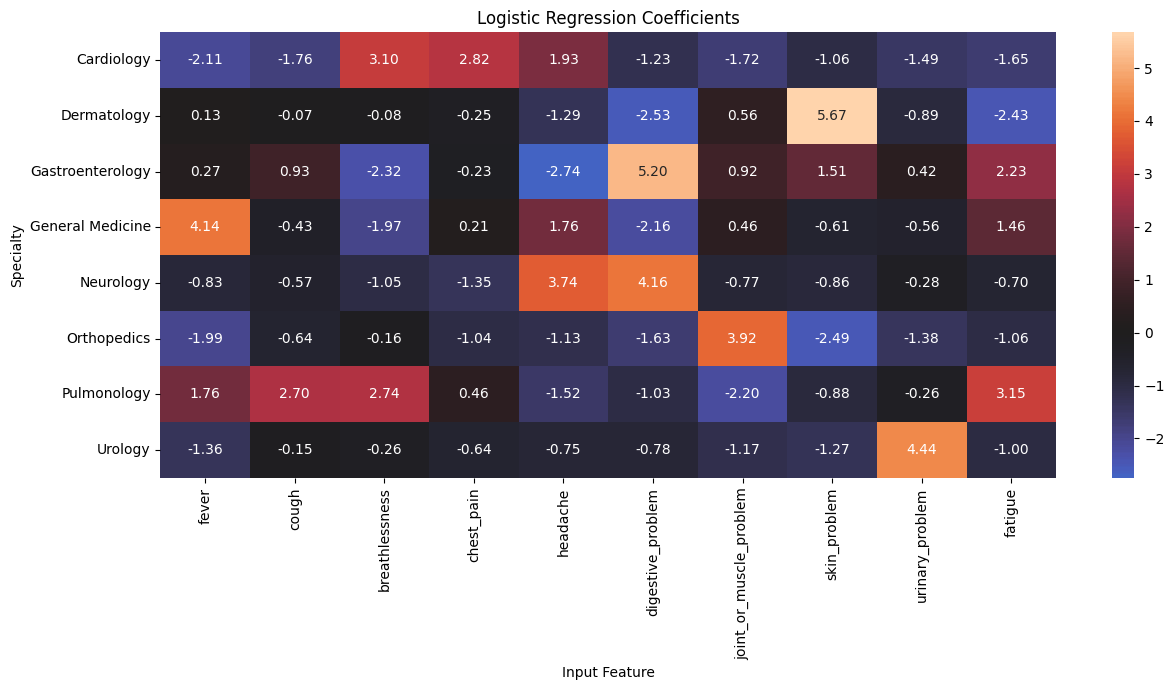




FINAL DATASET AUDIT COMPLETE

DATASET:
Rows: 2940
Unique feature patterns: 44
Exact duplicate rows: 2896
Exact duplicate percentage: 98.50%
Conflicting patterns: 0
All-zero rows: 0

SPECIALTY DISTRIBUTION:
                  rows  percentage
specialization                    
General Medicine   354       12.04
Cardiology         228        7.76
Pulmonology        240        8.16
Gastroenterology   942       32.04
Orthopedics        354       12.04
Neurology          228        7.76
Dermatology        474       16.12
Urology            120        4.08

UNIQUE PATTERNS PER SPECIALTY:
                  unique_patterns  rows  patterns_per_100_rows
specialization                                                
General Medicine                7   354                  1.977
Cardiology                      6   228                  2.632
Pulmonology                     9   240                  3.750
Gastroenterology               16   942                  1.699
Orthopedics                    

In [ ]:
# ============================================================
# SMART HEALTHCARE POC
# FINAL DATASET AUDIT + MODEL VALIDATION
#
# This code:
#   1. Audits the final dataset
#   2. Finds hidden structural problems
#   3. Evaluates class balance
#   4. Evaluates symptom-pattern diversity
#   5. Tests UX-relevant feature subsets
#   6. Trains Logistic Regression
#   7. Reports honest performance
#
# INPUT:
#   final_specialty_training_dataset.csv
#
# OPTIONAL:
#   final_dataset_audit.csv
#   custom_specialty_routing_audit.csv
#
# OUTPUT:
#   /content/dataset_audit_results.xlsx
#   /content/dataset_audit_report.txt
#   /content/model_audit_results.csv
# ============================================================


# ============================================================
# 0. INSTALL / IMPORT
# ============================================================

!pip -q install pandas numpy scikit-learn openpyxl matplotlib seaborn

import os
import itertools
import warnings
import json

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

from sklearn.dummy import DummyClassifier

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 240)

RANDOM_STATE = 42


# ============================================================
# 1. FIND DATASET
# ============================================================

possible_dataset_paths = [
    "/content/final_specialty_training_dataset.csv",
    "/content/custom_specialty_routing_dataset.csv",
    "/content/bce6dbd4-26cf-4205-8498-5809551d9888.csv",
    "/mnt/data/final_specialty_training_dataset.csv",
    "/mnt/data/bce6dbd4-26cf-4205-8498-5809551d9888.csv"
]

dataset_path = next(
    (
        p for p in possible_dataset_paths
        if os.path.exists(p)
    ),
    None
)


if dataset_path is None:

    print("Dataset not found automatically.")
    print("Please upload the final CSV.")

    from google.colab import files

    uploaded = files.upload()

    csv_names = [
        n for n in uploaded.keys()
        if n.lower().endswith(".csv")
    ]

    if not csv_names:
        raise FileNotFoundError(
            "No CSV uploaded."
        )

    dataset_path = (
        "/content/"
        + csv_names[0]
    )


print("Using dataset:")
print(dataset_path)


# ============================================================
# 2. LOAD
# ============================================================

df = pd.read_csv(
    dataset_path
)

print("\nDataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 3. FINAL SCHEMA
# ============================================================

FEATURES = [
    "fever",
    "cough",
    "breathlessness",
    "chest_pain",
    "headache",
    "digestive_problem",
    "joint_or_muscle_problem",
    "skin_problem",
    "urinary_problem",
    "fatigue"
]

TARGET = "specialization"

SPECIALTIES = [
    "General Medicine",
    "Cardiology",
    "Pulmonology",
    "Gastroenterology",
    "Orthopedics",
    "Neurology",
    "Dermatology",
    "Urology"
]


# ============================================================
# 4. SCHEMA VALIDATION
# ============================================================

expected_columns = FEATURES + [TARGET]

missing_columns = [
    c for c in expected_columns
    if c not in df.columns
]

extra_columns = [
    c for c in df.columns
    if c not in expected_columns
]


print("\n" + "=" * 110)
print("1. SCHEMA AUDIT")
print("=" * 110)

print("Missing expected columns:")
print(missing_columns)

print("\nExtra columns:")
print(extra_columns)


if missing_columns:
    raise ValueError(
        "Required columns are missing."
    )


# Work only on the ML columns
df = df[
    expected_columns
].copy()


# ============================================================
# 5. NULL / TYPE / BINARY CHECKS
# ============================================================

null_counts = (
    df.isna().sum()
)

binary_problems = []

for feature in FEATURES:

    values = sorted(
        df[feature].dropna().unique().tolist()
    )

    if not set(values).issubset({0, 1}):
        binary_problems.append({
            "feature": feature,
            "values": values
        })


print("\nNull values:")
print(
    null_counts.to_string()
)

print("\nBinary problems:")
print(binary_problems)


# ============================================================
# 6. TARGET CHECK
# ============================================================

unexpected_specialties = sorted(
    set(df[TARGET])
    - set(SPECIALTIES)
)

print("\nUnexpected specialties:")
print(
    unexpected_specialties
)


# ============================================================
# 7. BASIC DATASET STATISTICS
# ============================================================

print("\n" + "=" * 110)
print("2. BASIC DATASET STATISTICS")
print("=" * 110)

print(
    "Rows:",
    len(df)
)

print(
    "Features:",
    len(FEATURES)
)

print(
    "Specialties:",
    df[TARGET].nunique()
)


# ============================================================
# 8. CLASS DISTRIBUTION
# ============================================================

class_counts = (
    df[TARGET]
    .value_counts()
    .reindex(SPECIALTIES)
    .fillna(0)
    .astype(int)
)

class_percentages = (
    class_counts
    / len(df)
    * 100
)


class_distribution_df = pd.DataFrame({
    "rows": class_counts,
    "percentage": class_percentages.round(2)
})


print("\n" + "=" * 110)
print("3. CLASS DISTRIBUTION")
print("=" * 110)

print(
    class_distribution_df
    .to_string()
)


# Imbalance ratio
max_class = class_counts.max()
min_class = class_counts[
    class_counts > 0
].min()

imbalance_ratio = (
    max_class / min_class
)

print(
    "\nLargest/smallest class ratio:",
    round(imbalance_ratio, 3)
)


# ============================================================
# 9. EXACT DUPLICATES
# ============================================================

full_duplicate_count = int(
    df.duplicated().sum()
)

duplicate_percentage = (
    full_duplicate_count
    / len(df)
    * 100
)


print("\n" + "=" * 110)
print("4. DUPLICATE AUDIT")
print("=" * 110)

print(
    "Exact duplicate rows:",
    full_duplicate_count
)

print(
    "Duplicate percentage:",
    round(
        duplicate_percentage,
        2
    ),
    "%"
)


# ============================================================
# 10. UNIQUE FEATURE PATTERNS
# ============================================================

feature_patterns = (
    df[FEATURES]
    .drop_duplicates()
)

unique_pattern_count = (
    len(feature_patterns)
)

pattern_compression_ratio = (
    unique_pattern_count
    / len(df)
)


print("\n" + "=" * 110)
print("5. FEATURE-PATTERN DIVERSITY")
print("=" * 110)

print(
    "Total rows:",
    len(df)
)

print(
    "Unique 10-feature patterns:",
    unique_pattern_count
)

print(
    "Pattern diversity ratio:",
    round(
        pattern_compression_ratio,
        4
    )
)


# ============================================================
# 11. UNIQUE PATTERNS PER SPECIALTY
# ============================================================

patterns_per_specialty = (
    df.groupby(TARGET)[FEATURES]
    .apply(
        lambda x:
        len(
            x.drop_duplicates()
        )
    )
    .reindex(
        SPECIALTIES
    )
)


pattern_specialty_df = (
    patterns_per_specialty
    .rename(
        "unique_patterns"
    )
    .to_frame()
)

pattern_specialty_df[
    "rows"
] = class_counts

pattern_specialty_df[
    "patterns_per_100_rows"
] = (
    pattern_specialty_df[
        "unique_patterns"
    ]
    / pattern_specialty_df[
        "rows"
    ]
    * 100
)


print("\n" + "=" * 110)
print("6. UNIQUE PATTERNS PER SPECIALTY")
print("=" * 110)

print(
    pattern_specialty_df
    .round(3)
    .to_string()
)


# ============================================================
# 12. PATTERN → TARGET PURITY
# ============================================================

pattern_target_counts = (
    df[
        FEATURES + [TARGET]
    ]
    .groupby(FEATURES)[TARGET]
    .nunique()
)

conflicting_patterns = (
    pattern_target_counts[
        pattern_target_counts > 1
    ]
)


print("\n" + "=" * 110)
print("7. PATTERN / TARGET AMBIGUITY")
print("=" * 110)

print(
    "Conflicting feature patterns:",
    len(conflicting_patterns)
)


# ============================================================
# 13. ALL-ZERO PATTERNS
# ============================================================

zero_rows = (
    df[FEATURES]
    .sum(axis=1)
    == 0
)

print(
    "All-zero rows:",
    int(
        zero_rows.sum()
    )
)


# ============================================================
# 14. NUMBER OF POSITIVE SYMPTOMS PER ROW
# ============================================================

symptoms_per_row = (
    df[FEATURES]
    .sum(axis=1)
)

symptom_count_distribution = (
    symptoms_per_row
    .value_counts()
    .sort_index()
)


print("\n" + "=" * 110)
print("8. NUMBER OF POSITIVE FEATURES PER ROW")
print("=" * 110)

print(
    symptom_count_distribution
    .to_string()
)


# ============================================================
# 15. FEATURE PREVALENCE
# ============================================================

feature_prevalence = (
    df[FEATURES]
    .mean()
    .sort_values(
        ascending=False
    )
)

print("\n" + "=" * 110)
print("9. FEATURE PREVALENCE")
print("=" * 110)

for feature, rate in (
    feature_prevalence.items()
):

    print(
        f"{feature:35s}"
        f" {rate:.4f}"
        f" ({rate*100:.2f}%)"
    )


# ============================================================
# 16. FEATURE PRESENCE BY SPECIALTY
# ============================================================

feature_specialty_rates = (
    df[
        FEATURES + [TARGET]
    ]
    .groupby(TARGET)[FEATURES]
    .mean()
    .reindex(SPECIALTIES)
)


print("\n" + "=" * 110)
print("10. FEATURE PRESENCE BY SPECIALTY")
print("=" * 110)

print(
    feature_specialty_rates
    .round(3)
    .to_string()
)


# ============================================================
# 17. BEST SPECIALTY ASSOCIATED WITH EACH FEATURE
# ============================================================

feature_specialty_rows = []

for feature in FEATURES:

    rates = (
        feature_specialty_rates[
            feature
        ]
        .sort_values(
            ascending=False
        )
    )

    best_specialty = (
        rates.index[0]
    )

    feature_specialty_rows.append({
        "feature": feature,
        "best_specialty": best_specialty,
        "best_rate": rates.iloc[0],
        "second_specialty": rates.index[1],
        "second_rate": rates.iloc[1]
    })


feature_specialty_df = pd.DataFrame(
    feature_specialty_rows
)


print("\n" + "=" * 110)
print("11. FEATURE → SPECIALTY ASSOCIATION")
print("=" * 110)

print(
    feature_specialty_df
    .round(3)
    .to_string(index=False)
)


# ============================================================
# 18. FEATURE CORRELATION
# ============================================================

feature_corr = (
    df[FEATURES]
    .corr()
)


print("\n" + "=" * 110)
print("12. FEATURE CORRELATION")
print("=" * 110)

print(
    feature_corr
    .round(3)
    .to_string()
)


# Find highly correlated pairs
corr_pairs = []

for i in range(
    len(FEATURES)
):

    for j in range(
        i + 1,
        len(FEATURES)
    ):

        f1 = FEATURES[i]
        f2 = FEATURES[j]

        r = feature_corr.loc[
            f1,
            f2
        ]

        corr_pairs.append({
            "feature_1": f1,
            "feature_2": f2,
            "correlation": r,
            "absolute_correlation": abs(r)
        })


corr_pairs_df = (
    pd.DataFrame(
        corr_pairs
    )
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
)


print("\nHighly correlated pairs |r| >= 0.80:")

high_corr = (
    corr_pairs_df[
        corr_pairs_df[
            "absolute_correlation"
        ] >= 0.80
    ]
)

if len(high_corr) == 0:

    print(
        "None."
    )

else:

    print(
        high_corr
        .round(3)
        .to_string(index=False)
    )


# ============================================================
# 19. SPECIALTY SEPARABILITY
# ============================================================
#
# For each pair of specialties, calculate how different
# their feature profiles are.
#
# Large difference means that our ten features distinguish
# those specialties well.
# ============================================================

specialty_distance_rows = []

for a, b in itertools.combinations(
    SPECIALTIES,
    2
):

    if (
        a not in feature_specialty_rates.index
        or
        b not in feature_specialty_rates.index
    ):
        continue

    vector_a = (
        feature_specialty_rates
        .loc[a]
        .values
    )

    vector_b = (
        feature_specialty_rates
        .loc[b]
        .values
    )

    distance = np.linalg.norm(
        vector_a - vector_b
    )

    specialty_distance_rows.append({
        "specialty_a": a,
        "specialty_b": b,
        "feature_profile_distance": distance
    })


specialty_distance_df = (
    pd.DataFrame(
        specialty_distance_rows
    )
    .sort_values(
        "feature_profile_distance"
    )
)


print("\n" + "=" * 110)
print("13. CLOSEST SPECIALTY PAIRS")
print("=" * 110)

print(
    specialty_distance_df
    .head(10)
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 20. SINGLE-FEATURE RULE ANALYSIS
# ============================================================
#
# Question:
#
# If a user answers only ONE symptom,
# how predictable is the specialty?
#
# This is useful for UX planning.
# ============================================================

single_feature_rows = []


for feature in FEATURES:

    # yes cases
    yes_df = df[
        df[feature] == 1
    ]

    if len(yes_df) == 0:
        yes_accuracy = 0
        yes_majority = None
    else:

        yes_counts = (
            yes_df[TARGET]
            .value_counts()
        )

        yes_accuracy = (
            yes_counts.iloc[0]
            / yes_counts.sum()
        )

        yes_majority = (
            yes_counts.index[0]
        )

    # no cases
    no_df = df[
        df[feature] == 0
    ]

    if len(no_df) == 0:
        no_accuracy = 0
        no_majority = None
    else:

        no_counts = (
            no_df[TARGET]
            .value_counts()
        )

        no_accuracy = (
            no_counts.iloc[0]
            / no_counts.sum()
        )

        no_majority = (
            no_counts.index[0]
        )

    single_feature_rows.append({
        "feature": feature,
        "yes_rows": len(yes_df),
        "yes_majority_specialty": yes_majority,
        "yes_majority_purity": yes_accuracy,
        "no_rows": len(no_df),
        "no_majority_specialty": no_majority,
        "no_majority_purity": no_accuracy
    })


single_feature_df = pd.DataFrame(
    single_feature_rows
)


print("\n" + "=" * 110)
print("14. SINGLE-FEATURE PREDICTABILITY")
print("=" * 110)

print(
    single_feature_df
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 21. MAJORITY BASELINE
# ============================================================

X = df[FEATURES].astype(int)
y_text = df[TARGET].astype(str)


X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y_text,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_text
    )
)


dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(
    X_train,
    y_train
)

dummy_pred = (
    dummy_model.predict(
        X_test
    )
)


dummy_accuracy = accuracy_score(
    y_test,
    dummy_pred
)

dummy_f1 = f1_score(
    y_test,
    dummy_pred,
    average="macro"
)


print("\n" + "=" * 110)
print("15. MAJORITY CLASS BASELINE")
print("=" * 110)

print(
    f"Accuracy : {dummy_accuracy:.4f}"
)

print(
    f"Macro F1 : {dummy_f1:.4f}"
)


# ============================================================
# 22. LOGISTIC REGRESSION HOLDOUT
# ============================================================

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    y_text
)


X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )
)


model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=RANDOM_STATE
)

model.fit(
    X_train,
    y_train
)


pred = model.predict(
    X_test
)

proba = model.predict_proba(
    X_test
)


holdout_accuracy = accuracy_score(
    y_test,
    pred
)

holdout_macro_precision = precision_score(
    y_test,
    pred,
    average="macro",
    zero_division=0
)

holdout_macro_recall = recall_score(
    y_test,
    pred,
    average="macro",
    zero_division=0
)

holdout_macro_f1 = f1_score(
    y_test,
    pred,
    average="macro"
)

holdout_weighted_f1 = f1_score(
    y_test,
    pred,
    average="weighted"
)


# ============================================================
# 23. TOP-K
# ============================================================

def top_k_accuracy(
    y_true,
    probabilities,
    classes,
    k
):

    correct = 0

    for true_value, probabilities_row in zip(
        y_true,
        probabilities
    ):

        ranked_indices = (
            np.argsort(
                probabilities_row
            )[::-1]
        )

        top_indices = ranked_indices[
            :k
        ]

        if true_value in classes[
            top_indices
        ]:

            correct += 1

    return (
        correct / len(y_true)
    )


holdout_top2 = top_k_accuracy(
    y_test,
    proba,
    model.classes_,
    2
)

holdout_top3 = top_k_accuracy(
    y_test,
    proba,
    model.classes_,
    3
)


print("\n" + "=" * 110)
print("16. LOGISTIC REGRESSION HOLDOUT")
print("=" * 110)

print(
    f"Accuracy          : {holdout_accuracy:.4f}"
)

print(
    f"Macro Precision   : {holdout_macro_precision:.4f}"
)

print(
    f"Macro Recall      : {holdout_macro_recall:.4f}"
)

print(
    f"Macro F1          : {holdout_macro_f1:.4f}"
)

print(
    f"Weighted F1       : {holdout_weighted_f1:.4f}"
)

print(
    f"Top-2 Accuracy    : {holdout_top2:.4f}"
)

print(
    f"Top-3 Accuracy    : {holdout_top3:.4f}"
)


# ============================================================
# 24. CLASSIFICATION REPORT
# ============================================================

classification_report_df = pd.DataFrame(
    classification_report(
        y_test,
        pred,
        labels=np.arange(
            len(label_encoder.classes_)
        ),
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0
    )
).transpose()


print("\n" + "=" * 110)
print("17. CLASSIFICATION REPORT")
print("=" * 110)

print(
    classification_report_df
    .round(4)
    .to_string()
)


# ============================================================
# 25. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    pred,
    labels=np.arange(
        len(label_encoder.classes_)
    )
)


plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.tight_layout()

confusion_matrix_path = (
    "/content/"
    "dataset_audit_confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 26. 5-FOLD CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


cv_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=RANDOM_STATE
)


cv_results = cross_validate(
    cv_model,
    X,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "f1_macro",
        "precision_macro",
        "recall_macro"
    ],
    n_jobs=-1
)


cv_summary_df = pd.DataFrame({
    "metric": [
        "accuracy",
        "macro_f1",
        "macro_precision",
        "macro_recall"
    ],
    "mean": [
        cv_results[
            "test_accuracy"
        ].mean(),

        cv_results[
            "test_f1_macro"
        ].mean(),

        cv_results[
            "test_precision_macro"
        ].mean(),

        cv_results[
            "test_recall_macro"
        ].mean()
    ],
    "std": [
        cv_results[
            "test_accuracy"
        ].std(),

        cv_results[
            "test_f1_macro"
        ].std(),

        cv_results[
            "test_precision_macro"
        ].std(),

        cv_results[
            "test_recall_macro"
        ].std()
    ]
})


print("\n" + "=" * 110)
print("18. 5-FOLD CROSS-VALIDATION")
print("=" * 110)

print(
    cv_summary_df
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 27. LOGISTIC REGRESSION COEFFICIENTS
# ============================================================

coefficient_df = pd.DataFrame(
    model.coef_,
    index=label_encoder.classes_,
    columns=FEATURES
)


print("\n" + "=" * 110)
print("19. LOGISTIC REGRESSION COEFFICIENTS")
print("=" * 110)

print(
    coefficient_df
    .round(4)
    .to_string()
)


# ============================================================
# 28. FEATURE IMPORTANCE FROM COEFFICIENT MAGNITUDE
# ============================================================

coefficient_strength = (
    np.abs(
        coefficient_df
    )
    .mean(axis=0)
    .sort_values(
        ascending=False
    )
)


print("\n" + "=" * 110)
print("20. MODEL FEATURE IMPORTANCE")
print("=" * 110)

for feature, value in (
    coefficient_strength.items()
):

    print(
        f"{feature:35s}"
        f" {value:.5f}"
    )


# ============================================================
# 29. UX EXPERIMENT:
# BEST 3 / 4 / 5 / 6 FEATURES
#
# IMPORTANT:
#
# We evaluate EVERY combination using a FAST validation:
#
# - one fixed stratified train/test split
# - majority-class mapping within training
#
# This is a SCREENING experiment, not final model selection.
#
# It tells us which questions are most informative if we
# force the user to answer only 3, 4, or 5 feature questions.
# ============================================================

def evaluate_feature_subset(
    selected_features
):

    X_sub = df[
        selected_features
    ].astype(int)

    # Fixed split
    tr_idx, te_idx = train_test_split(
        np.arange(len(df)),
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_text
    )

    Xtr = X_sub.iloc[
        tr_idx
    ]

    Xte = X_sub.iloc[
        te_idx
    ]

    ytr = y[tr_idx]
    yte = y[te_idx]

    m = LogisticRegression(
        max_iter=1500,
        class_weight="balanced",
        solver="lbfgs",
        random_state=RANDOM_STATE
    )

    m.fit(
        Xtr,
        ytr
    )

    p = m.predict(
        Xte
    )

    prob = m.predict_proba(
        Xte
    )

    return {
        "accuracy": accuracy_score(
            yte,
            p
        ),
        "macro_f1": f1_score(
            yte,
            p,
            average="macro"
        ),
        "top2": top_k_accuracy(
            yte,
            prob,
            m.classes_,
            2
        ),
        "top3": top_k_accuracy(
            yte,
            prob,
            m.classes_,
            3
        )
    }


subset_results = []


for k in [3, 4, 5, 6]:

    print(
        f"\nTesting all {k}-feature combinations..."
    )

    combinations_list = list(
        itertools.combinations(
            FEATURES,
            k
        )
    )

    for selected in combinations_list:

        scores = evaluate_feature_subset(
            list(selected)
        )

        subset_results.append({
            "k": k,
            "features": " | ".join(
                selected
            ),
            "accuracy": scores[
                "accuracy"
            ],
            "macro_f1": scores[
                "macro_f1"
            ],
            "top2": scores[
                "top2"
            ],
            "top3": scores[
                "top3"
            ]
        })


subset_results_df = pd.DataFrame(
    subset_results
)


# ============================================================
# 30. BEST FEATURE SUBSETS
# ============================================================

print("\n" + "=" * 110)
print("21. BEST 3 / 4 / 5 / 6 FEATURE COMBINATIONS")
print("=" * 110)


for k in [3, 4, 5, 6]:

    best_k = (
        subset_results_df[
            subset_results_df["k"] == k
        ]
        .sort_values(
            [
                "macro_f1",
                "accuracy"
            ],
            ascending=False
        )
        .head(10)
    )

    print(
        f"\nTOP {k}-FEATURE COMBINATIONS:"
    )

    print(
        best_k
        .round(4)
        .to_string(index=False)
    )


# ============================================================
# 31. FEATURE APPEARANCE IN TOP COMBINATIONS
# ============================================================

feature_appearance_rows = []


for k in [3, 4, 5]:

    top_k = (
        subset_results_df[
            subset_results_df["k"] == k
        ]
        .sort_values(
            [
                "macro_f1",
                "accuracy"
            ],
            ascending=False
        )
        .head(20)
    )

    for feature in FEATURES:

        occurrence = (
            top_k["features"]
            .str.contains(
                feature,
                regex=False
            )
            .sum()
        )

        feature_appearance_rows.append({
            "k": k,
            "feature": feature,
            "top20_appearance_count": occurrence
        })


feature_appearance_df = pd.DataFrame(
    feature_appearance_rows
)


print("\n" + "=" * 110)
print("22. FEATURE APPEARANCE IN TOP-20 COMBINATIONS")
print("=" * 110)

for k in [3, 4, 5]:

    print(
        f"\n{k}-feature combinations:"
    )

    print(
        feature_appearance_df[
            feature_appearance_df["k"] == k
        ]
        .sort_values(
            "top20_appearance_count",
            ascending=False
        )
        .to_string(index=False)
    )


# ============================================================
# 32. PROGRESSIVE QUESTION ORDER EXPERIMENT
#
# We test a few candidate question orders.
#
# At each stage:
#
#   answered features = actual values
#   unasked features = 0
#
# This simulates your current POC rule:
#
#   skipped/unasked -> 0
#
# NOTE:
# This experiment is intentionally exposing the weakness of
# the "skip = no" design. If accuracy falls substantially,
# we should change the UX even if the rest of the model is good.
# ============================================================


question_orders = {

    "Original_UI_order": [
        "fever",
        "cough",
        "breathlessness",
        "chest_pain",
        "headache",
        "digestive_problem",
        "joint_or_muscle_problem",
        "skin_problem",
        "urinary_problem",
        "fatigue"
    ],

    "Information_first": [
        "skin_problem",
        "urinary_problem",
        "breathlessness",
        "chest_pain",
        "headache",
        "joint_or_muscle_problem",
        "fever",
        "digestive_problem",
        "cough",
        "fatigue"
    ],

    "Common_symptoms_first": [
        "fever",
        "cough",
        "headache",
        "fatigue",
        "digestive_problem",
        "breathlessness",
        "chest_pain",
        "joint_or_muscle_problem",
        "skin_problem",
        "urinary_problem"
    ]
}


progressive_rows = []


# one fixed split
train_idx, test_idx = train_test_split(
    np.arange(len(df)),
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_text
)

for order_name, order in question_orders.items():

    for n_questions in [3, 4, 5, 6, 7, 8, 9, 10]:

        selected = order[
            :n_questions
        ]

        unselected = [
            f for f in FEATURES
            if f not in selected
        ]

        X_train_full = (
            df[
                FEATURES
            ]
            .astype(int)
            .copy()
        )

        X_test_full = (
            df[
                FEATURES
            ]
            .astype(int)
            .copy()
        )


        # Simulate your UI:
        # unasked features become 0
        X_train_sim = (
            X_train_full.iloc[
                train_idx
            ]
            .copy()
        )

        X_test_sim = (
            X_test_full.iloc[
                test_idx
            ]
            .copy()
        )


        for feature in unselected:

            X_train_sim[
                feature
            ] = 0

            X_test_sim[
                feature
            ] = 0


        X_train_sim = (
            X_train_sim[
                FEATURES
            ]
        )

        X_test_sim = (
            X_test_sim[
                FEATURES
            ]
        )


        m = LogisticRegression(
            max_iter=1500,
            class_weight="balanced",
            solver="lbfgs",
            random_state=RANDOM_STATE
        )

        m.fit(
            X_train_sim,
            y[train_idx]
        )

        pred_sim = m.predict(
            X_test_sim
        )

        sim_accuracy = accuracy_score(
            y[test_idx],
            pred_sim
        )

        sim_f1 = f1_score(
            y[test_idx],
            pred_sim,
            average="macro"
        )


        progressive_rows.append({
            "question_order": order_name,
            "questions_answered": n_questions,
            "features_used": " | ".join(
                selected
            ),
            "accuracy": sim_accuracy,
            "macro_f1": sim_f1
        })


progressive_df = pd.DataFrame(
    progressive_rows
)


# ============================================================
# 33. PRINT PROGRESSIVE UX RESULTS
# ============================================================

print("\n" + "=" * 110)
print("23. PROGRESSIVE QUESTION / UX SIMULATION")
print("=" * 110)


for order_name in question_orders.keys():

    print(
        f"\nORDER: {order_name}"
    )

    print(
        progressive_df[
            progressive_df[
                "question_order"
            ] == order_name
        ]
        [
            [
                "questions_answered",
                "accuracy",
                "macro_f1",
                "features_used"
            ]
        ]
        .round(4)
        .to_string(index=False)
    )


# ============================================================
# 34. PLOT PROGRESSIVE PERFORMANCE
# ============================================================

plt.figure(
    figsize=(11, 7)
)

for order_name in question_orders.keys():

    subset = progressive_df[
        progressive_df[
            "question_order"
        ] == order_name
    ]

    plt.plot(
        subset[
            "questions_answered"
        ],
        subset[
            "accuracy"
        ],
        marker="o",
        label=order_name
    )

plt.xlabel(
    "Number of Questions Answered"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "UX Simulation: Accuracy vs Number of Questions"
)

plt.xticks(
    range(3, 11)
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

progressive_plot_path = (
    "/content/"
    "progressive_question_accuracy.png"
)

plt.savefig(
    progressive_plot_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 35. COEFFICIENT HEATMAP
# ============================================================

plt.figure(
    figsize=(13, 7)
)

sns.heatmap(
    coefficient_df,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title(
    "Logistic Regression Coefficients"
)

plt.xlabel(
    "Input Feature"
)

plt.ylabel(
    "Specialty"
)

plt.tight_layout()

coefficient_heatmap_path = (
    "/content/"
    "final_dataset_coefficient_heatmap.png"
)

plt.savefig(
    coefficient_heatmap_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 36. SAVE ALL CSV RESULTS
# ============================================================

output_files = []


def save_csv(dataframe, filename):

    path = (
        "/content/"
        + filename
    )

    dataframe.to_csv(
        path,
        index=False
    )

    output_files.append(
        path
    )

    return path


save_csv(
    class_distribution_df.reset_index(),
    "audit_class_distribution.csv"
)

save_csv(
    pattern_specialty_df.reset_index(),
    "audit_pattern_specialty.csv"
)

save_csv(
    feature_specialty_df,
    "audit_feature_specialty.csv"
)

save_csv(
    corr_pairs_df,
    "audit_feature_correlations.csv"
)

save_csv(
    specialty_distance_df,
    "audit_specialty_distances.csv"
)

save_csv(
    single_feature_df,
    "audit_single_feature_predictability.csv"
)

save_csv(
    classification_report_df.reset_index(),
    "audit_classification_report.csv"
)

save_csv(
    cv_summary_df,
    "audit_cross_validation.csv"
)

save_csv(
    coefficient_df.reset_index(),
    "audit_coefficients.csv"
)

save_csv(
    subset_results_df,
    "audit_feature_subsets.csv"
)

save_csv(
    feature_appearance_df,
    "audit_feature_appearance.csv"
)

save_csv(
    progressive_df,
    "audit_progressive_questions.csv"
)

save_csv(
    feature_usage_df,
    "audit_feature_usage.csv"
)


# ============================================================
# 37. CREATE EXCEL WORKBOOK
# ============================================================

excel_path = (
    "/content/"
    "dataset_audit_results.xlsx"
)


with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    class_distribution_df.to_excel(
        writer,
        sheet_name="Class_Distribution"
    )

    pattern_specialty_df.to_excel(
        writer,
        sheet_name="Patterns_By_Specialty"
    )

    feature_specialty_df.to_excel(
        writer,
        sheet_name="Feature_Specialty",
        index=False
    )

    feature_specialty_rates.to_excel(
        writer,
        sheet_name="Feature_Rates"
    )

    corr_pairs_df.to_excel(
        writer,
        sheet_name="Correlations",
        index=False
    )

    specialty_distance_df.to_excel(
        writer,
        sheet_name="Specialty_Distance",
        index=False
    )

    single_feature_df.to_excel(
        writer,
        sheet_name="Single_Feature",
        index=False
    )

    classification_report_df.to_excel(
        writer,
        sheet_name="Classification_Report"
    )

    cv_summary_df.to_excel(
        writer,
        sheet_name="Cross_Validation",
        index=False
    )

    coefficient_df.to_excel(
        writer,
        sheet_name="Coefficients"
    )

    subset_results_df.to_excel(
        writer,
        sheet_name="Feature_Subsets",
        index=False
    )

    progressive_df.to_excel(
        writer,
        sheet_name="Progressive_UX",
        index=False
    )

    feature_usage_df.to_excel(
        writer,
        sheet_name="Feature_Usage",
        index=False
    )


# ============================================================
# 38. CREATE MODEL RESULTS CSV
# ============================================================

model_summary_df = pd.DataFrame({
    "metric": [
        "holdout_accuracy",
        "holdout_macro_precision",
        "holdout_macro_recall",
        "holdout_macro_f1",
        "holdout_weighted_f1",
        "holdout_top2",
        "holdout_top3",
        "cv_accuracy_mean",
        "cv_accuracy_std",
        "cv_macro_f1_mean",
        "cv_macro_f1_std",
        "majority_baseline_accuracy",
        "majority_baseline_macro_f1"
    ],
    "value": [
        holdout_accuracy,
        holdout_macro_precision,
        holdout_macro_recall,
        holdout_macro_f1,
        holdout_weighted_f1,
        holdout_top2,
        holdout_top3,
        cv_summary_df.loc[
            cv_summary_df[
                "metric"
            ] == "accuracy",
            "mean"
        ].iloc[0],
        cv_summary_df.loc[
            cv_summary_df[
                "metric"
            ] == "accuracy",
            "std"
        ].iloc[0],
        cv_summary_df.loc[
            cv_summary_df[
                "metric"
            ] == "macro_f1",
            "mean"
        ].iloc[0],
        cv_summary_df.loc[
            cv_summary_df[
                "metric"
            ] == "macro_f1",
            "std"
        ].iloc[0],
        dummy_accuracy,
        dummy_f1
    ]
})


model_results_path = (
    "/content/"
    "model_audit_results.csv"
)

model_summary_df.to_csv(
    model_results_path,
    index=False
)

output_files.append(
    model_results_path
)


# ============================================================
# 39. GENERATE TEXT REPORT
# ============================================================

report_lines = []

report_lines.append(
    "SMART HEALTHCARE POC"
)

report_lines.append(
    "FINAL DATASET AUDIT + MODEL VALIDATION REPORT"
)

report_lines.append(
    "=" * 90
)

report_lines.append("")

report_lines.append(
    "DATASET"
)

report_lines.append(
    f"Rows: {len(df)}"
)

report_lines.append(
    f"Features: {len(FEATURES)}"
)

report_lines.append(
    f"Specialties: {len(SPECIALTIES)}"
)

report_lines.append(
    ""
)


report_lines.append(
    "FINAL FEATURES:"
)

for f in FEATURES:

    report_lines.append(
        f"- {f}"
    )


report_lines.append(
    ""
)

report_lines.append(
    "SPECIALTIES:"
)

for s in SPECIALTIES:

    report_lines.append(
        f"- {s}"
    )


report_lines.append(
    ""
)

report_lines.append(
    "CLASS DISTRIBUTION:"
)

report_lines.append(
    class_distribution_df
    .to_string()
)


report_lines.append(
    ""
)

report_lines.append(
    "DUPLICATE ANALYSIS:"
)

report_lines.append(
    f"Exact duplicate rows: {full_duplicate_count}"
)

report_lines.append(
    f"Duplicate percentage: {duplicate_percentage:.2f}%"
)

report_lines.append(
    f"Unique feature patterns: {unique_pattern_count}"
)


report_lines.append(
    ""
)

report_lines.append(
    "PATTERNS PER SPECIALTY:"
)

report_lines.append(
    pattern_specialty_df
    .to_string()
)


report_lines.append(
    ""
)

report_lines.append(
    f"Conflicting feature patterns: "
    f"{len(conflicting_patterns)}"
)


report_lines.append(
    f"All-zero rows: "
    f"{int(zero_rows.sum())}"
)


report_lines.append(
    ""
)

report_lines.append(
    "SINGLE FEATURE PREDICTABILITY:"
)

report_lines.append(
    single_feature_df
    .round(4)
    .to_string(index=False)
)


report_lines.append(
    ""
)

report_lines.append(
    "MODEL HOLDOUT RESULTS:"
)

report_lines.append(
    model_summary_df
    .round(4)
    .to_string(index=False)
)


report_lines.append(
    ""
)

report_lines.append(
    "5-FOLD CROSS VALIDATION:"
)

report_lines.append(
    cv_summary_df
    .round(4)
    .to_string(index=False)
)


report_lines.append(
    ""
)

report_lines.append(
    "BEST FEATURE COMBINATIONS:"
)

for k in [3, 4, 5, 6]:

    best = (
        subset_results_df[
            subset_results_df["k"] == k
        ]
        .sort_values(
            [
                "macro_f1",
                "accuracy"
            ],
            ascending=False
        )
        .head(5)
    )

    report_lines.append(
        f"\nTop {k}-feature combinations:"
    )

    report_lines.append(
        best
        .round(4)
        .to_string(index=False)
    )


report_lines.append(
    ""
)

report_lines.append(
    "PROGRESSIVE UX SIMULATION:"
)

for order_name in question_orders.keys():

    subset = progressive_df[
        progressive_df[
            "question_order"
        ] == order_name
    ]

    report_lines.append(
        f"\n{order_name}:"
    )

    report_lines.append(
        subset
        .round(4)
        .to_string(index=False)
    )


report_lines.append(
    ""
)

report_lines.append(
    "IMPORTANT INTERPRETATION:"
)

report_lines.append(
    "Random train/test and ordinary cross-validation can "
    "overestimate generalization when many rows have identical "
    "feature patterns. This dataset contains substantial "
    "pattern duplication, so performance should be interpreted "
    "as a proof-of-concept benchmark rather than clinical accuracy."
)


report_path = (
    "/content/"
    "dataset_audit_report.txt"
)

with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "\n".join(
            report_lines
        )
    )


# ============================================================
# 40. FINAL CONSOLE SUMMARY
# ============================================================

print("\n\n")
print("=" * 130)
print("FINAL DATASET AUDIT COMPLETE")
print("=" * 130)

print("\nDATASET:")
print(
    "Rows:",
    len(df)
)

print(
    "Unique feature patterns:",
    unique_pattern_count
)

print(
    "Exact duplicate rows:",
    full_duplicate_count
)

print(
    "Exact duplicate percentage:",
    f"{duplicate_percentage:.2f}%"
)

print(
    "Conflicting patterns:",
    len(conflicting_patterns)
)

print(
    "All-zero rows:",
    int(zero_rows.sum())
)


print("\nSPECIALTY DISTRIBUTION:")
print(
    class_distribution_df.to_string()
)


print("\nUNIQUE PATTERNS PER SPECIALTY:")
print(
    pattern_specialty_df.round(3).to_string()
)


print("\nHOLDOUT MODEL:")
print(
    model_summary_df
    .round(4)
    .to_string(index=False)
)


print("\nCROSS VALIDATION:")
print(
    cv_summary_df
    .round(4)
    .to_string(index=False)
)


print("\nBEST 3-FEATURE COMBINATION:")
print(
    subset_results_df[
        subset_results_df["k"] == 3
    ]
    .sort_values(
        ["macro_f1", "accuracy"],
        ascending=False
    )
    .head(1)
    .to_string(index=False)
)


print("\nBEST 4-FEATURE COMBINATION:")
print(
    subset_results_df[
        subset_results_df["k"] == 4
    ]
    .sort_values(
        ["macro_f1", "accuracy"],
        ascending=False
    )
    .head(1)
    .to_string(index=False)
)


print("\nBEST 5-FEATURE COMBINATION:")
print(
    subset_results_df[
        subset_results_df["k"] == 5
    ]
    .sort_values(
        ["macro_f1", "accuracy"],
        ascending=False
    )
    .head(1)
    .to_string(index=False)
)


print("\nOUTPUT FILES:")
print(
    "1.",
    excel_path
)

print(
    "2.",
    report_path
)

print(
    "3.",
    model_results_path
)

print(
    "4.",
    confusion_matrix_path
)

print(
    "5.",
    coefficient_heatmap_path
)

print(
    "6.",
    progressive_plot_path
)

print(
    "\nDONE."
)

print(
    "\nPaste the FINAL CONSOLE SUMMARY back to ChatGPT."
)

print(
    "Also upload dataset_audit_results.xlsx if you want "
    "the complete detailed tables inspected."
)

In [18]:
# ============================================================
# SMART HEALTHCARE POC
# FINAL DATASET CONSTRUCTION
# ============================================================
#
# FINAL INPUT FEATURES:
#
# 1. fever
# 2. cough
# 3. breathlessness
# 4. chest_pain
# 5. headache
# 6. digestive_problem
# 7. joint_or_muscle_problem
# 8. skin_problem
# 9. urinary_problem
# 10. fatigue
#
# TARGET:
#   specialization
#
# SPECIALTIES:
#   General Medicine
#   Cardiology
#   Pulmonology
#   Gastroenterology
#   Orthopedics
#   Neurology
#   Dermatology
#   Urology
#
#
# SOURCE:
#   Symptom.csv
#   Disease Specialist.csv
#
#
# IMPORTANT METHODOLOGY
# ---------------------
# 1. Source-derived rows are created first.
# 2. Source rows are split BEFORE augmentation.
# 3. Validation and test remain untouched.
# 4. ONLY the training split is balanced.
# 5. Underrepresented specialties are augmented by:
#       - sampling original training rows
#       - simulating incomplete patient answers by
#         turning selected positive features into 0
# 6. All-zero rows are rejected.
# 7. Exact known cross-specialty conflicts are rejected.
# 8. We do not invent new target labels.
#
# This gives us a balanced POC training dataset while keeping
# validation/test honest.
#
# OUTPUT:
#
#   final_balanced_training_dataset.csv
#   final_validation_dataset.csv
#   final_test_dataset.csv
#   final_dataset_audit.csv
#   final_dataset_report.txt
#   final_dataset_package.zip
#
# ============================================================


# ============================================================
# 0. INSTALL / IMPORT
# ============================================================

!pip -q install pandas numpy scikit-learn openpyxl

import os
import re
import json
import zipfile
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split


RANDOM_STATE = 42

rng = np.random.default_rng(
    RANDOM_STATE
)


pd.set_option(
    "display.max_columns",
    100
)

pd.set_option(
    "display.max_rows",
    200
)

pd.set_option(
    "display.width",
    220
)


# ============================================================
# 1. FILE DISCOVERY
# ============================================================

possible_symptom_paths = [
    "/content/Symptom.csv",
    "/content/symptom.csv",
    "/mnt/data/Symptom.csv",
    "/mnt/data/symptom.csv"
]

possible_specialist_paths = [
    "/content/Disease Specialist.csv",
    "/content/Disease_Specialist.csv",
    "/content/disease specialist.csv",
    "/mnt/data/Disease Specialist.csv",
    "/mnt/data/Disease_Specialist.csv"
]


symptom_path = next(
    (
        p
        for p in possible_symptom_paths
        if os.path.exists(p)
    ),
    None
)

specialist_path = next(
    (
        p
        for p in possible_specialist_paths
        if os.path.exists(p)
    ),
    None
)


if symptom_path is None or specialist_path is None:

    print(
        "Source files were not found automatically."
    )

    print(
        "Please upload BOTH:"
    )

    print(
        "1. Symptom.csv"
    )

    print(
        "2. Disease Specialist.csv"
    )

    from google.colab import files

    uploaded = files.upload()

    for filename in uploaded.keys():

        normalized = (
            filename
            .lower()
            .replace("_", " ")
            .strip()
        )

        if (
            "symptom" in normalized
            and "specialist" not in normalized
        ):

            symptom_path = (
                "/content/"
                + filename
            )

        elif "specialist" in normalized:

            specialist_path = (
                "/content/"
                + filename
            )


if symptom_path is None:
    raise FileNotFoundError(
        "Symptom.csv not found."
    )

if specialist_path is None:
    raise FileNotFoundError(
        "Disease Specialist.csv not found."
    )


print("\nUsing:")
print(
    "Symptom dataset   :",
    symptom_path
)

print(
    "Specialist dataset:",
    specialist_path
)


# ============================================================
# 2. READ SOURCE FILES
# ============================================================

symptom_df = pd.read_csv(
    symptom_path
)

specialist_df = pd.read_csv(
    specialist_path
)


print("\n" + "=" * 110)
print("SOURCE DATASET SHAPES")
print("=" * 110)

print(
    "Symptom.csv:",
    symptom_df.shape
)

print(
    "Disease Specialist.csv:",
    specialist_df.shape
)


# ============================================================
# 3. NORMALIZE COLUMN NAMES
# ============================================================

def clean_column_name(x):

    x = str(x).strip().lower()

    x = x.replace(
        " ",
        "_"
    )

    x = x.replace(
        "-",
        "_"
    )

    return x


symptom_df.columns = [
    clean_column_name(c)
    for c in symptom_df.columns
]

specialist_df.columns = [
    clean_column_name(c)
    for c in specialist_df.columns
]


# ============================================================
# 4. FIND IMPORTANT COLUMNS
# ============================================================

symptom_disease_candidates = [
    c
    for c in symptom_df.columns
    if c in [
        "disease",
        "diagnosis",
        "condition"
    ]
]

specialist_disease_candidates = [
    c
    for c in specialist_df.columns
    if c in [
        "disease",
        "diagnosis",
        "condition"
    ]
]

specialist_candidates = [
    c
    for c in specialist_df.columns
    if (
        "special" in c
        or "doctor" in c
    )
]


if not symptom_disease_candidates:

    raise ValueError(
        "Could not find disease column in Symptom.csv."
    )

if not specialist_disease_candidates:

    raise ValueError(
        "Could not find disease column in "
        "Disease Specialist.csv."
    )

if not specialist_candidates:

    raise ValueError(
        "Could not find specialist column."
    )


disease_col_symptom = (
    symptom_disease_candidates[0]
)

disease_col_specialist = (
    specialist_disease_candidates[0]
)

specialist_col = (
    specialist_candidates[0]
)


# ============================================================
# 5. TEXT NORMALIZATION
# ============================================================

def normalize_text(x):

    if pd.isna(x):
        return ""

    x = str(x).strip().lower()

    x = re.sub(
        r"\s+",
        " ",
        x
    )

    return x


symptom_df["_disease_key"] = (
    symptom_df[
        disease_col_symptom
    ]
    .apply(normalize_text)
)

specialist_df["_disease_key"] = (
    specialist_df[
        disease_col_specialist
    ]
    .apply(normalize_text)
)

specialist_df["_specialist_clean"] = (
    specialist_df[
        specialist_col
    ]
    .astype(str)
    .str.strip()
)


# ============================================================
# 6. FINAL SPECIALTY MAPPING
# ============================================================

SPECIALIST_MAP = {

    "primary care provider":
        "General Medicine",

    "general practitioner":
        "General Medicine",

    "general physician":
        "General Medicine",

    "general medicine":
        "General Medicine",

    "cardiologist":
        "Cardiology",

    "cardiology":
        "Cardiology",

    "pulmonologist":
        "Pulmonology",

    "pulmonology":
        "Pulmonology",

    "gastroenterologist":
        "Gastroenterology",

    "gastroenterology":
        "Gastroenterology",

    "hepatologist":
        "Gastroenterology",

    "hepatology":
        "Gastroenterology",

    "proctologist":
        "Gastroenterology",

    "orthopedic":
        "Orthopedics",

    "orthopaedic":
        "Orthopedics",

    "orthopedics":
        "Orthopedics",

    "orthopaedics":
        "Orthopedics",

    "neurologist":
        "Neurology",

    "neurology":
        "Neurology",

    "neurosurgeon":
        "Neurology",

    "dermatologist":
        "Dermatology",

    "dermatology":
        "Dermatology",

    "urologist":
        "Urology",

    "urology":
        "Urology"
}


TARGET_SPECIALTIES = [
    "General Medicine",
    "Cardiology",
    "Pulmonology",
    "Gastroenterology",
    "Orthopedics",
    "Neurology",
    "Dermatology",
    "Urology"
]


specialist_df["_specialty"] = (
    specialist_df[
        "_specialist_clean"
    ]
    .apply(normalize_text)
    .map(
        SPECIALIST_MAP
    )
)


# ============================================================
# 7. JOIN DISEASE -> SPECIALTY
# ============================================================

disease_specialty_map = (
    specialist_df[
        [
            "_disease_key",
            "_specialty"
        ]
    ]
    .drop_duplicates()
)


merged_df = symptom_df.merge(
    disease_specialty_map,
    on="_disease_key",
    how="left"
)


source_df = merged_df[
    merged_df[
        "_specialty"
    ].isin(
        TARGET_SPECIALTIES
    )
].copy()


# Add source row identifier
source_df[
    "_source_row_id"
] = np.arange(
    len(source_df)
)


print("\n" + "=" * 110)
print("MERGED SOURCE DATA")
print("=" * 110)

print(
    "Merged rows:",
    len(merged_df)
)

print(
    "Usable source rows:",
    len(source_df)
)


# ============================================================
# 8. IDENTIFY RAW SYMPTOM COLUMNS
# ============================================================

raw_symptom_columns = [
    c
    for c in source_df.columns
    if re.match(
        r"symptom_\d+$",
        c
    )
]


print("\nRaw symptom columns:")
print(
    raw_symptom_columns
)


# ============================================================
# 9. COLLECT ALL SOURCE SYMPTOMS
# ============================================================

all_raw_symptoms = set()


for column in raw_symptom_columns:

    values = (
        source_df[
            column
        ]
        .dropna()
        .apply(
            normalize_text
        )
    )

    for value in values:

        if value:

            all_raw_symptoms.add(
                value
            )


all_raw_symptoms = sorted(
    all_raw_symptoms
)


print(
    "\nUnique raw symptoms:",
    len(all_raw_symptoms)
)


# ============================================================
# 10. RAW BINARY MATRIX
# ============================================================

raw_matrix = pd.DataFrame(
    0,
    index=source_df.index,
    columns=all_raw_symptoms,
    dtype=np.int8
)


for column in raw_symptom_columns:

    values = (
        source_df[
            column
        ]
        .fillna("")
        .apply(
            normalize_text
        )
    )

    for symptom in all_raw_symptoms:

        mask = (
            values
            == symptom
        )

        raw_matrix.loc[
            mask,
            symptom
        ] = 1


# ============================================================
# 11. FINAL 10 FEATURE DEFINITIONS
# ============================================================
#
# These are the EXACT features that will be used by the
# website and the final Logistic Regression model.
# ============================================================

FEATURE_GROUPS = {

    "fever": [
        "fever",
        "high_fever",
        "mild_fever"
    ],

    "cough": [
        "cough"
    ],

    "breathlessness": [
        "breathlessness"
    ],

    "chest_pain": [
        "chest_pain"
    ],

    "headache": [
        "headache"
    ],

    "digestive_problem": [
        "abdominal_pain",
        "stomach_pain",
        "vomiting",
        "nausea",
        "indigestion",
        "acidity",
        "diarrhoea",
        "constipation"
    ],

    "joint_or_muscle_problem": [
        "joint_pain",
        "painful_walking",
        "swelling_joints",
        "neck_pain",
        "knee_pain",
        "hip_joint_pain",
        "movement_stiffness",
        "muscle_pain",
        "muscle_weakness"
    ],

    "skin_problem": [
        "skin_rash",
        "itching",
        "blister",
        "skin_peeling",
        "inflammatory_nails"
    ],

    "urinary_problem": [
        "continuous_feel_of_urine",
        "bladder_discomfort",
        "burning_micturition",
        "foul_smell_of urine",
        "yellow_urine"
    ],

    "fatigue": [
        "fatigue",
        "malaise",
        "lethargy"
    ]
}


FEATURES = [
    "fever",
    "cough",
    "breathlessness",
    "chest_pain",
    "headache",
    "digestive_problem",
    "joint_or_muscle_problem",
    "skin_problem",
    "urinary_problem",
    "fatigue"
]


TARGET = "specialization"


# ============================================================
# 12. CREATE CUSTOM FEATURES
# ============================================================

custom_features = pd.DataFrame(
    index=source_df.index
)


feature_mapping_rows = []


for feature in FEATURES:

    requested = (
        FEATURE_GROUPS[
            feature
        ]
    )

    available = [
        s
        for s in requested
        if s in raw_matrix.columns
    ]

    if not available:

        custom_features[
            feature
        ] = 0

    else:

        custom_features[
            feature
        ] = (
            raw_matrix[
                available
            ]
            .max(axis=1)
            .astype(np.int8)
        )

    feature_mapping_rows.append({
        "feature": feature,
        "available_source_symptoms":
            ", ".join(available),
        "missing_source_symptoms":
            ", ".join(
                [
                    s
                    for s in requested
                    if s not in raw_matrix.columns
                ]
            )
    })


feature_mapping_df = pd.DataFrame(
    feature_mapping_rows
)


# ============================================================
# 13. CREATE SOURCE-DERIVED DATASET
# ============================================================

source_custom_df = custom_features.copy()

source_custom_df[
    TARGET
] = (
    source_df[
        "_specialty"
    ]
    .values
)

source_custom_df[
    "_source_row_id"
] = (
    source_df[
        "_source_row_id"
    ]
    .values
)

source_custom_df[
    "_source_disease"
] = (
    source_df[
        disease_col_symptom
    ]
    .astype(str)
    .values
)


# ============================================================
# 14. REMOVE ALL-ZERO SOURCE ROWS
# ============================================================

source_all_zero_mask = (
    source_custom_df[
        FEATURES
    ]
    .sum(axis=1)
    == 0
)


source_all_zero_rows = (
    source_custom_df[
        source_all_zero_mask
    ]
    .copy()
)


source_custom_df = (
    source_custom_df[
        ~source_all_zero_mask
    ]
    .copy()
)


print("\n" + "=" * 110)
print("ALL-ZERO SOURCE ROWS")
print("=" * 110)

print(
    "Removed:",
    len(source_all_zero_rows)
)


# ============================================================
# 15. CHECK SOURCE FEATURE-PATTERN CONFLICTS
# ============================================================

pattern_target_counts = (
    source_custom_df[
        FEATURES + [TARGET]
    ]
    .groupby(
        FEATURES
    )[TARGET]
    .nunique()
)


conflicting_patterns = (
    pattern_target_counts[
        pattern_target_counts > 1
    ]
)


print("\n" + "=" * 110)
print("SOURCE CONFLICT CHECK")
print("=" * 110)

print(
    "Conflicting patterns:",
    len(conflicting_patterns)
)


# We remove conflicting patterns from all modeling splits
# because a single input vector should not carry two
# different deterministic labels in this simple POC.

if len(conflicting_patterns) > 0:

    conflict_mask = np.zeros(
        len(source_custom_df),
        dtype=bool
    )

    for pattern in (
        conflicting_patterns.index
    ):

        row_mask = np.ones(
            len(source_custom_df),
            dtype=bool
        )

        for feature, value in zip(
            FEATURES,
            pattern
        ):

            row_mask &= (
                source_custom_df[
                    feature
                ].values
                == value
            )

        conflict_mask |= (
            row_mask
        )

    conflict_source_df = (
        source_custom_df[
            conflict_mask
        ]
        .copy()
    )

    source_custom_df = (
        source_custom_df[
            ~conflict_mask
        ]
        .copy()
    )

else:

    conflict_source_df = pd.DataFrame(
        columns=source_custom_df.columns
    )


# ============================================================
# 16. FINAL SOURCE DATASET BEFORE SPLIT
# ============================================================

source_custom_df = (
    source_custom_df
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 110)
print("SOURCE-DERIVED DATASET")
print("=" * 110)

print(
    "Rows:",
    len(source_custom_df)
)

print(
    "Features:",
    len(FEATURES)
)

print(
    "Specialties:",
    source_custom_df[
        TARGET
    ].nunique()
)


# ============================================================
# 17. SOURCE CLASS DISTRIBUTION
# ============================================================

source_class_counts = (
    source_custom_df[
        TARGET
    ]
    .value_counts()
    .reindex(
        TARGET_SPECIALTIES
    )
    .fillna(0)
    .astype(int)
)


print("\nSource class distribution:")
print(
    source_class_counts.to_string()
)


# ============================================================
# 18. SPLIT SOURCE ROWS BEFORE AUGMENTATION
# ============================================================
#
# IMPORTANT:
# The ORIGINAL source-derived rows are split FIRST.
#
# This prevents augmented copies of a training row from
# leaking into validation/test.
#
# 80% train
# 10% validation
# 10% test
# ============================================================

train_source, temp_source = (
    train_test_split(
        source_custom_df,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=source_custom_df[
            TARGET
        ]
    )
)


validation_source, test_source = (
    train_test_split(
        temp_source,
        test_size=0.50,
        random_state=RANDOM_STATE,
        stratify=temp_source[
            TARGET
        ]
    )
)


train_source = train_source.reset_index(
    drop=True
)

validation_source = validation_source.reset_index(
    drop=True
)

test_source = test_source.reset_index(
    drop=True
)


# ============================================================
# 19. REPORT SPLIT DISTRIBUTIONS
# ============================================================

print("\n" + "=" * 110)
print("SOURCE SPLIT DISTRIBUTIONS")
print("=" * 110)

print("\nTRAIN:")
print(
    train_source[
        TARGET
    ]
    .value_counts()
    .reindex(
        TARGET_SPECIALTIES
    )
    .fillna(0)
    .astype(int)
    .to_string()
)

print("\nVALIDATION:")
print(
    validation_source[
        TARGET
    ]
    .value_counts()
    .reindex(
        TARGET_SPECIALTIES
    )
    .fillna(0)
    .astype(int)
    .to_string()
)

print("\nTEST:")
print(
    test_source[
        TARGET
    ]
    .value_counts()
    .reindex(
        TARGET_SPECIALTIES
    )
    .fillna(0)
    .astype(int)
    .to_string()
)


# ============================================================
# 20. DETERMINE BALANCED TRAINING TARGET
# ============================================================
#
# We intentionally do NOT target the original maximum
# Gastroenterology count because that would massively
# oversample small specialties.
#
# Instead:
#
# target_per_specialty =
#   minimum class count after split
#   OR a practical cap
#
# We choose the largest class count that does not require
# extreme synthetic expansion.
#
# Here we use the MEDIAN training class size, rounded down
# to the nearest 10.
# ============================================================

train_class_counts = (
    train_source[
        TARGET
    ]
    .value_counts()
    .reindex(
        TARGET_SPECIALTIES
    )
    .fillna(0)
    .astype(int)
)


median_train_count = int(
    train_class_counts.median()
)

BALANCED_TARGET = max(
    50,
    (median_train_count // 10) * 10
)


print("\n" + "=" * 110)
print("BALANCING TARGET")
print("=" * 110)

print(
    "Training class counts:"
)

print(
    train_class_counts.to_string()
)

print(
    "\nMedian training class size:",
    median_train_count
)

print(
    "Balanced target per specialty:",
    BALANCED_TARGET
)


# ============================================================
# 21. PREPARE KNOWN SAFE FEATURE PATTERNS
# ============================================================
#
# We do not want an augmented example to generate an exact
# feature vector that is already associated with another
# specialty.
# ============================================================

def feature_key_from_row(
    row
):

    return tuple(
        int(
            row[f]
        )
        for f in FEATURES
    )


known_pattern_to_specialties = {}


for _, row in train_source.iterrows():

    key = feature_key_from_row(
        row
    )

    specialty = row[
        TARGET
    ]

    if key not in (
        known_pattern_to_specialties
    ):

        known_pattern_to_specialties[
            key
        ] = set()

    known_pattern_to_specialties[
        key
    ].add(
        specialty
    )


# ============================================================
# 22. PARTIAL-ANSWER AUGMENTATION
# ============================================================
#
# We generate variants by hiding some positive symptoms.
#
# Example:
#
# Original:
#   fever=1
#   cough=1
#   fatigue=1
#
# Variant:
#   fever=1
#   cough=0
#   fatigue=1
#
# This simulates a patient not reporting/answering one
# symptom, consistent with the project's simplified
# "unanswered -> 0" design.
#
# IMPORTANT:
# We never change a 0 into 1.
# We never change the target specialty.
# We never generate all-zero rows.
# ============================================================


def create_partial_variant(
    row,
    masking_probability
):

    new_row = row.copy()

    positive_features = [
        f
        for f in FEATURES
        if int(
            row[f]
        ) == 1
    ]

    if not positive_features:

        return None

    # Randomly hide positive symptoms
    for feature in positive_features:

        if rng.random() < masking_probability:

            new_row[
                feature
            ] = 0


    # Never allow all-zero
    if (
        sum(
            int(
                new_row[f]
            )
            for f in FEATURES
        )
        == 0
    ):

        # Keep one original positive symptom
        keep_feature = rng.choice(
            positive_features
        )

        new_row[
            keep_feature
        ] = 1


    return new_row


# ============================================================
# 23. CREATE BALANCED TRAINING DATA
# ============================================================

balanced_training_rows = []

augmentation_log = []


for specialty in TARGET_SPECIALTIES:

    specialty_rows = train_source[
        train_source[
            TARGET
        ]
        == specialty
    ].copy()

    current_count = len(
        specialty_rows
    )

    print(
        f"\nProcessing {specialty}: "
        f"{current_count} source rows"
    )


    # --------------------------------------------------------
    # CASE 1:
    # More rows than target
    # Randomly downsample
    # --------------------------------------------------------

    if current_count > BALANCED_TARGET:

        selected = (
            specialty_rows
            .sample(
                n=BALANCED_TARGET,
                random_state=RANDOM_STATE
            )
            .copy()
        )

        for _, row in selected.iterrows():

            output_row = {
                feature:
                    int(
                        row[feature]
                    )
                for feature in FEATURES
            }

            output_row[
                TARGET
            ] = specialty

            balanced_training_rows.append(
                output_row
            )

            augmentation_log.append({
                "specialty": specialty,
                "augmentation_type": "original_downsampled",
                "source_row_id": int(
                    row["_source_row_id"]
                )
            })


    # --------------------------------------------------------
    # CASE 2:
    # Equal to target
    # Keep all
    # --------------------------------------------------------

    elif current_count == BALANCED_TARGET:

        for _, row in specialty_rows.iterrows():

            output_row = {
                feature:
                    int(
                        row[feature]
                    )
                for feature in FEATURES
            }

            output_row[
                TARGET
            ] = specialty

            balanced_training_rows.append(
                output_row
            )

            augmentation_log.append({
                "specialty": specialty,
                "augmentation_type": "original",
                "source_row_id": int(
                    row["_source_row_id"]
                )
            })


    # --------------------------------------------------------
    # CASE 3:
    # Fewer than target
    # Keep all original rows then create variants
    # --------------------------------------------------------

    else:

        # Keep all original training rows
        for _, row in specialty_rows.iterrows():

            output_row = {
                feature:
                    int(
                        row[feature]
                    )
                for feature in FEATURES
            }

            output_row[
                TARGET
            ] = specialty

            balanced_training_rows.append(
                output_row
            )

            augmentation_log.append({
                "specialty": specialty,
                "augmentation_type": "original",
                "source_row_id": int(
                    row["_source_row_id"]
                )
            })


        needed = (
            BALANCED_TARGET
            - current_count
        )

        print(
            f"  Need {needed} additional "
            f"training examples."
        )


        # ----------------------------------------------------
        # Generate partial-answer variants
        # ----------------------------------------------------

        attempts = 0

        max_attempts = (
            needed * 100
            + 1000
        )


        while (
            needed > 0
            and attempts < max_attempts
        ):

            attempts += 1


            source_index = int(
                rng.integers(
                    0,
                    current_count
                )
            )

            base_row = (
                specialty_rows
                .iloc[
                    source_index
                ]
            )


            # Different masking strengths so we generate
            # a mixture of complete and incomplete patterns.
            masking_probability = (
                float(
                    rng.choice(
                        [
                            0.15,
                            0.20,
                            0.25,
                            0.30,
                            0.35
                        ]
                    )
                )
            )


            variant = create_partial_variant(
                base_row,
                masking_probability
            )


            if variant is None:
                continue


            # ------------------------------------------------
            # Convert to final feature vector
            # ------------------------------------------------

            output_row = {
                feature:
                    int(
                        variant[feature]
                    )
                for feature in FEATURES
            }

            output_row[
                TARGET
            ] = specialty


            # ------------------------------------------------
            # Reject all-zero
            # ------------------------------------------------

            if (
                sum(
                    output_row[f]
                    for f in FEATURES
                )
                == 0
            ):

                continue


            # ------------------------------------------------
            # Check cross-specialty conflict
            # ------------------------------------------------

            key = tuple(
                output_row[f]
                for f in FEATURES
            )

            existing_specialties = (
                known_pattern_to_specialties
                .get(
                    key,
                    set()
                )
            )


            if (
                len(existing_specialties)
                > 0
                and
                (
                    specialty
                    not in existing_specialties
                )
            ):

                # This feature vector is already associated
                # with another specialty.
                #
                # We reject it.
                continue


            # If this pattern is already known for the same
            # specialty it is safe, but may be a duplicate.
            #
            # We still allow it because our objective here is
            # balanced training frequency rather than inventing
            # unsupported evidence.


            balanced_training_rows.append(
                output_row
            )

            augmentation_log.append({
                "specialty": specialty,
                "augmentation_type":
                    "partial_answer_variant",
                "source_row_id": int(
                    base_row[
                        "_source_row_id"
                    ]
                )
            })


            # Register safe pattern
            if key not in (
                known_pattern_to_specialties
            ):

                known_pattern_to_specialties[
                    key
                ] = set()

            known_pattern_to_specialties[
                key
            ].add(
                specialty
            )


            needed -= 1


        if needed > 0:

            print(
                "  WARNING: Could not generate "
                f"{needed} required variants safely."
            )


# ============================================================
# 24. CREATE BALANCED TRAINING DATAFRAME
# ============================================================

balanced_train_df = pd.DataFrame(
    balanced_training_rows
)


balanced_train_df = balanced_train_df[
    FEATURES + [TARGET]
]


# ============================================================
# 25. FINAL BALANCE CHECK
# ============================================================

balanced_counts = (
    balanced_train_df[
        TARGET
    ]
    .value_counts()
    .reindex(
        TARGET_SPECIALTIES
    )
    .fillna(0)
    .astype(int)
)


print("\n" + "=" * 110)
print("FINAL BALANCED TRAINING DISTRIBUTION")
print("=" * 110)

print(
    balanced_counts.to_string()
)


# ============================================================
# 26. VALIDATION / TEST — UNTOUCHED SOURCE DATA
# ============================================================
#
# Remove source-only audit columns.
# DO NOT augment or balance these.
# ============================================================

validation_final = (
    validation_source[
        FEATURES + [TARGET]
    ]
    .copy()
)

test_final = (
    test_source[
        FEATURES + [TARGET]
    ]
    .copy()
)


# ============================================================
# 27. FINAL DATA QUALITY CHECK
# ============================================================

def validate_final_dataset(
    data,
    name
):

    print(
        "\n" + "=" * 110
    )

    print(
        f"VALIDATION: {name}"
    )

    print(
        "=" * 110
    )

    # Columns
    assert (
        data.columns.tolist()
        == FEATURES + [TARGET]
    ), (
        "Incorrect columns."
    )


    # Nulls
    nulls = (
        data.isna()
        .sum()
        .sum()
    )

    print(
        "Missing values:",
        int(nulls)
    )

    assert (
        nulls == 0
    )


    # Binary
    binary_ok = True

    for feature in FEATURES:

        unique = set(
            data[
                feature
            ].unique()
        )

        if not unique.issubset(
            {0, 1}
        ):

            binary_ok = False

            print(
                feature,
                unique
            )


    print(
        "All features binary:",
        binary_ok
    )

    assert binary_ok


    # All zero
    all_zero = int(
        (
            data[FEATURES]
            .sum(axis=1)
            == 0
        ).sum()
    )

    print(
        "All-zero rows:",
        all_zero
    )

    assert (
        all_zero == 0
    )


    # Target
    target_ok = set(
        data[TARGET]
    ).issubset(
        TARGET_SPECIALTIES
    )

    print(
        "Target classes valid:",
        target_ok
    )

    assert target_ok


    # Conflicting patterns
    pattern_counts = (
        data[
            FEATURES + [TARGET]
        ]
        .groupby(
            FEATURES
        )[TARGET]
        .nunique()
    )

    conflicts = (
        pattern_counts[
            pattern_counts > 1
        ]
    )

    print(
        "Conflicting patterns:",
        len(conflicts)
    )

    assert (
        len(conflicts) == 0
    )


    print(
        "STATUS: PASS"
    )


validate_final_dataset(
    balanced_train_df,
    "Balanced Training"
)

validate_final_dataset(
    validation_final,
    "Validation"
)

validate_final_dataset(
    test_final,
    "Test"
)


# ============================================================
# 28. FEATURE DISTRIBUTION IN BALANCED TRAINING
# ============================================================

train_feature_rates = (
    balanced_train_df[
        FEATURES
    ]
    .mean()
)


print("\n" + "=" * 110)
print("BALANCED TRAINING FEATURE RATES")
print("=" * 110)

print(
    train_feature_rates
    .round(4)
    .to_string()
)


# ============================================================
# 29. FEATURE PRESENCE BY SPECIALTY
# ============================================================

train_specialty_feature_rates = (
    balanced_train_df[
        FEATURES + [TARGET]
    ]
    .groupby(
        TARGET
    )[FEATURES]
    .mean()
    .reindex(
        TARGET_SPECIALTIES
    )
)


print("\n" + "=" * 110)
print("BALANCED TRAINING FEATURE PRESENCE BY SPECIALTY")
print("=" * 110)

print(
    train_specialty_feature_rates
    .round(3)
    .to_string()
)


# ============================================================
# 30. COUNT UNIQUE PATTERNS
# ============================================================

train_unique_patterns = (
    balanced_train_df[
        FEATURES
    ]
    .drop_duplicates()
)

validation_unique_patterns = (
    validation_final[
        FEATURES
    ]
    .drop_duplicates()
)

test_unique_patterns = (
    test_final[
        FEATURES
    ]
    .drop_duplicates()
)


print("\n" + "=" * 110)
print("UNIQUE FEATURE PATTERNS")
print("=" * 110)

print(
    "Training:",
    len(train_unique_patterns)
)

print(
    "Validation:",
    len(validation_unique_patterns)
)

print(
    "Test:",
    len(test_unique_patterns)
)


# ============================================================
# 31. TRAINING AUGMENTATION SUMMARY
# ============================================================

augmentation_log_df = pd.DataFrame(
    augmentation_log
)


if len(augmentation_log_df) > 0:

    augmentation_summary = (
        augmentation_log_df[
            [
                "specialty",
                "augmentation_type"
            ]
        ]
        .value_counts()
        .reset_index(
            name="rows"
        )
    )

else:

    augmentation_summary = (
        pd.DataFrame(
            columns=[
                "specialty",
                "augmentation_type",
                "rows"
            ]
        )
    )


print("\n" + "=" * 110)
print("AUGMENTATION SUMMARY")
print("=" * 110)

print(
    augmentation_summary.to_string(
        index=False
    )
)


# ============================================================
# 32. NUMBER OF ACTIVE FEATURES PER TRAINING ROW
# ============================================================

train_active_feature_counts = (
    balanced_train_df[
        FEATURES
    ]
    .sum(axis=1)
)


print("\n" + "=" * 110)
print("TRAINING ROW FEATURE COUNT")
print("=" * 110)

print(
    train_active_feature_counts
    .value_counts()
    .sort_index()
    .to_string()
)


# ============================================================
# 33. CHECK EXACT TRAINING DUPLICATES
# ============================================================

training_exact_duplicates = int(
    balanced_train_df
    .duplicated()
    .sum()
)

training_duplicate_pct = (
    training_exact_duplicates
    / len(balanced_train_df)
    * 100
)


print("\n" + "=" * 110)
print("TRAINING DUPLICATE CHECK")
print("=" * 110)

print(
    "Exact duplicate rows:",
    training_exact_duplicates
)

print(
    "Duplicate percentage:",
    round(
        training_duplicate_pct,
        2
    ),
    "%"
)


# ============================================================
# 34. CHECK CROSS-SPLIT PATTERN OVERLAP
# ============================================================
#
# This is important.
#
# We want to know whether the same feature patterns appear
# in train/validation/test.
#
# Because our feature space is only 10 binary values, overlap
# is expected. We report it instead of hiding it.
# ============================================================

def pattern_set(data):

    return set(
        tuple(
            row[f]
            for f in FEATURES
        )
        for _, row in data.iterrows()
    )


train_patterns = pattern_set(
    balanced_train_df
)

validation_patterns = pattern_set(
    validation_final
)

test_patterns = pattern_set(
    test_final
)


train_val_overlap = len(
    train_patterns
    & validation_patterns
)

train_test_overlap = len(
    train_patterns
    & test_patterns
)

validation_test_overlap = len(
    validation_patterns
    & test_patterns
)


print("\n" + "=" * 110)
print("CROSS-SPLIT FEATURE-PATTERN OVERLAP")
print("=" * 110)

print(
    "Train ∩ Validation:",
    train_val_overlap
)

print(
    "Train ∩ Test:",
    train_test_overlap
)

print(
    "Validation ∩ Test:",
    validation_test_overlap
)

print(
    "\nNOTE:"
)

print(
    "Because the final representation contains only ten "
    "binary features, some feature-pattern overlap is "
    "structurally unavoidable. This is another reason why "
    "model performance must not be interpreted as clinical accuracy."
)


# ============================================================
# 35. SAVE FINAL BALANCED TRAINING DATASET
# ============================================================

final_train_csv = (
    "/content/"
    "final_balanced_training_dataset.csv"
)

balanced_train_df.to_csv(
    final_train_csv,
    index=False
)


# ============================================================
# 36. SAVE VALIDATION DATASET
# ============================================================

final_validation_csv = (
    "/content/"
    "final_validation_dataset.csv"
)

validation_final.to_csv(
    final_validation_csv,
    index=False
)


# ============================================================
# 37. SAVE TEST DATASET
# ============================================================

final_test_csv = (
    "/content/"
    "final_test_dataset.csv"
)

test_final.to_csv(
    final_test_csv,
    index=False
)


# ============================================================
# 38. SAVE COMPLETE AUDIT DATASET
# ============================================================
#
# This contains provenance information for debugging.
#
# DO NOT TRAIN ON THIS FILE.
# ============================================================

audit_train = train_source.copy()

audit_train[
    "_split"
] = "train_source"

audit_validation = (
    validation_source.copy()
)

audit_validation[
    "_split"
] = "validation_source"

audit_test = test_source.copy()

audit_test[
    "_split"
] = "test_source"


audit_source_df = pd.concat(
    [
        audit_train,
        audit_validation,
        audit_test
    ],
    ignore_index=True
)


audit_csv = (
    "/content/"
    "final_dataset_audit.csv"
)

audit_source_df.to_csv(
    audit_csv,
    index=False
)


# ============================================================
# 39. SAVE FEATURE MAPPING
# ============================================================

feature_mapping_csv = (
    "/content/"
    "final_feature_mapping.csv"
)

feature_mapping_df.to_csv(
    feature_mapping_csv,
    index=False
)


# ============================================================
# 40. SAVE CLASS DISTRIBUTIONS
# ============================================================

distribution_df = pd.DataFrame({

    "specialty":
        TARGET_SPECIALTIES,

    "source_total":
        source_custom_df[
            TARGET
        ]
        .value_counts()
        .reindex(
            TARGET_SPECIALTIES
        )
        .fillna(0)
        .astype(int)
        .values,

    "train_source":
        train_source[
            TARGET
        ]
        .value_counts()
        .reindex(
            TARGET_SPECIALTIES
        )
        .fillna(0)
        .astype(int)
        .values,

    "balanced_train":
        balanced_train_df[
            TARGET
        ]
        .value_counts()
        .reindex(
            TARGET_SPECIALTIES
        )
        .fillna(0)
        .astype(int)
        .values,

    "validation":
        validation_final[
            TARGET
        ]
        .value_counts()
        .reindex(
            TARGET_SPECIALTIES
        )
        .fillna(0)
        .astype(int)
        .values,

    "test":
        test_final[
            TARGET
        ]
        .value_counts()
        .reindex(
            TARGET_SPECIALTIES
        )
        .fillna(0)
        .astype(int)
        .values
})


distribution_csv = (
    "/content/"
    "final_dataset_class_distribution.csv"
)

distribution_df.to_csv(
    distribution_csv,
    index=False
)


# ============================================================
# 41. SAVE FEATURE RATES
# ============================================================

feature_specialty_csv = (
    "/content/"
    "final_dataset_feature_specialty_rates.csv"
)

train_specialty_feature_rates.to_csv(
    feature_specialty_csv
)


# ============================================================
# 42. SAVE AUGMENTATION SUMMARY
# ============================================================

augmentation_csv = (
    "/content/"
    "final_dataset_augmentation_summary.csv"
)

augmentation_summary.to_csv(
    augmentation_csv,
    index=False
)


# ============================================================
# 43. SAVE XLSX WORKBOOK
# ============================================================

xlsx_path = (
    "/content/"
    "final_specialty_dataset_package.xlsx"
)


with pd.ExcelWriter(
    xlsx_path,
    engine="openpyxl"
) as writer:

    balanced_train_df.to_excel(
        writer,
        sheet_name="Balanced_Train",
        index=False
    )

    validation_final.to_excel(
        writer,
        sheet_name="Validation",
        index=False
    )

    test_final.to_excel(
        writer,
        sheet_name="Test",
        index=False
    )

    distribution_df.to_excel(
        writer,
        sheet_name="Class_Distribution",
        index=False
    )

    feature_mapping_df.to_excel(
        writer,
        sheet_name="Feature_Mapping",
        index=False
    )

    train_specialty_feature_rates.to_excel(
        writer,
        sheet_name="Feature_By_Specialty"
    )

    augmentation_summary.to_excel(
        writer,
        sheet_name="Augmentation",
        index=False
    )


# ============================================================
# 44. WRITE FINAL TEXT REPORT
# ============================================================

report_lines = []


report_lines.append(
    "SMART HEALTHCARE POC"
)

report_lines.append(
    "FINAL BALANCED DATASET REPORT"
)

report_lines.append(
    "=" * 90
)


report_lines.append(
    "\nFINAL FEATURES:"
)

for i, feature in enumerate(
    FEATURES,
    1
):

    report_lines.append(
        f"{i}. {feature}"
    )


report_lines.append(
    "\nFINAL SPECIALTIES:"
)

for specialty in TARGET_SPECIALTIES:

    report_lines.append(
        f"- {specialty}"
    )


report_lines.append(
    "\nSOURCE DATA:"
)

report_lines.append(
    f"Symptom source rows: {len(symptom_df)}"
)

report_lines.append(
    f"Specialist source rows: {len(specialist_df)}"
)

report_lines.append(
    f"Merged usable source rows: {len(source_custom_df)}"
)


report_lines.append(
    "\nSOURCE CLEANING:"
)

report_lines.append(
    f"All-zero source rows removed: "
    f"{len(source_all_zero_rows)}"
)

report_lines.append(
    f"Conflicting source rows removed: "
    f"{len(conflict_source_df)}"
)


report_lines.append(
    "\nSPLITS:"
)

report_lines.append(
    f"Training source rows: {len(train_source)}"
)

report_lines.append(
    f"Validation rows: {len(validation_final)}"
)

report_lines.append(
    f"Test rows: {len(test_final)}"
)


report_lines.append(
    "\nBALANCED TRAINING:"
)

report_lines.append(
    f"Target per specialty: {BALANCED_TARGET}"
)

report_lines.append(
    f"Balanced training rows: "
    f"{len(balanced_train_df)}"
)


report_lines.append(
    "\nCLASS DISTRIBUTION:"
)

report_lines.append(
    distribution_df.to_string(
        index=False
    )
)


report_lines.append(
    "\nFEATURE MAPPING:"
)

report_lines.append(
    feature_mapping_df.to_string(
        index=False
    )
)


report_lines.append(
    "\nFEATURE PRESENCE BY SPECIALTY:"
)

report_lines.append(
    train_specialty_feature_rates
    .round(3)
    .to_string()
)


report_lines.append(
    "\nAUGMENTATION:"
)

report_lines.append(
    augmentation_summary.to_string(
        index=False
    )
)


report_lines.append(
    "\nTRAINING DUPLICATES:"
)

report_lines.append(
    f"Exact duplicate rows: "
    f"{training_exact_duplicates}"
)

report_lines.append(
    f"Duplicate percentage: "
    f"{training_duplicate_pct:.2f}%"
)


report_lines.append(
    "\nUNIQUE FEATURE PATTERNS:"
)

report_lines.append(
    f"Training: {len(train_unique_patterns)}"
)

report_lines.append(
    f"Validation: {len(validation_unique_patterns)}"
)

report_lines.append(
    f"Test: {len(test_unique_patterns)}"
)


report_lines.append(
    "\nCROSS-SPLIT PATTERN OVERLAP:"
)

report_lines.append(
    f"Train/Validation: {train_val_overlap}"
)

report_lines.append(
    f"Train/Test: {train_test_overlap}"
)

report_lines.append(
    f"Validation/Test: {validation_test_overlap}"
)


report_lines.append(
    "\nMETHODOLOGY NOTE:"
)

report_lines.append(
    "Only training data was balanced."
)

report_lines.append(
    "Validation and test data remain source-derived and untouched."
)

report_lines.append(
    "Additional training examples are partial-answer variants "
    "derived from existing source rows. They do not represent "
    "new real patients."
)


report_lines.append(
    "\nMODEL USAGE:"
)

report_lines.append(
    "Train the final Logistic Regression model using:"
)

report_lines.append(
    "final_balanced_training_dataset.csv"
)

report_lines.append(
    "\nEvaluate only on:"
)

report_lines.append(
    "final_validation_dataset.csv"
)

report_lines.append(
    "final_test_dataset.csv"
)


report_lines.append(
    "\nLIMITATION:"
)

report_lines.append(
    "This dataset is a proof-of-concept specialty-routing dataset "
    "derived from publicly available constructed symptom/disease "
    "data. It is not a clinically validated patient cohort."
)


report_path = (
    "/content/"
    "final_dataset_report.txt"
)


with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "\n".join(
            report_lines
        )
    )


# ============================================================
# 45. CREATE ZIP PACKAGE
# ============================================================

zip_path = (
    "/content/"
    "final_specialty_dataset_package.zip"
)


files_to_package = [
    final_train_csv,
    final_validation_csv,
    final_test_csv,
    audit_csv,
    feature_mapping_csv,
    distribution_csv,
    feature_specialty_csv,
    augmentation_csv,
    xlsx_path,
    report_path
]


with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for file_path in files_to_package:

        if os.path.exists(
            file_path
        ):

            zipf.write(
                file_path,
                arcname=os.path.basename(
                    file_path
                )
            )


# ============================================================
# 46. FINAL DISPLAY
# ============================================================

print("\n" + "=" * 130)
print("FINAL DATASET CONSTRUCTION COMPLETE")
print("=" * 130)


print("\nFINAL ML FEATURES:")

for i, feature in enumerate(
    FEATURES,
    1
):

    print(
        f"{i}. {feature}"
    )


print("\nSPECIALTIES:")

for specialty in TARGET_SPECIALTIES:

    print(
        "-",
        specialty
    )


print("\nSOURCE:")
print(
    "Usable source rows:",
    len(source_custom_df)
)


print("\nCLEANING:")
print(
    "All-zero removed:",
    len(source_all_zero_rows)
)

print(
    "Conflicting removed:",
    len(conflict_source_df)
)


print("\nSPLITS:")
print(
    "Training source:",
    len(train_source)
)

print(
    "Validation:",
    len(validation_final)
)

print(
    "Test:",
    len(test_final)
)


print("\nBALANCED TRAINING:")
print(
    "Target per specialty:",
    BALANCED_TARGET
)

print(
    "Final balanced rows:",
    len(
        balanced_train_df
    )
)


print("\nBALANCED TRAINING DISTRIBUTION:")
print(
    balanced_counts.to_string()
)


print("\nVALIDATION DISTRIBUTION:")
print(
    validation_final[
        TARGET
    ]
    .value_counts()
    .reindex(
        TARGET_SPECIALTIES
    )
    .fillna(0)
    .astype(int)
    .to_string()
)


print("\nTEST DISTRIBUTION:")
print(
    test_final[
        TARGET
    ]
    .value_counts()
    .reindex(
        TARGET_SPECIALTIES
    )
    .fillna(0)
    .astype(int)
    .to_string()
)


print("\nTRAINING EXACT DUPLICATES:")
print(
    training_exact_duplicates
)

print(
    f"{training_duplicate_pct:.2f}%"
)


print("\nUNIQUE FEATURE PATTERNS:")
print(
    "Train:",
    len(train_unique_patterns)
)

print(
    "Validation:",
    len(validation_unique_patterns)
)

print(
    "Test:",
    len(test_unique_patterns)
)


print("\nCROSS-SPLIT PATTERN OVERLAP:")
print(
    "Train/Validation:",
    train_val_overlap
)

print(
    "Train/Test:",
    train_test_overlap
)

print(
    "Validation/Test:",
    validation_test_overlap
)


print("\nOUTPUT FILES:")

print(
    "FINAL TRAINING CSV:"
)

print(
    final_train_csv
)

print(
    "\nVALIDATION CSV:"
)

print(
    final_validation_csv
)

print(
    "\nTEST CSV:"
)

print(
    final_test_csv
)

print(
    "\nAUDIT:"
)

print(
    audit_csv
)

print(
    "\nEXCEL PACKAGE:"
)

print(
    xlsx_path
)

print(
    "\nREPORT:"
)

print(
    report_path
)

print(
    "\nZIP PACKAGE:"
)

print(
    zip_path
)


print("\n" + "=" * 130)
print("IMPORTANT")
print("=" * 130)

print(
    "TRAIN ONLY ON:"
)

print(
    "final_balanced_training_dataset.csv"
)

print(
    "\nDO NOT train on the audit CSV."
)

print(
    "\nDO NOT balance validation or test data."
)

print(
    "\nThe dataset is now ready for the FINAL Logistic Regression experiment."
)


Using:
Symptom dataset   : /content/Symptom.csv
Specialist dataset: /content/Disease Specialist.csv

SOURCE DATASET SHAPES
Symptom.csv: (4920, 18)
Disease Specialist.csv: (41, 2)

MERGED SOURCE DATA
Merged rows: 4920
Usable source rows: 3480

Raw symptom columns:
['symptom_1', 'symptom_2', 'symptom_3', 'symptom_4', 'symptom_5', 'symptom_6', 'symptom_7', 'symptom_8', 'symptom_9', 'symptom_10', 'symptom_11', 'symptom_12', 'symptom_13', 'symptom_14', 'symptom_15', 'symptom_16', 'symptom_17']

Unique raw symptoms: 100

ALL-ZERO SOURCE ROWS
Removed: 24

SOURCE CONFLICT CHECK
Conflicting patterns: 2

SOURCE-DERIVED DATASET
Rows: 2940
Features: 10
Specialties: 8

Source class distribution:
specialization
General Medicine    354
Cardiology          228
Pulmonology         240
Gastroenterology    942
Orthopedics         354
Neurology           228
Dermatology         474
Urology             120

SOURCE SPLIT DISTRIBUTIONS

TRAIN:
specialization
General Medicine    283
Cardiology          182
P

In [21]:
candidate_score_df = ranking_df.copy() # Initialize from ranking_df to resolve NameError. Using .copy() to avoid modifying ranking_df directly without explicit intent.

candidate_score_df["strength_rank"] = (
    candidate_score_df[
        "logreg_coef_strength" # Changed from "logreg_strength" to match existing column in ranking_df
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

candidate_score_df["specificity_rank"] = (
    candidate_score_df[
        "specificity_score" # Changed from "specificity" to match existing column in ranking_df
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

candidate_score_df["average_rank"] = (
    candidate_score_df[
        [
            "strength_rank",
            "specificity_rank"
        ]
    ]
    .mean(axis=1)
)

In [23]:
candidate_score_df["strength_rank"] = (
    candidate_score_df[
        "logreg_coef_strength" # Changed from "logreg_strength" to match existing column in ranking_df
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

candidate_score_df["specificity_rank"] = (
    candidate_score_df[
        "specificity_score" # Changed from "specificity" to match existing column in ranking_df
    ]
    .rank(
        ascending=False,
        method="min"
    )
)


In [26]:
balanced_train.to_csv(
    final_train_csv,
    index=False
)

validation_final.to_csv(
    final_validation_csv,
    index=False
)

test_final.to_csv(
    final_test_csv,
    index=False
)

final_source[
    BEST_FEATURES
    + [
        "specialization",
        "_source_row_id",
        "_source_disease"
    ]
].to_csv(
    final_source_csv,
    index=False
)

final_feature_mapping.to_csv(
    final_feature_mapping_csv,
    index=False
)


distribution_df = pd.DataFrame({
    "specialty":
        TARGET_SPECIALTIES,

    "source_rows":
        [
            int(
                (
                    final_source[
                        "specialization"
                    ]
                    == specialty
                ).sum()
            )
            for specialty in TARGET_SPECIALTIES
        ],

    "train_source_rows":
        [
            int(
                (
                    train_source[
                        "specialization"
                    ]
                    == specialty
                ).sum()
            )
            for specialty in TARGET_SPECIALTIES
        ],

    "balanced_train_rows":
        [
            int(
                (
                    balanced_train[
                        "specialization"
                    ]
                    == specialty
                ).sum()
            )
            for specialty in TARGET_SPECIALTIES
        ],

    "validation_rows":
        [
            int(
                (
                    validation_final[
                        "specialization"
                    ]
                    == specialty
                ).sum()
            )
            for specialty in TARGET_SPECIALTIES
        ],

    "test_rows":
        [
            int(
                (
                    test_final[
                        "specialization"
                    ]
                    == specialty
                ).sum()
            )
            for specialty in TARGET_SPECIALTIES
        ]
})


distribution_df.to_csv(
    final_distribution_csv,
    index=False
)


final_feature_specialty_rates.to_csv(
    final_feature_rates_csv
)


augmentation_log_df = pd.DataFrame(
    augmentation_log
)


if len(augmentation_log_df) > 0:

    augmentation_summary = (
        augmentation_log_df
        .groupby(
            [
                "specialty",
                "type"
            ]
        )
        .size()
        .reset_index(
            name="rows"
        )
    )

else:

    augmentation_summary = pd.DataFrame(
        columns=[
            "specialty",
            "type",
            "rows"
        ]
    )


augmentation_summary.to_csv(
    final_augmentation_csv,
    index=False
)


combination_results_df[
    [
        "feature_string",
        "accuracy",
        "macro_f1",
        "pattern_purity",
        "conflict_rate",
        "unique_patterns",
        "mean_specialty_distance",
        "mean_abs_correlation",
        "search_score"
    ]
].head(100).to_csv(
    top_designs_csv,
    index=False
)


removed_zero_rows.to_csv(
    removed_zero_csv,
    index=False
)

removed_conflict_rows.to_csv(
    removed_conflict_csv,
    index=False
)


# ================================================================
# 51. EXCEL PACKAGE
# ================================================================

xlsx_path = (
    "/content/"
    "FINAL_SPECIALTY_DATASET_PACKAGE.xlsx"
)


with pd.ExcelWriter(
    xlsx_path,
    engine="openpyxl"
) as writer:

    balanced_train.to_excel(
        writer,
        sheet_name="Balanced_Train",
        index=False
    )

    validation_final.to_excel(
        writer,
        sheet_name="Validation",
        index=False
    )

    test_final.to_excel(
        writer,
        sheet_name="Test",
        index=False
    )

    final_source[
        BEST_FEATURES
        + [
            "specialization",
            "_source_row_id",
            "_source_disease"
        ]
    ].to_excel(
        writer,
        sheet_name="Source_Derived",
        index=False
    )

    final_feature_mapping.to_excel(
        writer,
        sheet_name="Feature_Mapping",
        index=False
    )

    distribution_df.to_excel(
        writer,
        sheet_name="Class_Distribution",
        index=False
    )

    final_feature_specialty_rates.to_excel(
        writer,
        sheet_name="Feature_By_Specialty"
    )

    final_feature_usage.to_excel(
        writer,
        sheet_name="Feature_Usage",
        index=False
    )

    augmentation_summary.to_excel(
        writer,
        sheet_name="Augmentation",
        index=False
    )

    combination_results_df[
        [
            "feature_string",
            "accuracy",
            "macro_f1",
            "pattern_purity",
            "conflict_rate",
            "unique_patterns",
            "mean_specialty_distance",
            "mean_abs_correlation",
            "search_score"
        ]
    ].head(100).to_excel(
        writer,
        sheet_name="Top_10_Designs",
        index=False
    )


# ================================================================
# 52. TEXT REPORT
# ================================================================

report_path = (
    "/content/"
    "FINAL_SPECIALTY_DATASET_REPORT.txt"
)


report_lines = []


report_lines.append(
    "SMART HEALTHCARE POC"
)

report_lines.append(
    "FINAL SPECIALTY-ROUTING DATASET REPORT"
)

report_lines.append(
    "=" * 90
)


report_lines.append(
    "\nFINAL SELECTED FEATURES:"
)

for i, feature in enumerate(
    BEST_FEATURES,
    1
):

    report_lines.append(
        f"{i}. {feature}"
    )


report_lines.append(
    "\nTARGET SPECIALTIES:"
)

for specialty in TARGET_SPECIALTIES:

    report_lines.append(
        f"- {specialty}"
    )


report_lines.append(
    "\nSOURCE:"
)

report_lines.append(
    f"Symptom source rows: "
    f"{len(symptom_df)}"
)

report_lines.append(
    f"Specialist source rows: "
    f"{len(specialist_df)}"
)

report_lines.append(
    f"Usable source rows: "
    f"{len(source_df)}"
)


report_lines.append(
    "\nFEATURE SEARCH:"
)

report_lines.append(
    f"Candidate groups searched: "
    f"{len(search_features)}"
)

report_lines.append(
    f"Total combinations: "
    f"{total_combinations}"
)

report_lines.append(
    f"Valid combinations evaluated: "
    f"{len(combination_results_df)}"
)

report_lines.append(
    f"Best search accuracy: "
    f"{best_row['accuracy']:.4f}"
)

report_lines.append(
    f"Best search Macro F1: "
    f"{best_row['macro_f1']:.4f}"
)

report_lines.append(
    f"Best pattern purity: "
    f"{best_row['pattern_purity']:.4f}"
)

report_lines.append(
    f"Best conflict rate: "
    f"{best_row['conflict_rate']:.4f}"
)


report_lines.append(
    "\nFINAL SOURCE CLEANING:"
)

report_lines.append(
    f"All-zero rows removed: "
    f"{len(removed_zero_rows)}"
)

report_lines.append(
    f"Ambiguous rows removed: "
    f"{len(removed_conflict_rows)}"
)

report_lines.append(
    f"Final source-derived rows: "
    f"{len(final_source)}"
)


report_lines.append(
    "\nSPLITS:"
)

report_lines.append(
    f"Source train rows: "
    f"{len(train_source)}"
)

report_lines.append(
    f"Validation rows: "
    f"{len(validation_final)}"
)

report_lines.append(
    f"Test rows: "
    f"{len(test_final)}"
)


report_lines.append(
    "\nBALANCING:"
)

report_lines.append(
    f"Median train class count: "
    f"{median_train_count}"
)

report_lines.append(
    f"Balance target: "
    f"{balance_target}"
)

report_lines.append(
    f"Balanced training rows: "
    f"{len(balanced_train)}"
)


report_lines.append(
    "\nTRAINING DUPLICATES:"
)

report_lines.append(
    f"Exact duplicate rows: "
    f"{training_duplicates}"
)

report_lines.append(
    f"Duplicate percentage: "
    f"{training_duplicate_percentage:.2f}%"
)


report_lines.append(
    "\nPATTERN DIVERSITY:"
)

report_lines.append(
    f"Training unique patterns: "
    f"{len(training_patterns)}"
)

report_lines.append(
    f"Validation unique patterns: "
    f"{len(validation_patterns)}"
)

report_lines.append(
    f"Test unique patterns: "
    f"{len(test_patterns)}"
)


report_lines.append(
    "\nCROSS-SPLIT PATTERN OVERLAP:"
)

report_lines.append(
    f"Train / Validation: "
    f"{len(train_pattern_set & validation_pattern_set)}"
)

report_lines.append(
    f"Train / Test: "
    f"{len(train_pattern_set & test_pattern_set)}"
)

report_lines.append(
    f"Validation / Test: "
    f"{len(validation_pattern_set & test_pattern_set)}"
)


report_lines.append(
    "\nFEATURE MAPPING:"
)

report_lines.append(
    final_feature_mapping.to_string(
        index=False
    )
)


report_lines.append(
    "\nFINAL SOURCE CLASS DISTRIBUTION:"
)

report_lines.append(
    final_class_distribution.to_string()
)


report_lines.append(
    "\nBALANCED TRAIN DISTRIBUTION:"
)

report_lines.append(
    final_balanced_counts.to_string()
)


report_lines.append(
    "\nFEATURE PRESENCE BY SPECIALTY:"
)

report_lines.append(
    final_feature_specialty_rates
    .round(3)
    .to_string()
)


report_lines.append(
    "\nAUGMENTATION SUMMARY:"
)

report_lines.append(
    augmentation_summary.to_string(
        index=False
    )
)


report_lines.append(
    "\nIMPORTANT METHODOLOGY:"
)

report_lines.append(
    "The final feature representation was selected from "
    "candidate groups derived from the two original datasets."
)

report_lines.append(
    "The original source data was split before training "
    "augmentation."
)

report_lines.append(
    "Only the training split was balanced."
)

report_lines.append(
    "Validation and test data were left untouched."
)

report_lines.append(
    "Partial-answer variants were derived only by masking "
    "existing positive source features."
)

report_lines.append(
    "No new disease labels were invented."
)

report_lines.append(
    "The source disease field is for audit/provenance only "
    "and must not be an ML input."
)


report_lines.append(
    "\nLIMITATION:"
)

report_lines.append(
    "This is a proof-of-concept specialty-routing dataset, "
    "not a clinically validated patient dataset and not a "
    "diagnostic system."
)


with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "\n".join(
            report_lines
        )
    )


# ================================================================
# 53. CREATE ZIP PACKAGE
# ================================================================

zip_path = (
    "/content/"
    "FINAL_SPECIALTY_DATASET_PACKAGE.zip"
)


files_to_package = [
    final_train_csv,
    final_validation_csv,
    final_test_csv,
    final_source_csv,
    final_feature_mapping_csv,
    final_distribution_csv,
    final_feature_rates_csv,
    final_augmentation_csv,
    top_designs_csv,
    removed_zero_csv,
    removed_conflict_csv,
    xlsx_path,
    report_path
]


with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for file_path in files_to_package:

        if os.path.exists(
            file_path
        ):

            zipf.write(
                file_path,
                arcname=os.path.basename(
                    file_path
                )
            )


# ================================================================
# 54. FINAL CONSOLE SUMMARY
# ================================================================

print("\n\n")
print("=" * 140)
print("==============================================================")
print("FINAL DATASET CONSTRUCTION COMPLETE")
print("==============================================================")
print("=" * 140)


print("\nFINAL AUTOMATICALLY SELECTED 10 FEATURES:")

for i, feature in enumerate(
    BEST_FEATURES,
    1
):

    print(
        f"{i:2d}. {feature}"
    )


print("\nTARGET SPECIALTIES:")

for specialty in TARGET_SPECIALTIES:

    print(
        "-",
        specialty
    )


print("\nBEST SEARCH PERFORMANCE:")

print(
    "Accuracy       :",
    round(
        best_row[
            "accuracy"
        ],
        4
    )
)

print(
    "Macro F1       :",
    round(
        best_row[
            "macro_f1"
        ],
        4
    )
)

print(
    "Pattern purity:",
    round(
        best_row[
            "pattern_purity"
        ],
        4
    )
)

print(
    "Conflict rate  :",
    round(
        best_row[
            "conflict_rate"
        ],
        4
    )
)


print("\nFINAL SOURCE DATA:")

print(
    "Rows:",
    len(final_source)
)

print(
    "All-zero removed:",
    len(removed_zero_rows)
)

print(
    "Conflicting removed:",
    len(removed_conflict_rows)
)


print("\nSPLITS:")

print(
    "Train source:",
    len(train_source)
)

print(
    "Validation:",
    len(validation_final)
)

print(
    "Test:",
    len(test_final)
)


print("\nBALANCED TRAIN:")

print(
    "Target/class:",
    balance_target
)

print(
    "Final rows:",
    len(balanced_train)
)


print(
    "\nBalanced class counts:"
)

print(
    final_balanced_counts.to_string()
)


print(
    "\nTraining exact duplicate rows:",
    training_duplicates
)

print(
    "Training duplicate percentage:",
    f"{training_duplicate_percentage:.2f}%"
)


print(
    "\nUnique feature patterns:"
)

print(
    "Training:",
    len(training_patterns)
)

print(
    "Validation:",
    len(validation_patterns)
)

print(
    "Test:",
    len(test_patterns)
)


print(
    "\nCross-split feature-pattern overlap:"
)

print(
    "Train / Validation:",
    len(
        train_pattern_set
        &
        validation_pattern_set
    )
)

print(
    "Train / Test:",
    len(
        train_pattern_set
        &
        test_pattern_set
    )
)

print(
    "Validation / Test:",
    len(
        validation_pattern_set
        &
        test_pattern_set
    )
)


print("\nFINAL FILES:")

print(
    "\nFINAL TRAIN:"
)

print(
    final_train_csv
)

print(
    "\nVALIDATION:"
)

print(
    final_validation_csv
)

print(
    "\nTEST:"
)

print(
    final_test_csv
)

print(
    "\nSOURCE AUDIT:"
)

print(
    final_source_csv
)

print(
    "\nEXCEL PACKAGE:"
)

print(
    xlsx_path
)

print(
    "\nREPORT:"
)

print(
    report_path
)

print(
    "\nZIP:"
)

print(
    zip_path
)


print("\n" + "=" * 140)
print("IMPORTANT")
print("=" * 140)

print(
    "This is the final dataset-construction pass."
)

print(
    "Do NOT train the final model yet."
)

print(
    "Send back the FINAL CONSOLE SUMMARY and the ZIP package."
)

print(
    "After inspection, we will freeze this dataset and move "
    "to the final Logistic Regression training/integration."
)




FINAL DATASET CONSTRUCTION COMPLETE

FINAL AUTOMATICALLY SELECTED 10 FEATURES:
 1. breathing_difficulty
 2. digestive_problem
 3. skin_problem
 4. urinary_discomfort
 5. headache
 6. fatigue_weakness
 7. neurological_problem
 8. chest_pain
 9. fever
10. sweating

TARGET SPECIALTIES:
- General Medicine
- Cardiology
- Pulmonology
- Gastroenterology
- Orthopedics
- Neurology
- Dermatology
- Urology

BEST SEARCH PERFORMANCE:
Accuracy       : 0.9899
Macro F1       : 0.9922
Pattern purity: 0.9756
Conflict rate  : 0.0414

FINAL SOURCE DATA:
Rows: 3336
All-zero removed: 144
Conflicting removed: 0

SPLITS:
Train source: 2668
Validation: 334
Test: 334

BALANCED TRAIN:
Target/class: 190
Final rows: 1520

Balanced class counts:
specialization
General Medicine    190
Cardiology          190
Pulmonology         190
Gastroenterology    190
Orthopedics         190
Neurology           190
Dermatology         190
Urology             190

Training exact duplicate rows: 1480
Training duplicate percenta

In [27]:
# ============================================================
# DOCTOR RECOMMENDATION POC
# FINAL DATASET CREATOR
#
# OUTPUT:
# Doctor_recomendation_datatset.csv
#
# FINAL FEATURES:
# fever
# cough
# breathlessness
# chest_pain
# headache
# digestive_problem
# joint_or_muscle_problem
# skin_problem
# urinary_problem
# fatigue
#
# TARGET:
# specialization
#
# SOURCE:
# Symptom.csv
# Disease Specialist.csv
# ============================================================


import os
import re
import pandas as pd
import numpy as np


# ============================================================
# 1. FILE PATHS
# ============================================================

SYMPTOM_FILE = "/content/Symptom.csv"
SPECIALIST_FILE = "/content/Disease Specialist.csv"

OUTPUT_FILE = "/content/Doctor_recomendation_datatset.csv"


# ============================================================
# 2. CHECK FILES
# ============================================================

if not os.path.exists(SYMPTOM_FILE):
    raise FileNotFoundError(
        f"Could not find: {SYMPTOM_FILE}"
    )

if not os.path.exists(SPECIALIST_FILE):
    raise FileNotFoundError(
        f"Could not find: {SPECIALIST_FILE}"
    )


# ============================================================
# 3. FINAL FEATURES
# ============================================================

FEATURES = [
    "fever",
    "cough",
    "breathlessness",
    "chest_pain",
    "headache",
    "digestive_problem",
    "joint_or_muscle_problem",
    "skin_problem",
    "urinary_problem",
    "fatigue"
]

TARGET = "specialization"


TARGET_SPECIALTIES = [
    "General Medicine",
    "Cardiology",
    "Pulmonology",
    "Gastroenterology",
    "Orthopedics",
    "Neurology",
    "Dermatology",
    "Urology"
]


# ============================================================
# 4. READ SOURCE FILES
# ============================================================

symptom_df = pd.read_csv(
    SYMPTOM_FILE
)

specialist_df = pd.read_csv(
    SPECIALIST_FILE
)


print("=" * 100)
print("SOURCE DATA")
print("=" * 100)

print(
    "Symptom.csv:",
    symptom_df.shape
)

print(
    "Disease Specialist.csv:",
    specialist_df.shape
)


# ============================================================
# 5. NORMALIZE COLUMN NAMES
# ============================================================

def clean_column_name(x):

    x = str(x).strip().lower()

    x = x.replace(
        " ",
        "_"
    )

    x = x.replace(
        "-",
        "_"
    )

    return x


symptom_df.columns = [
    clean_column_name(c)
    for c in symptom_df.columns
]

specialist_df.columns = [
    clean_column_name(c)
    for c in specialist_df.columns
]


# ============================================================
# 6. FIND COLUMNS
# ============================================================

symptom_disease_candidates = [
    c
    for c in symptom_df.columns
    if c in [
        "disease",
        "diagnosis",
        "condition"
    ]
]

specialist_disease_candidates = [
    c
    for c in specialist_df.columns
    if c in [
        "disease",
        "diagnosis",
        "condition"
    ]
]

specialist_candidates = [
    c
    for c in specialist_df.columns
    if (
        "special" in c
        or "doctor" in c
    )
]


if len(symptom_disease_candidates) == 0:
    raise ValueError(
        "Disease column not found in Symptom.csv."
    )


if len(specialist_disease_candidates) == 0:
    raise ValueError(
        "Disease column not found in Disease Specialist.csv."
    )


if len(specialist_candidates) == 0:
    raise ValueError(
        "Specialist column not found in Disease Specialist.csv."
    )


disease_col_symptom = (
    symptom_disease_candidates[0]
)

disease_col_specialist = (
    specialist_disease_candidates[0]
)

specialist_col = (
    specialist_candidates[0]
)


# ============================================================
# 7. NORMALIZE TEXT
# ============================================================

def normalize_text(value):

    if pd.isna(value):
        return ""

    value = str(
        value
    ).strip().lower()

    value = re.sub(
        r"\s+",
        " ",
        value
    )

    return value


symptom_df[
    "_disease_key"
] = (
    symptom_df[
        disease_col_symptom
    ]
    .apply(normalize_text)
)


specialist_df[
    "_disease_key"
] = (
    specialist_df[
        disease_col_specialist
    ]
    .apply(normalize_text)
)


specialist_df[
    "_specialist_clean"
] = (
    specialist_df[
        specialist_col
    ]
    .astype(str)
    .str.strip()
)


# ============================================================
# 8. DISEASE -> SPECIALTY MAPPING
# ============================================================

SPECIALIST_MAP = {

    # General Medicine
    "primary care provider":
        "General Medicine",

    "general practitioner":
        "General Medicine",

    "general physician":
        "General Medicine",

    "general medicine":
        "General Medicine",

    # Cardiology
    "cardiologist":
        "Cardiology",

    "cardiology":
        "Cardiology",

    # Pulmonology
    "pulmonologist":
        "Pulmonology",

    "pulmonology":
        "Pulmonology",

    # Gastroenterology
    "gastroenterologist":
        "Gastroenterology",

    "gastroenterology":
        "Gastroenterology",

    "hepatologist":
        "Gastroenterology",

    "hepatology":
        "Gastroenterology",

    "proctologist":
        "Gastroenterology",

    # Orthopedics
    "orthopedic":
        "Orthopedics",

    "orthopaedic":
        "Orthopedics",

    "orthopedics":
        "Orthopedics",

    "orthopaedics":
        "Orthopedics",

    # Neurology
    "neurologist":
        "Neurology",

    "neurology":
        "Neurology",

    "neurosurgeon":
        "Neurology",

    # Dermatology
    "dermatologist":
        "Dermatology",

    "dermatology":
        "Dermatology",

    # Urology
    "urologist":
        "Urology",

    "urology":
        "Urology"
}


specialist_df[
    "_specialty"
] = (
    specialist_df[
        "_specialist_clean"
    ]
    .apply(normalize_text)
    .map(SPECIALIST_MAP)
)


# ============================================================
# 9. CREATE DISEASE-SPECIALTY MAP
# ============================================================

disease_specialty_map = (
    specialist_df[
        [
            "_disease_key",
            "_specialty"
        ]
    ]
    .dropna()
    .drop_duplicates()
)


# Keep only diseases with exactly one mapped specialty
mapping_counts = (
    disease_specialty_map
    .groupby(
        "_disease_key"
    )["_specialty"]
    .nunique()
)


valid_disease_keys = (
    mapping_counts[
        mapping_counts == 1
    ]
    .index
)


disease_specialty_map = (
    disease_specialty_map[
        disease_specialty_map[
            "_disease_key"
        ].isin(
            valid_disease_keys
        )
    ]
)


# ============================================================
# 10. MERGE SOURCE DATASETS
# ============================================================

merged_df = symptom_df.merge(
    disease_specialty_map,
    on="_disease_key",
    how="inner"
)


merged_df = merged_df[
    merged_df[
        "_specialty"
    ].isin(
        TARGET_SPECIALTIES
    )
].copy()


merged_df = (
    merged_df
    .reset_index(drop=True)
)


print("\n" + "=" * 100)
print("MERGED DATA")
print("=" * 100)

print(
    "Usable merged rows:",
    len(merged_df)
)


# ============================================================
# 11. FIND RAW SYMPTOM COLUMNS
# ============================================================

raw_symptom_columns = [
    c
    for c in merged_df.columns
    if re.fullmatch(
        r"symptom_\d+",
        c
    )
]


print(
    "\nRaw symptom columns:",
    raw_symptom_columns
)


if len(raw_symptom_columns) == 0:
    raise ValueError(
        "No symptom_1 ... symptom_n columns found."
    )


# ============================================================
# 12. FINAL GROUP DEFINITIONS
# ============================================================
#
# These are the exact patient-facing features.
# A feature = 1 if ANY relevant source symptom is present.
# ============================================================

FEATURE_GROUPS = {

    "fever": [
        "fever",
        "high_fever",
        "mild_fever"
    ],

    "cough": [
        "cough"
    ],

    "breathlessness": [
        "breathlessness"
    ],

    "chest_pain": [
        "chest_pain"
    ],

    "headache": [
        "headache"
    ],

    "digestive_problem": [
        "abdominal_pain",
        "stomach_pain",
        "vomiting",
        "nausea",
        "indigestion",
        "acidity",
        "diarrhoea",
        "constipation"
    ],

    "joint_or_muscle_problem": [
        "joint_pain",
        "painful_walking",
        "swelling_joints",
        "neck_pain",
        "knee_pain",
        "hip_joint_pain",
        "movement_stiffness",
        "muscle_pain",
        "muscle_weakness"
    ],

    "skin_problem": [
        "skin_rash",
        "itching",
        "blister",
        "skin_peeling",
        "inflammatory_nails"
    ],

    "urinary_problem": [
        "continuous_feel_of_urine",
        "bladder_discomfort",
        "burning_micturition",
        "foul_smell_of urine",
        "yellow_urine"
    ],

    "fatigue": [
        "fatigue",
        "malaise",
        "lethargy"
    ]
}


# ============================================================
# 13. BUILD RAW SYMPTOM MATRIX
# ============================================================

all_source_symptoms = set()


for column in raw_symptom_columns:

    values = (
        merged_df[
            column
        ]
        .fillna("")
        .apply(normalize_text)
    )

    for value in values:

        if value:
            all_source_symptoms.add(
                value
            )


all_source_symptoms = sorted(
    all_source_symptoms
)


raw_matrix = pd.DataFrame(
    0,
    index=merged_df.index,
    columns=all_source_symptoms,
    dtype=np.int8
)


for column in raw_symptom_columns:

    values = (
        merged_df[
            column
        ]
        .fillna("")
        .apply(normalize_text)
    )


    for symptom in all_source_symptoms:

        mask = values.eq(
            symptom
        )

        raw_matrix.loc[
            mask,
            symptom
        ] = 1


# ============================================================
# 14. SHOW FEATURE MAPPING
# ============================================================

print("\n" + "=" * 100)
print("FINAL FEATURE MAPPING")
print("=" * 100)


mapping_rows = []


for feature in FEATURES:

    requested = FEATURE_GROUPS[
        feature
    ]

    available = [
        s
        for s in requested
        if s in raw_matrix.columns
    ]

    missing = [
        s
        for s in requested
        if s not in raw_matrix.columns
    ]

    mapping_rows.append({
        "feature":
            feature,

        "source_symptoms_found":
            ", ".join(
                available
            ),

        "source_symptoms_not_found":
            ", ".join(
                missing
            )
    })


mapping_df = pd.DataFrame(
    mapping_rows
)


print(
    mapping_df.to_string(
        index=False
    )
)


# ============================================================
# 15. CREATE FINAL 10 FEATURES
# ============================================================

final_features_df = pd.DataFrame(
    index=merged_df.index
)


for feature in FEATURES:

    available = [
        symptom
        for symptom in FEATURE_GROUPS[
            feature
        ]
        if symptom in raw_matrix.columns
    ]


    if len(available) == 0:

        final_features_df[
            feature
        ] = 0

    else:

        final_features_df[
            feature
        ] = (
            raw_matrix[
                available
            ]
            .max(axis=1)
            .astype(int)
        )


# ============================================================
# 16. ADD TARGET
# ============================================================

final_df = final_features_df.copy()

final_df[
    TARGET
] = (
    merged_df[
        "_specialty"
    ]
    .astype(str)
    .values
)


# ============================================================
# 17. REMOVE ALL-ZERO ROWS
# ============================================================
#
# There is no useful patient symptom signal in a row where
# every single final feature is zero.
#
# We remove these rows from the final source-derived dataset.
# ============================================================

zero_mask = (
    final_df[
        FEATURES
    ]
    .sum(axis=1)
    == 0
)


zero_rows_removed = int(
    zero_mask.sum()
)


final_df = final_df[
    ~zero_mask
].copy()


# ============================================================
# 18. IDENTIFY CONFLICTING PATTERNS
# ============================================================
#
# If the same exact ten binary inputs correspond to two
# different specialties, the 10-feature representation cannot
# distinguish those cases.
#
# Those patterns are removed from the final deterministic
# training dataset.
# ============================================================

pattern_specialty_counts = (
    final_df[
        FEATURES + [TARGET]
    ]
    .groupby(
        FEATURES
    )[
        TARGET
    ]
    .nunique()
)


conflicting_patterns = (
    pattern_specialty_counts[
        pattern_specialty_counts > 1
    ]
)


print("\n" + "=" * 100)
print("CONFLICT CHECK")
print("=" * 100)

print(
    "Conflicting feature patterns:",
    len(conflicting_patterns)
)


conflict_rows = []


if len(conflicting_patterns) > 0:

    conflict_mask = np.zeros(
        len(final_df),
        dtype=bool
    )


    for pattern in conflicting_patterns.index:

        row_mask = np.ones(
            len(final_df),
            dtype=bool
        )


        for feature, value in zip(
            FEATURES,
            pattern
        ):

            row_mask &= (
                final_df[
                    feature
                ].values
                == value
            )


        matching = final_df[
            row_mask
        ].copy()


        conflict_rows.append(
            matching
        )


        conflict_mask |= row_mask


    removed_conflict_df = pd.concat(
        conflict_rows,
        ignore_index=True
    )


    final_df = final_df[
        ~conflict_mask
    ].copy()


else:

    removed_conflict_df = pd.DataFrame(
        columns=final_df.columns
    )


print(
    "Rows removed because of conflicts:",
    len(
        removed_conflict_df
    )
)


# ============================================================
# 19. RESET INDEX
# ============================================================

final_df = (
    final_df
    .reset_index(drop=True)
)


# ============================================================
# 20. FINAL VALIDATION
# ============================================================

print("\n" + "=" * 100)
print("FINAL DATASET VALIDATION")
print("=" * 100)


# Check columns
expected_columns = (
    FEATURES
    + [TARGET]
)


assert (
    final_df.columns.tolist()
    == expected_columns
), "Column structure is incorrect."


# Check missing values
missing_values = int(
    final_df.isna().sum().sum()
)


assert (
    missing_values == 0
), "Missing values remain."


# Check binary features
for feature in FEATURES:

    unique_values = set(
        final_df[
            feature
        ].unique()
    )

    assert unique_values.issubset(
        {0, 1}
    ), (
        f"{feature} is not binary."
    )


# Check target
assert set(
    final_df[TARGET]
).issubset(
    TARGET_SPECIALTIES
), "Unexpected specialty found."


# Check all-zero
remaining_zero = int(
    (
        final_df[
            FEATURES
        ]
        .sum(axis=1)
        == 0
    ).sum()
)


assert (
    remaining_zero == 0
), "All-zero rows remain."


# Check conflicts again
remaining_pattern_counts = (
    final_df[
        FEATURES + [TARGET]
    ]
    .groupby(
        FEATURES
    )[
        TARGET
    ]
    .nunique()
)


remaining_conflicts = (
    remaining_pattern_counts[
        remaining_pattern_counts > 1
    ]
)


assert (
    len(remaining_conflicts) == 0
), "Conflicting patterns remain."


print(
    "Columns: PASS"
)

print(
    "Missing values:",
    missing_values
)

print(
    "Binary features: PASS"
)

print(
    "Target classes: PASS"
)

print(
    "All-zero rows remaining:",
    remaining_zero
)

print(
    "Conflicting patterns remaining:",
    len(
        remaining_conflicts
    )
)


# ============================================================
# 21. FINAL SPECIALTY DISTRIBUTION
# ============================================================

class_distribution = (
    final_df[
        TARGET
    ]
    .value_counts()
    .reindex(
        TARGET_SPECIALTIES
    )
    .fillna(0)
    .astype(int)
)


print("\n" + "=" * 100)
print("FINAL SPECIALTY DISTRIBUTION")
print("=" * 100)

print(
    class_distribution.to_string()
)


# ============================================================
# 22. FINAL FEATURE USAGE
# ============================================================

feature_usage = pd.DataFrame({

    "feature":
        FEATURES,

    "positive_rows": [
        int(
            final_df[
                feature
            ].sum()
        )
        for feature in FEATURES
    ],

    "positive_percentage": [
        round(
            final_df[
                feature
            ].mean()
            * 100,
            2
        )
        for feature in FEATURES
    ]
})


print("\n" + "=" * 100)
print("FINAL FEATURE USAGE")
print("=" * 100)

print(
    feature_usage.to_string(
        index=False
    )
)


# ============================================================
# 23. FEATURE PRESENCE BY SPECIALTY
# ============================================================

feature_specialty_rates = (
    final_df[
        FEATURES
        + [
            TARGET
        ]
    ]
    .groupby(
        TARGET
    )[
        FEATURES
    ]
    .mean()
    .reindex(
        TARGET_SPECIALTIES
    )
    .fillna(0)
)


print("\n" + "=" * 100)
print("FEATURE PRESENCE BY SPECIALTY")
print("=" * 100)

print(
    feature_specialty_rates
    .round(3)
    .to_string()
)


# ============================================================
# 24. UNIQUE PATTERN COUNT
# ============================================================

unique_pattern_count = len(
    final_df[
        FEATURES
    ]
    .drop_duplicates()
)


exact_duplicate_count = int(
    final_df
    .duplicated()
    .sum()
)


print("\n" + "=" * 100)
print("PATTERN SUMMARY")
print("=" * 100)

print(
    "Final rows:",
    len(final_df)
)

print(
    "Unique 10-feature patterns:",
    unique_pattern_count
)

print(
    "Exact duplicate rows:",
    exact_duplicate_count
)


# ============================================================
# 25. SAVE THE FINAL CSV
# ============================================================

final_df.to_csv(
    OUTPUT_FILE,
    index=False
)


# ============================================================
# 26. SAVE OPTIONAL AUDIT FILES
# ============================================================

mapping_output = (
    "/content/"
    "Doctor_recomendation_feature_mapping.csv"
)

distribution_output = (
    "/content/"
    "Doctor_recomendation_class_distribution.csv"
)

feature_usage_output = (
    "/content/"
    "Doctor_recomendation_feature_usage.csv"
)

conflict_output = (
    "/content/"
    "Doctor_recomendation_removed_conflicts.csv"
)


mapping_df.to_csv(
    mapping_output,
    index=False
)


pd.DataFrame({
    "specialization":
        TARGET_SPECIALTIES,

    "rows":
        [
            int(
                class_distribution[
                    s
                ]
            )
            for s in TARGET_SPECIALTIES
        ]
}).to_csv(
    distribution_output,
    index=False
)


feature_usage.to_csv(
    feature_usage_output,
    index=False
)


removed_conflict_df.to_csv(
    conflict_output,
    index=False
)


# ============================================================
# 27. DISPLAY FINAL DATASET
# ============================================================

print("\n" + "=" * 120)
print("FINAL DATASET PREVIEW")
print("=" * 120)

display(
    final_df.head(30)
)


# ============================================================
# 28. FINAL RESULT
# ============================================================

print("\n" + "=" * 120)
print("DONE")
print("=" * 120)

print(
    "\nFINAL FILE:"
)

print(
    OUTPUT_FILE
)


print(
    "\nFINAL COLUMNS:"
)

for i, column in enumerate(
    final_df.columns,
    1
):

    print(
        f"{i:2d}. {column}"
    )


print(
    "\nFINAL ROWS:",
    len(final_df)
)

print(
    "FINAL UNIQUE PATTERNS:",
    unique_pattern_count
)

print(
    "ALL-ZERO ROWS REMOVED:",
    zero_rows_removed
)

print(
    "CONFLICT ROWS REMOVED:",
    len(
        removed_conflict_df
    )
)

print(
    "\nFINAL SPECIALTY COUNTS:"
)

print(
    class_distribution.to_string()
)


print(
    "\nFinal dataset is:"
)

print(
    "Doctor_recomendation_datatset.csv"
)


# ============================================================
# OPTIONAL:
# Uncomment this if you want the CSV downloaded immediately.
# ============================================================

# from google.colab import files
# files.download(OUTPUT_FILE)

SOURCE DATA
Symptom.csv: (4920, 18)
Disease Specialist.csv: (41, 2)

MERGED DATA
Usable merged rows: 3480

Raw symptom columns: ['symptom_1', 'symptom_2', 'symptom_3', 'symptom_4', 'symptom_5', 'symptom_6', 'symptom_7', 'symptom_8', 'symptom_9', 'symptom_10', 'symptom_11', 'symptom_12', 'symptom_13', 'symptom_14', 'symptom_15', 'symptom_16', 'symptom_17']

FINAL FEATURE MAPPING
                feature                                                                                                                source_symptoms_found source_symptoms_not_found
                  fever                                                                                                               high_fever, mild_fever                     fever
                  cough                                                                                                                                cough                          
         breathlessness                                               

,fever,cough,breathlessness,chest_pain,headache,digestive_problem,joint_or_muscle_problem,skin_problem,urinary_problem,fatigue,specialization
0,0,0,0,0,0,0,0,1,0,0,Dermatology
1,0,0,0,0,0,0,0,1,0,0,Dermatology
2,0,0,0,0,0,0,0,1,0,0,Dermatology
3,0,0,0,0,0,0,0,1,0,0,Dermatology
4,0,0,0,0,0,0,0,1,0,0,Dermatology
5,0,0,0,0,0,0,0,1,0,0,Dermatology
6,0,0,0,0,0,0,0,1,0,0,Dermatology
7,0,0,0,0,0,0,0,1,0,0,Dermatology
8,0,0,0,0,0,0,0,1,0,0,Dermatology
9,0,0,0,0,0,0,0,1,0,0,Dermatology



DONE

FINAL FILE:
/content/Doctor_recomendation_datatset.csv

FINAL COLUMNS:
 1. fever
 2. cough
 3. breathlessness
 4. chest_pain
 5. headache
 6. digestive_problem
 7. joint_or_muscle_problem
 8. skin_problem
 9. urinary_problem
10. fatigue
11. specialization

FINAL ROWS: 2940
FINAL UNIQUE PATTERNS: 44
ALL-ZERO ROWS REMOVED: 24
CONFLICT ROWS REMOVED: 516

FINAL SPECIALTY COUNTS:
specialization
General Medicine    354
Cardiology          228
Pulmonology         240
Gastroenterology    942
Orthopedics         354
Neurology           228
Dermatology         474
Urology             120

Final dataset is:
Doctor_recomendation_datatset.csv


## Logistic Regression Model Training and Evaluation

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/Doctor_recomendation_datatset.csv')

# Define features (X) and target (y)
FEATURES = [
    "fever", "cough", "breathlessness", "chest_pain", "headache",
    "digestive_problem", "joint_or_muscle_problem", "skin_problem",
    "urinary_problem", "fatigue"
]
TARGET = "specialization"

X = df[FEATURES]
y = df[TARGET]

# Encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print("Model training complete.")

Model training complete.


### Evaluation Metrics

In [29]:
# Calculate and print standard classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall: {recall_macro:.4f}")
print(f"Macro F1-score: {f1_macro:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

Accuracy: 0.9966
Macro Precision: 0.9950
Macro Recall: 0.9987
Macro F1-score: 0.9968

Classification Report:
                  precision    recall  f1-score   support

      Cardiology       1.00      1.00      1.00        46
     Dermatology       1.00      1.00      1.00        95
Gastroenterology       1.00      0.99      0.99       188
General Medicine       1.00      1.00      1.00        71
       Neurology       1.00      1.00      1.00        45
     Orthopedics       1.00      1.00      1.00        71
     Pulmonology       0.96      1.00      0.98        48
         Urology       1.00      1.00      1.00        24

        accuracy                           1.00       588
       macro avg       0.99      1.00      1.00       588
    weighted avg       1.00      1.00      1.00       588



### Confusion Matrix Visualization

### Overall Model Metrics Visualization

This bar chart provides a quick comparison of the model's overall performance metrics: Accuracy, Macro Precision, Macro Recall, and Macro F1-score.

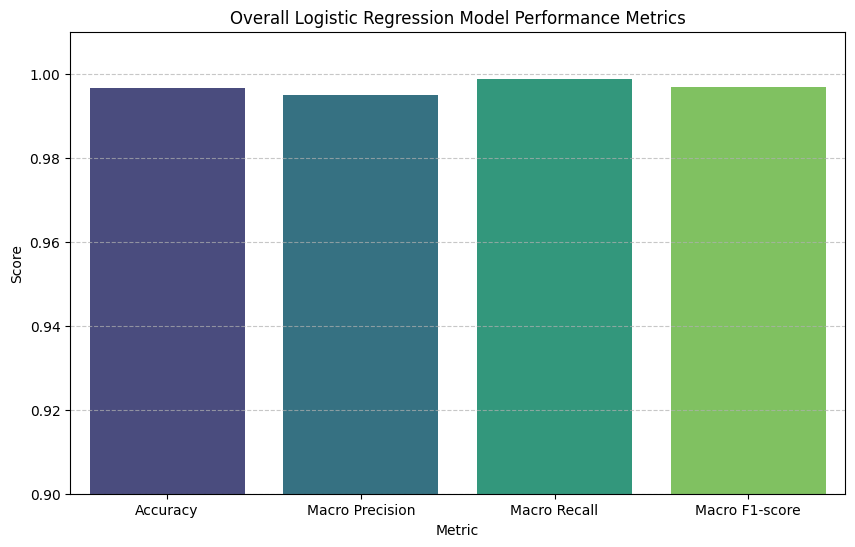

In [32]:
metrics = {
    'Accuracy': accuracy,
    'Macro Precision': precision_macro,
    'Macro Recall': recall_macro,
    'Macro F1-score': f1_macro
}

metrics_df = pd.DataFrame(metrics.items(), columns=['Metric', 'Score'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', data=metrics_df, palette='viridis')
plt.ylim(0.9, 1.01) # Set y-axis limits to highlight high scores
plt.title('Overall Logistic Regression Model Performance Metrics')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Classification Report Heatmap

To better visualize the `classification_report`, we can represent it as a heatmap. This makes it easier to spot patterns in precision, recall, and F1-score across different specialties.

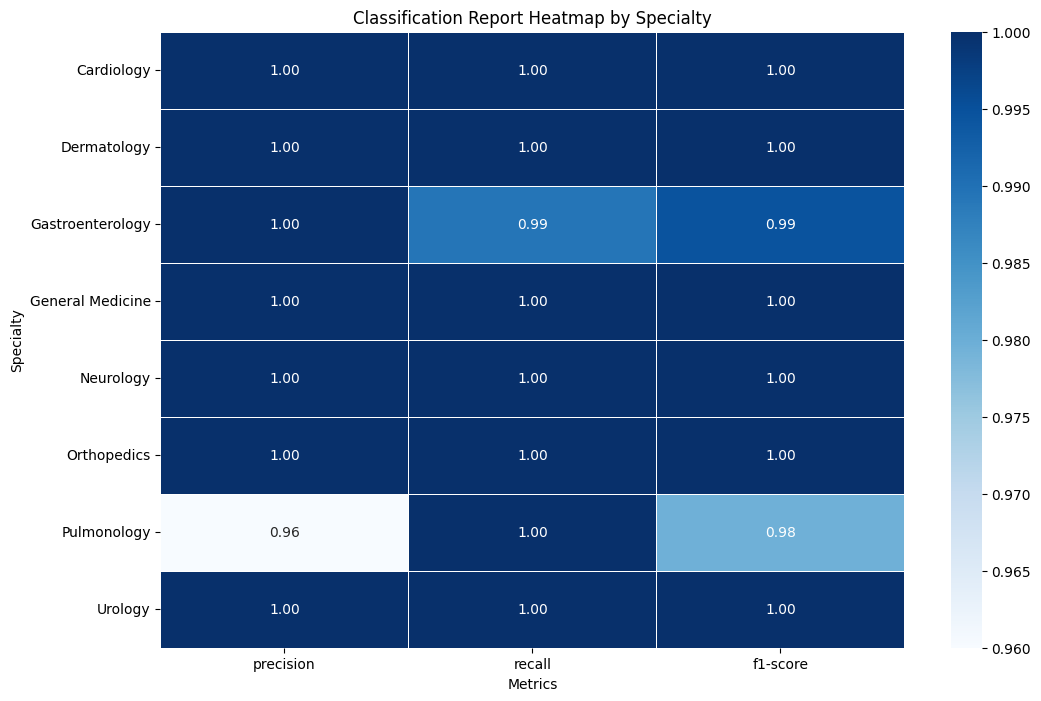

In [33]:
report_dict = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()

# Exclude 'accuracy', 'macro avg', 'weighted avg' rows for the heatmap to focus on per-class metrics
report_df_plot = report_df.drop(labels=['accuracy', 'macro avg', 'weighted avg'], axis=0)

plt.figure(figsize=(12, 8))
sns.heatmap(report_df_plot[['precision', 'recall', 'f1-score']], annot=True, cmap='Blues', fmt='.2f', linewidths=.5)
plt.title('Classification Report Heatmap by Specialty')
plt.ylabel('Specialty')
plt.xlabel('Metrics')
plt.show()

### Confusion Matrix

And here's the confusion matrix again, which provides a detailed breakdown of correct and incorrect predictions for each specialty.

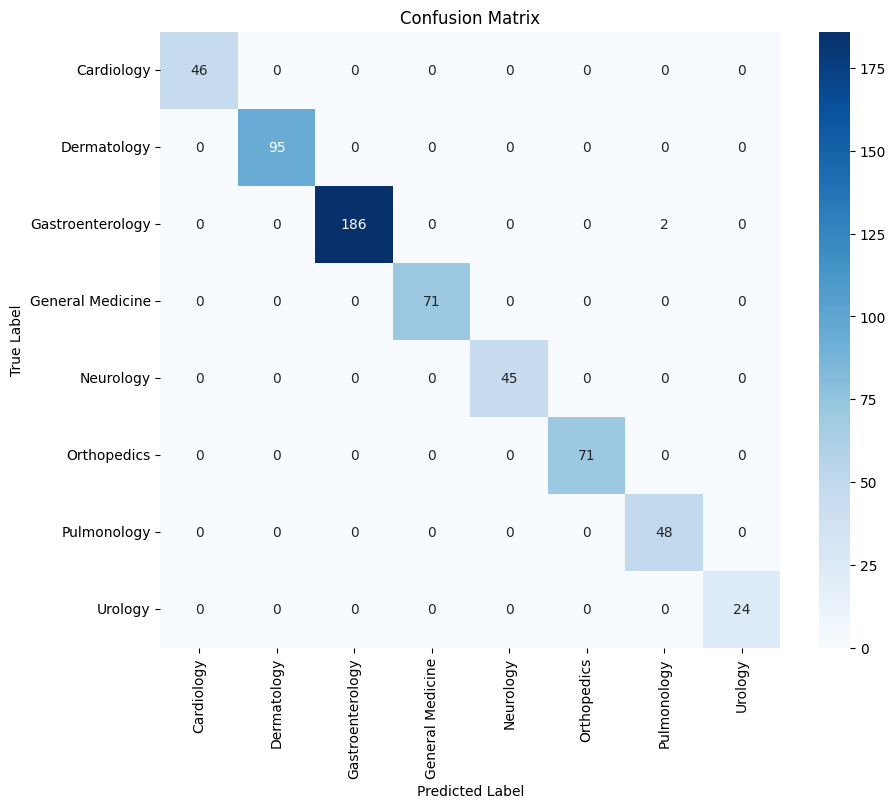

In [34]:
# Plotting the Confusion Matrix (reiterated for completeness)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

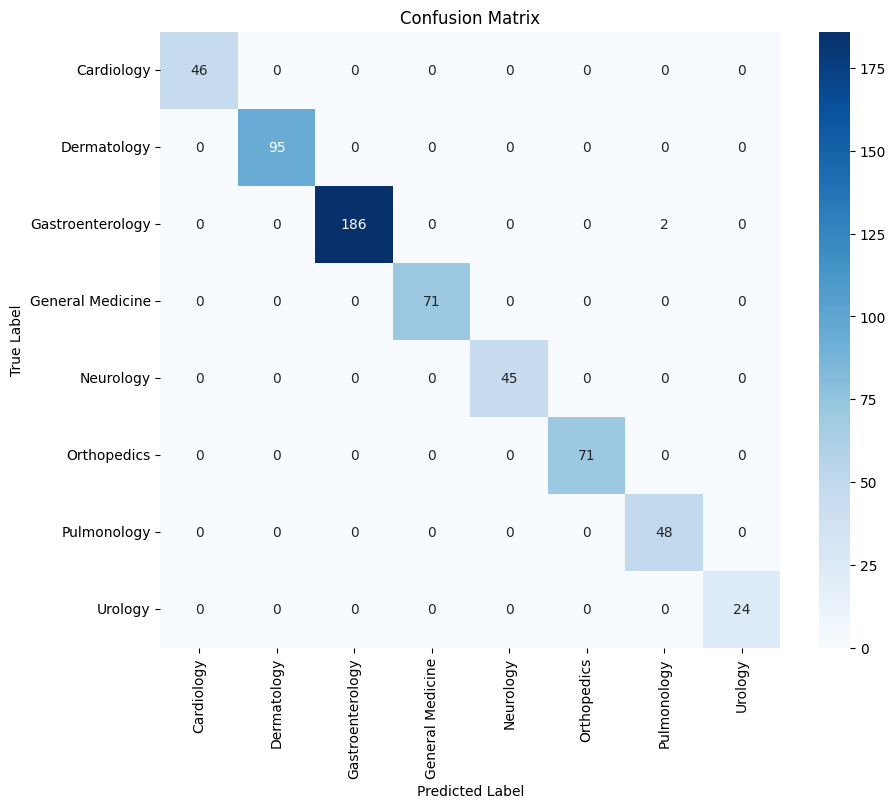

In [30]:
# Plotting the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [31]:
import joblib

# Define the filename for the saved model
model_filename = 'logistic_regression_model.joblib'

# Save the model to a file
joblib.dump(model, model_filename)

print(f"Model successfully saved to {model_filename}")

Model successfully saved to logistic_regression_model.joblib
